<a href="https://colab.research.google.com/github/eldhosekroy/churn_prediction/blob/main/better_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Libraries**

In [823]:
import os
import re
import time
import nltk
import pickle
import random
import warnings

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import sent_tokenize

from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

from sklearn.base import clone
from sklearn.utils import class_weight
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import roc_curve, RocCurveDisplay, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier

### **Directory Management**

In [824]:
output_dir = './output'

ARTIFACTS_PATH = output_dir
os.makedirs(ARTIFACTS_PATH, exist_ok=True)
print(f"Artifacts will be saved to: {ARTIFACTS_PATH}")

Artifacts will be saved to: ./output


# **Data Collection**

*   Enrolled dataset
*   All notes dataset





In [825]:
base_dir = os.getcwd()

input_dir =base_dir
# Read the enrolled & registered dataset
enrolled_df = pd.read_csv(os.path.join(input_dir, 'Endrolled & registred.csv'), encoding='latin1')

# Read the all notes dataset
notes = pd.read_csv(os.path.join(input_dir, 'All Notes-Contacts_copy.csv'), encoding='latin1')

print(f"Successfully loaded 'Endrolled & registred.csv' into enrolled_df from {input_dir}")
print(f"Successfully loaded 'All Notes-Contacts_copy.csv' into notes from {input_dir}")

Successfully loaded 'Endrolled & registred.csv' into enrolled_df from /content
Successfully loaded 'All Notes-Contacts_copy.csv' into notes from /content


In [826]:
print('\nNotes DataFrame Head:')
print(notes.head())


Notes DataFrame Head:
                   Note Id            Note Owner.id      Note Owner  \
0  zcrm_560042000001333918  zcrm_560042000001286184  SalesPerson-21   
1  zcrm_560042000001333864  zcrm_560042000001286184  SalesPerson-21   
2  zcrm_560042000001333760  zcrm_560042000001286184  SalesPerson-21   
3  zcrm_560042000001370043  zcrm_560042000001286184  SalesPerson-21   
4  zcrm_560042000001333945  zcrm_560042000001286184  SalesPerson-21   

  Note Title                                  Note Content  \
0        NaN                       SIJINA\nANOTHER CALLING   
1        NaN  SONU\nDATA ANALYTICS ALREADY INTERNSHIP DONE   
2        NaN                                   JOINED WORK   
3        NaN                           currently doing job   
4        NaN                         SHILKA\nNOT CONNECTED   

              Parent ID.id Parent ID            Created By.id Created By  \
0  zcrm_560042000000424058    sijina  zcrm_560042000001286184  Udhya P U   
1  zcrm_56004200000042405

In [827]:
print('\nEnrolled & Registered DataFrame Head:')
print(enrolled_df.head())


Enrolled & Registered DataFrame Head:
                Contact Id         Contact Owner.id  Contact Owner First Name  \
0  zcrm_560042000000440092  zcrm_560042000000283001  SalesPerson-2        NaN   
1  zcrm_560042000000466061  zcrm_560042000000283001  SalesPerson-2        NaN   
2  zcrm_560042000000565094  zcrm_560042000000331113  SalesPerson-9       Alan   
3  zcrm_560042000000583691  zcrm_560042000000331113  SalesPerson-9        NaN   
4  zcrm_560042000000604837  zcrm_560042000000283001  SalesPerson-2        NaN   

            Last Name  Email Opt Out college Name.id college Name  \
0  AJSAL Mohammed T S          False             NaN          NaN   
1        Abhishek R J          False             NaN          NaN   
2              Thomas          False             NaN          NaN   
3             Abhinav          False             NaN          NaN   
4         Albin Shaji          False             NaN          NaN   

    Track Interested       Tag  ... Gender Year of Graduati

# **Data Handling**

In [828]:
# Columns of enrolled dataset
print(enrolled_df.columns)

Index(['Contact Id', 'Contact Owner.id', 'Contact Owner', 'First Name',
       'Last Name', 'Email Opt Out', 'college Name.id', 'college Name',
       'Track Interested', 'Tag', 'Description', 'Created By.id',
       'Modified By.id', 'Created Time', 'Modified Time', 'Last Activity Time',
       'Unsubscribed Mode', 'Unsubscribed Time', 'Contact Name', 'City',
       'Mailing State', 'Mailing Zip', 'Mailing Country', 'Program Joined.id',
       'Program Joined', 'Source of lead', 'Pipeline owner.id', 'Semester',
       'Batch Assigned to', 'Lead Generated on', 'Course', 'Gender',
       'Year of Graduation', 'Experience', 'Test', 'Followup Email', 'Invoice',
       'Mode of Program Joined', 'Program Location', 'Region',
       'Whatsapp Number'],
      dtype='object')


In [829]:
# Remove irrelevant columns
enrolled_df=enrolled_df.drop(columns=['First Name', 'Last Name', 'Email Opt Out', 'college Name.id', 'college Name', 'Description', 'Unsubscribed Mode', 'Unsubscribed Time', 'Mailing Zip', 'Batch Assigned to', 'Region'])
print(enrolled_df.columns)

Index(['Contact Id', 'Contact Owner.id', 'Contact Owner', 'Track Interested',
       'Tag', 'Created By.id', 'Modified By.id', 'Created Time',
       'Modified Time', 'Last Activity Time', 'Contact Name', 'City',
       'Mailing State', 'Mailing Country', 'Program Joined.id',
       'Program Joined', 'Source of lead', 'Pipeline owner.id', 'Semester',
       'Lead Generated on', 'Course', 'Gender', 'Year of Graduation',
       'Experience', 'Test', 'Followup Email', 'Invoice',
       'Mode of Program Joined', 'Program Location', 'Whatsapp Number'],
      dtype='object')


###### Handling 'Track Interested'

In [830]:
# Define the specific list of program names to use for filling nulls
program_names = ['DA', 'DS', 'MERN', 'Python', 'Gen AI', 'Prompt Engineering']

# Fill null values in 'Track Interested' with random choices from the program_names list
if program_names:
    # Only fill nulls where they exist in the 'Track Interested' column
    null_indices = enrolled_df['Track Interested'].isnull()
    num_nulls = null_indices.sum()
    if num_nulls > 0:
        enrolled_df.loc[null_indices, 'Track Interested'] = np.random.choice(program_names, size=num_nulls)
    print("Null values in 'Track Interested' after filling:")
    print(enrolled_df['Track Interested'].isnull().sum())
    print("Value counts for 'Track Interested' after filling (top 10):")
    print(enrolled_df['Track Interested'].value_counts().head(10))
else:
    print("Warning: The list of program names for 'Track Interested' is empty.")

Null values in 'Track Interested' after filling:
0
Value counts for 'Track Interested' after filling (top 10):
Track Interested
Data Analytics        211
Datascience           189
DA                    129
Prompt Engineering    128
MERN                  122
DS                    116
Gen AI                115
Python                111
Data Science           29
Dataanalytics          29
Name: count, dtype: int64


In [831]:
print("\nValue counts for 'Track Interested' *before* standardization:")
print(enrolled_df['Track Interested'].value_counts()) # Print top 20 to see diverse values


Value counts for 'Track Interested' *before* standardization:
Track Interested
Data Analytics                         211
Datascience                            189
DA                                     129
Prompt Engineering                     128
MERN                                   122
DS                                     116
Gen AI                                 115
Python                                 111
Data Science                            29
Dataanalytics                           29
MERN Stack                              20
Data Analytics Intern                   13
Data Analyst                            10
Not Mentioned                            9
Python Full stack                        8
PEP                                      5
Datascience/DataAnalytics                5
Data Analyst Intern                      4
Dataanalyst                              3
DataAnalytics                            3
Data Analytics Fresher                   2
Dataanlytics     

In [832]:
# standardize values in 'Track Interested'
def standardize_track_interested(track_string):
    if pd.isna(track_string):
        return 'Other Course'

    track_string = str(track_string).strip().upper()

    if 'DATA SCIENCE' in track_string or 'DATASCIENCE' in track_string or 'DS' in track_string:
        return 'Data Science'
    elif 'DATA ANALYTICS' in track_string or 'DATAANALYTICS' in track_string or 'DATA ANALYST' in track_string or 'DATAANALYST' in track_string or 'DA' in track_string:
        return 'Data Analytics'
    elif 'MERN' in track_string:
        return 'MERN Stack'
    elif 'PYTHON FULL STACK' in track_string:
        return 'Full Stack'
    elif 'PYTHON' in track_string:
        return 'Python Programming'
    elif 'GEN AI' in track_string or 'GENAI' in track_string or 'PROMPT ENGINEERING' in track_string:
        return 'Gen AI & Prompt Engineering'
    elif 'FULL STACK' in track_string or 'FS' in track_string:
        return 'Full Stack Development'
    elif 'DIGITAL MKT' in track_string or 'DIGITAL MARKETING' in track_string:
        return 'Digital Marketing'
    elif 'CLOUD' in track_string:
        return 'Cloud Computing'
    elif 'UI UX' in track_string:
        return 'UI/UX Design'
    elif 'AIML' in track_string or 'AI/ML' in track_string:
        return 'AI/ML'
    elif 'ADVANCED PROGRAM' in track_string:
        return 'Advanced Program'
    elif 'ONE MONTH PROGRAM' in track_string:
        return 'One Month Program'
    elif 'PEP PROGRAM' in track_string or 'PEP' in track_string:
        return 'PEP Program'
    elif 'NOT MENTIONED' in track_string:
        return 'Not Mentioned'

    return 'Other Course'

# Apply the standardization function to the 'Track Interested' column
enrolled_df['Track Interested'] = enrolled_df['Track Interested'].apply(standardize_track_interested)

print("\nValue counts for 'Track Interested' after standardization:")
print(enrolled_df['Track Interested'].value_counts().head(10))


Value counts for 'Track Interested' after standardization:
Track Interested
Data Analytics                 410
Data Science                   341
Gen AI & Prompt Engineering    246
MERN Stack                     142
Python Programming             111
Not Mentioned                    9
Full Stack                       8
PEP Program                      5
Other Course                     2
Name: count, dtype: int64


###### Handling 'Tag'

In [833]:
# Unique values in tag column
print(enrolled_df['Tag'].value_counts())

Tag
Ayisha                                      185
Andriya                                      57
Enrolled                                     45
April 25 Batch                               22
Mithlaj Records                              20
Future Campaign-April 24                      9
DA Feb 2025                                   9
sangeetha                                     9
Registered                                    7
Free Internship                               5
MES Kalladi                                   5
Leads                                         3
Ayisha,sangeetha                              2
Future Campaign-April 24,Mithlaj Records      2
Techware-Walk-in                              2
Old CRM data                                  2
Old FUP                                       2
Amal                                          2
Followup                                      1
Workshop on GEN Ai                            1
FAHEEM REF                          

In [834]:
# Get unique non-null values from the 'Tag' column
existing_tags = enrolled_df['Tag'].dropna().unique().tolist()

# Add 'Not Mentioned' to the list of possible tags
if 'Not Mentioned' not in existing_tags:
    existing_tags.append('Not Mentioned')

# Identify null indices in the 'Tag' column
null_indices = enrolled_df['Tag'].isnull()
num_nulls = null_indices.sum()

# Fill null values with random choices from the combined list
if num_nulls > 0 and existing_tags:
    enrolled_df.loc[null_indices, 'Tag'] = np.random.choice(existing_tags, size=num_nulls)
    print("Null values in 'Tag' after filling:")
    print(enrolled_df['Tag'].isnull().sum())
    print("\nValue counts for 'Tag' after filling:")
    print(enrolled_df['Tag'].value_counts())
elif num_nulls == 0:
    print("No null values found in 'Tag' column.")
else:
    print("Warning: The list of existing tags is empty, or no nulls to fill.")

Null values in 'Tag' after filling:
0

Value counts for 'Tag' after filling:
Tag
Ayisha                                      213
Andriya                                      86
Enrolled                                     68
April 25 Batch                               50
Mithlaj Records                              47
Free Internship                              38
Future Campaign-April 24                     36
Registered                                   34
DA Feb 2025                                  34
Workshop on GEN Ai                           34
sangeetha                                    33
Old CRM data                                 33
Future Campaign-April 24,Mithlaj Records     33
Naukri-IDL                                   33
MES Kalladi                                  32
hot                                          31
Registered,Andriya                           30
FAHEEM REFERENCE                             30
without pipelines 18/02                      29
SHE REE

###### Handling 'City'

In [835]:
# Unique values in 'city'
print(enrolled_df['City'].value_counts().head(20))

City
Ernakulam             57
Thrissur              32
Kottayam              19
Malappuram            15
Kozhikode              9
Kollam                 9
Kannur                 9
Pathanamthitta         7
Kochi, Kerala          7
Wayanad                6
Alappuzha              6
Palakkad               5
Malappuram, Kerala     4
Idukki                 4
Kerala                 4
Thiruvananthapuram     4
Others                 3
Calicut, Kerala        3
Ernakulam, Kerala      2
Kochi                  2
Name: count, dtype: int64


In [836]:
# Get unique non-null values from the 'City' column
existing_cities = enrolled_df['City'].dropna().unique().tolist()

# Identify null indices in the 'City' column
null_indices = enrolled_df['City'].isnull()
num_nulls = null_indices.sum()

# Fill null values with random choices from the existing cities
if num_nulls > 0 and existing_cities:
    enrolled_df.loc[null_indices, 'City'] = np.random.choice(existing_cities, size=num_nulls)
    print("Null values in 'City' after filling:")
    print(enrolled_df['City'].isnull().sum())
    print("\nValue counts for 'City' after filling:")
    print(enrolled_df['City'].value_counts())
elif num_nulls == 0:
    print("No null values found in 'City' column.")
else:
    print("Warning: The list of existing cities is empty, or no nulls to fill.")

Null values in 'City' after filling:
0

Value counts for 'City' after filling:
City
Ernakulam                       73
Thrissur                        44
Kottayam                        40
Pathanamthitta                  30
Kollam                          29
                                ..
Kasargode                       12
Kothamangalam, Kerala, India    12
Calicut                         12
Ernakulam, Kerala               12
Mavoor Kozhikode                11
Name: count, Length: 64, dtype: int64


In [837]:
def standardize_city_name(city_string):
    if pd.isna(city_string):
        return 'Unknown'

    city_string = str(city_string).strip().upper()

    # Common standardizations
    city_string = re.sub(r'[,\s]*KERALA[\s\.]*', '', city_string) # Remove 'Kerala'
    city_string = re.sub(r'[,\s]*INDIA[\s\.]*', '', city_string) # Remove 'India'
    city_string = re.sub(r'[,\s]*IN[\s\.]*', '', city_string) # Remove 'IN'

    # Consolidate common city names
    if 'ERNAKULAM' in city_string or 'KOCHI' in city_string or 'MUVATUPUZHA' in city_string or 'KOTHAMANGALAM' in city_string or 'PADHUVAPURAM' in city_string:
        return 'Ernakulam'
    elif 'THRISSUR' in city_string or 'TRICHUR' in city_string or 'POTTA' in city_string or 'CHERUVALLOOR' in city_string:
        return 'Thrissur'
    elif 'MALAPPURAM' in city_string or 'PERTALMANNA' in city_string:
        return 'Malappuram'
    elif 'KOTTAYAM' in city_string or 'VAIKAM' in city_string or 'KANJIRAPPALLY' in city_string:
        return 'Kottayam'
    elif 'KOZHIKODE' in city_string or 'CALICUT' in city_string or 'VADAKARA' in city_string or 'SARADHALAYAM SIDHASAMAJAM' in city_string:
        return 'Calicut'
    elif 'THIRUVANANTHAPURAM' in city_string or 'TRIVANDRUM' in city_string:
        return 'Trivandrum'
    elif 'KOLLAM' in city_string or 'KOTTARAKARA' in city_string:
        return 'Kollam'
    elif 'PALAKKAD' in city_string:
        return 'Palakkad'
    elif 'KANNUR' in city_string:
        return 'Kannur'
    elif 'ALAPPUZHA' in city_string or 'ALLEPPEY' in city_string:
        return 'Alappuzha'
    elif 'WAYANAD' in city_string:
        return 'Wayanad'
    elif 'PATHANAMTHITTA' in city_string or 'PANDALAM' in city_string or 'THAZHVETTIPPURAM' in city_string:
        return 'Pathanamthitta'
    elif 'OTTAPALAM' in city_string or 'PALAKKAD' in city_string:
        return 'Palakkad'
    elif 'IDUKKI' in city_string or 'THODUPUZHA' in city_string or 'IDUKKY' in city_string:
        return 'Idukki'
    elif 'KASARGODE' in city_string or 'KASARGOD' in city_string:
        return 'Kasargod'
    elif 'CHENNAI' in city_string:
        return 'Chennai'
    elif 'BENGALURU' in city_string or 'BANGALORE' in city_string:
        return 'Bengaluru'
    elif 'HYDERABAD' in city_string:
        return 'Hyderabad'
    elif 'MUMBAI' in city_string or 'BOMBAY' in city_string:
        return 'Mumbai'
    elif 'DELHI' in city_string:
        return 'Delhi'

    # Remove specific noise after checking major cities
    city_string = re.sub(r'\b(TOWNSHIP|TOWN|DISTRICT|DT)\b', '', city_string).strip()
    city_string = re.sub(r'\b(POST|PO)\b', '', city_string).strip()
    city_string = re.sub(r'\s*\d{6}\s*', '', city_string) # Remove postal codes

    # Handle specific cases that might still be left after initial broader checks
    if city_string == 'OTHERS' or city_string == 'UNKNOWN' or city_string == '-' or city_string == 'TREESA SEBASTIAN':
        return 'Unknown'
    if city_string == 'KOOVAPPADY':
        return 'Ernakulam' # Assuming Koovappady is near Ernakulam

    # If the string is empty after cleaning, return 'Unknown'
    if not city_string:
        return 'Unknown'

    # Default to 'Other' if not specifically matched, to consolidate less frequent cities
    #if enrolled_df['City'].value_counts()[city_string] < 5: # Example threshold, can be adjusted
    #    return 'Other'

    return city_string.title() # Convert to title case for consistency


enrolled_df['City'] = enrolled_df['City'].apply(standardize_city_name)

print("\nValue counts for 'City' after standardization:")
print(enrolled_df['City'].value_counts().head(20))


Value counts for 'City' after standardization:
City
Ernakulam         296
Thrissur          137
Kottayam          104
Calicut           104
Unknown            91
Pathanamthitta     83
Alappuzha          73
Idukki             71
Malappuram         65
Kollam             63
Palakkad           42
Wayanad            38
Kannur             33
Trivandrum         28
Bengaluru          20
Chennai            14
Kasargod           12
Name: count, dtype: int64


###### Handling 'Mailing State'

In [838]:
# Unique values in 'Mailing State'
print(enrolled_df['Mailing State'].value_counts())

Mailing State
Kerala           7
689647           1
MUVATTUPUZHA.    1
Name: count, dtype: int64


In [839]:
def standardize_mailing_state(state_string):
    if pd.isna(state_string):
        return np.nan # Keep as NaN for now to fill later

    state_string = str(state_string).strip().upper()

    if 'KERALA' in state_string or 'MUVATTUPUZHA.' in state_string or '689647' in state_string:
        return 'Kerala'
    elif 'TAMIL NADU' in state_string or 'CHENNAI' in state_string:
        return 'Tamil Nadu'
    elif 'KARNATAKA' in state_string or 'BENGALURU' in state_string or 'BANGALORE' in state_string:
        return 'Karnataka'
    else:
        return 'Other State'

# Apply the initial standardization
enrolled_df['Mailing State'] = enrolled_df['Mailing State'].apply(standardize_mailing_state)

def fill_mailing_state_from_city(row):
    current_state = row['Mailing State']
    city = row['City']

    # If the state is still NaN or 'Other State', try to infer from city
    if pd.isna(current_state) or current_state == 'Other State':
        if pd.isna(city) or city == 'Unknown' or city == 'Other':
            return 'Other State'

        # Map cities to states based on prior standardization
        if city in ['Ernakulam', 'Thrissur', 'Calicut', 'Kottayam', 'Malappuram',
                    'Alappuzha', 'Pathanamthitta', 'Idukki', 'Kollam', 'Trivandrum',
                    'Kannur', 'Wayanad', 'Palakkad', 'Kasargod']:
            return 'Kerala'
        elif city == 'Chennai':
            return 'Tamil Nadu'
        elif city == 'Bengaluru':
            return 'Karnataka'
        else:
            return 'Other State'
    return current_state

# Apply the filling function
enrolled_df['Mailing State'] = enrolled_df.apply(fill_mailing_state_from_city, axis=1)

print("\nValue counts for 'Mailing State' after standardization and filling:")
print(enrolled_df['Mailing State'].value_counts())


Value counts for 'Mailing State' after standardization and filling:
Mailing State
Kerala         1149
Other State      91
Karnataka        20
Tamil Nadu       14
Name: count, dtype: int64


###### Handling 'Mailing Country'

In [840]:
# Unique values in 'Mailing Country'
print(enrolled_df['Mailing Country'].value_counts())

Mailing Country
India    8
Name: count, dtype: int64


In [841]:
# Fill null values with 'India'
enrolled_df['Mailing Country'] = enrolled_df['Mailing Country'].fillna('India')

print("\nValue counts for 'Mailing Country' after filling nulls:")
print(enrolled_df['Mailing Country'].value_counts())


Value counts for 'Mailing Country' after filling nulls:
Mailing Country
India    1274
Name: count, dtype: int64


###### Handling 'Source of lead'

In [842]:
# Fill null values with mode of the column
if enrolled_df['Source of lead'].isnull().any():
    mode_source_of_lead = enrolled_df['Source of lead'].mode()[0]
    enrolled_df['Source of lead'] = enrolled_df['Source of lead'].fillna(mode_source_of_lead)
    print(f"Null values in 'Source of lead' filled with: {mode_source_of_lead}")
else:
    print("No null values found in 'Source of lead' to fill.")

print("\nValue counts for 'Source of lead' after filling nulls:")
print(enrolled_df['Source of lead'].value_counts())

Null values in 'Source of lead' filled with: Indeed

Value counts for 'Source of lead' after filling nulls:
Source of lead
Indeed                          420
Reference                       202
Digital Marketing (Goat add)    191
Infopark website                142
Enquiry                          78
Digital Marketing (Add On)       51
DM                               30
IV                               22
Workshop                         22
Seminar                          19
dm                               18
Website Enquiry                  16
infopark                         10
Naukri Paid                       8
Free internship campaign          7
Webinar                           5
Job Fair                          4
Social media                      4
Indeed Paid                       3
Carryover                         3
Infopark                          3
OLX                               3
Naukri Ad posting                 2
SEO                               2
Bulk Lead (30

In [843]:
#Standardize the values in the 'source of lead'
def standardize_source_of_lead(source_string):
    if pd.isna(source_string):
        return 'Unknown'

    source_string = str(source_string).strip().upper()

    if 'INDEED' in source_string:
        return 'Indeed'
    elif 'DIGITAL MARKETING' in source_string or 'DM' in source_string:
        return 'Digital Marketing'
    elif 'INFOPARK WEBSITE' in source_string or 'INFOPARK' in source_string:
        return 'Infopark Website'
    elif 'REFERENCE' in source_string or 'REFERAL' in source_string or 'REFERALS' in source_string:
        return 'Referral'
    elif 'ENQUIRY' in source_string or 'WEBSITE ENQUIRY' in source_string:
        return 'Website'
    elif 'FREE INTERNSHIP' in source_string:
        return 'Free Internship Campaign'
    elif 'NAUKRI' in source_string:
        return 'Naukri'
    elif 'WORKSHOP' in source_string:
        return 'Workshop'
    elif 'SEMINAR' in source_string:
        return 'Seminar'
    elif 'WEBINAR' in source_string:
        return 'Webinar'
    elif 'JOB FAIR' in source_string:
        return 'Job Fair'
    elif 'SOCIAL MEDIA' in source_string:
        return 'Social Media'
    elif 'LINKEDIN' in source_string:
        return 'LinkedIn'
    elif 'IV' in source_string:
        return 'IV'
    elif 'CARRYOVER' in source_string:
        return 'Carryover'
    elif 'OLX' in source_string:
        return 'OLX'
    elif 'SEO' in source_string:
        return 'SEO'
    elif 'BULK LEAD' in source_string:
        return 'Bulk Lead'
    elif 'OTHERS' in source_string:
        return 'Other'

    return source_string.title() # Default to Title Case if not explicitly matched

enrolled_df['Source of lead'] = enrolled_df['Source of lead'].apply(standardize_source_of_lead)

print("\nValue counts for 'Source of lead' after standardization:")
print(enrolled_df['Source of lead'].value_counts())


Value counts for 'Source of lead' after standardization:
Source of lead
Indeed                      423
Digital Marketing           291
Referral                    204
Infopark Website            157
Website                      94
IV                           22
Workshop                     22
Seminar                      19
Naukri                       10
Free Internship Campaign      8
Webinar                       5
Job Fair                      4
Social Media                  4
OLX                           3
Carryover                     3
Bulk Lead                     2
SEO                           2
LinkedIn                      1
Name: count, dtype: int64


###### Handling 'Year of graduation'

In [844]:
# Unique values in 'year of graduation'
print(enrolled_df['Year of Graduation'].value_counts())

Year of Graduation
2024.0     115
2025.0      72
2023.0      32
2022.0      21
2020.0      11
2017.0      11
2021.0      10
2019.0       9
2018.0       7
2016.0       6
2015.0       4
2007.0       4
2009.0       4
2026.0       3
2013.0       2
2014.0       2
2011.0       2
2012.0       1
20224.0      1
2006.0       1
2010.0       1
Name: count, dtype: int64


In [845]:
# Correct the erroneous year '20224' to '2024'
enrolled_df['Year of Graduation'] = enrolled_df['Year of Graduation'].replace(20224.0, 2024.0)

# Identify null values
null_years_indices = enrolled_df['Year of Graduation'].isnull()
num_null_years = null_years_indices.sum()

# Fill null values with random years between 2015 and 2027 (inclusive)
if num_null_years > 0:
    # np.random.randint is exclusive of the high value, so use 2028 for 2027 inclusive
    random_years = np.random.randint(2015, 2028, size=num_null_years)
    enrolled_df.loc[null_years_indices, 'Year of Graduation'] = random_years
    print(f"Filled {num_null_years} null values in 'Year of Graduation' with random years between 2015 and 2027.")
else:
    print("No null values found in 'Year of Graduation' to fill.")

# Convert 'Year of Graduation' to integer type
enrolled_df['Year of Graduation'] = enrolled_df['Year of Graduation'].astype(int)

print("\nValue counts for 'Year of Graduation' after cleaning and type conversion:")
print(enrolled_df['Year of Graduation'].value_counts().sort_index())

Filled 955 null values in 'Year of Graduation' with random years between 2015 and 2027.

Value counts for 'Year of Graduation' after cleaning and type conversion:
Year of Graduation
2006      1
2007      4
2009      4
2010      1
2011      2
2012      1
2013      2
2014      2
2015     75
2016     74
2017     91
2018     87
2019     83
2020     86
2021     74
2022     86
2023     92
2024    181
2025    171
2026     80
2027     77
Name: count, dtype: int64


###### Handling 'Lead generated on'

In [846]:
# Get unique non-null values from the 'Lead Generated on' column
existing_lead_dates = enrolled_df['Lead Generated on'].dropna().unique().tolist()

# Identify null indices in the 'Lead Generated on' column
null_indices = enrolled_df['Lead Generated on'].isnull()
num_nulls = null_indices.sum()

# Fill null values with random choices from the existing dates
if num_nulls > 0 and existing_lead_dates:
    enrolled_df.loc[null_indices, 'Lead Generated on'] = np.random.choice(existing_lead_dates, size=num_nulls)
    print("Null values in 'Lead Generated on' after filling:")
    print(enrolled_df['Lead Generated on'].isnull().sum())
    print("\nValue counts for 'Lead Generated on' after filling:")
    print(enrolled_df['Lead Generated on'].value_counts())
elif num_nulls == 0:
    print("No null values found in 'Lead Generated on' column.")
else:
    print("Warning: The list of existing 'Lead Generated on' dates is empty, or no nulls to fill.")

Null values in 'Lead Generated on' after filling:
0

Value counts for 'Lead Generated on' after filling:
Lead Generated on
13-12-2023    10
20-09-2024    10
16-09-2025     9
22-11-2024     9
20-08-2024     8
              ..
02-03-2024     1
09-07-2024     1
13-10-2024     1
03-03-2025     1
25-12-2016     1
Name: count, Length: 442, dtype: int64


###### Handling 'Mode of program joined'

In [847]:
# Get unique non-null values from the 'Mode of Program Joined' column
existing_modes = enrolled_df['Mode of Program Joined'].dropna().unique().tolist()

# Identify null indices in the 'Mode of Program Joined' column
null_indices = enrolled_df['Mode of Program Joined'].isnull()
num_nulls = null_indices.sum()

# Fill null values with random choices from the existing values
if num_nulls > 0 and existing_modes:
    enrolled_df.loc[null_indices, 'Mode of Program Joined'] = np.random.choice(existing_modes, size=num_nulls)
    print("Null values in 'Mode of Program Joined' after filling:")
    print(enrolled_df['Mode of Program Joined'].isnull().sum())
    print("\nValue counts for 'Mode of Program Joined' after filling:")
    print(enrolled_df['Mode of Program Joined'].value_counts())
elif num_nulls == 0:
    print("No null values found in 'Mode of Program Joined' column.")
else:
    print("Warning: The list of existing 'Mode of Program Joined' values is empty, or no nulls to fill.")

Null values in 'Mode of Program Joined' after filling:
0

Value counts for 'Mode of Program Joined' after filling:
Mode of Program Joined
Onsite           536
Online           329
online hybrid    212
Hybrid           197
Name: count, dtype: int64


In [848]:
# Standardize the values in the 'mode of program joined'
def standardize_mode_of_program_joined(mode_string):
    if pd.isna(mode_string):
        return None
    mode_string = str(mode_string).strip().lower()
    if 'online' in mode_string and 'hybrid' not in mode_string:
        return 'Online'
    elif 'offline' in mode_string or 'onsite' in mode_string:
        return 'Offline'
    elif 'hybrid' in mode_string:
        return 'Hybrid'
    return None

enrolled_df['Mode of Program Joined'] = enrolled_df['Mode of Program Joined'].apply(standardize_mode_of_program_joined)

print("Value counts for 'Mode of Program Joined' after standardization:")
print(enrolled_df['Mode of Program Joined'].value_counts())

Value counts for 'Mode of Program Joined' after standardization:
Mode of Program Joined
Offline    536
Hybrid     409
Online     329
Name: count, dtype: int64


###### Handling 'program location'

In [849]:
# Unique values in the 'program location'
print(enrolled_df['Program Location'].value_counts())

Program Location
Kochi                247
online                95
Calicut               85
Hyderabad              2
Online                 2
Bengaluru              2
kochi live stream      1
banglore               1
kochi live             1
Rajahmundry            1
Bangalore              1
Name: count, dtype: int64


In [850]:
# Standardize values in the 'program location'
def standardize_program_location(location_string):
    if pd.isna(location_string):
        return None

    location_string = str(location_string).strip().lower()

    # Remove 'online' values
    if 'online' in location_string:
        return None

    # Standardize specific cities
    if 'kochi' in location_string:
        return 'Kochi'
    elif 'calicut' in location_string:
        return 'Calicut'
    elif 'bengaluru' in location_string or 'banglore' in location_string:
        return 'Bengaluru'
    elif 'hyderabad' in location_string:
        return 'Hyderabad'

    # All other values are categorized as 'Other Location'
    return None

enrolled_df['Program Location'] = enrolled_df['Program Location'].apply(standardize_program_location)

print("Value counts for 'Program Location' after standardization:")
print(enrolled_df['Program Location'].value_counts())

Value counts for 'Program Location' after standardization:
Program Location
Kochi        249
Calicut       85
Bengaluru      3
Hyderabad      2
Name: count, dtype: int64


In [851]:
# Fill null values in 'program location'
null_locations = enrolled_df['Program Location'].isnull()
num_nulls_location = null_locations.sum()

if num_nulls_location > 0:
    # Define locations and their weights for random filling
    locations_to_fill = ['Kochi', 'Calicut', 'Bengaluru', 'Hyderabad']
    weights = [0.45, 0.45, 0.05, 0.05] # Kochi and Calicut get 45% each, others 5%

    # Generate random choices based on weights
    filled_values = np.random.choice(locations_to_fill, size=num_nulls_location, p=weights)
    enrolled_df.loc[null_locations, 'Program Location'] = filled_values

    print(f"Filled {num_nulls_location} null values in 'Program Location' with weighted random choices.")
else:
    print("No null values found in 'Program Location' to fill.")

print("\nValue counts for 'Program Location' after filling nulls:")
print(enrolled_df['Program Location'].value_counts())

Filled 935 null values in 'Program Location' with weighted random choices.

Value counts for 'Program Location' after filling nulls:
Program Location
Kochi        672
Calicut      513
Hyderabad     49
Bengaluru     40
Name: count, dtype: int64


###### Handling 'Whatsapp Number'

In [852]:
# Values in 'whatsapp number'
print(enrolled_df['Whatsapp Number'].value_counts())

Whatsapp Number
907428451.0    1
808661817.0    1
701218892.0    1
974470699.0    1
Name: count, dtype: int64


In [853]:
# Identify null values in 'Whatsapp Number'
null_whatsapp_indices = enrolled_df['Whatsapp Number'].isnull()
num_null_whatsapp = null_whatsapp_indices.sum()

if num_null_whatsapp > 0:
    # Generate random 10-digit numbers for the nulls. Start with 6, 7, 8, or 9.
    generated_numbers = []
    for _ in range(num_null_whatsapp):
        first_digit = random.choice([6, 7, 8, 9])
        remaining_digits = ''.join([str(random.randint(0, 9)) for _ in range(9)])
        generated_numbers.append(float(str(first_digit) + remaining_digits))

    enrolled_df.loc[null_whatsapp_indices, 'Whatsapp Number'] = generated_numbers
    print(f"Filled {num_null_whatsapp} null values in 'Whatsapp Number' with random 10-digit numbers.")
else:
    print("No null values found in 'Whatsapp Number' to fill.")

# Convert 'Whatsapp Number' to integer type. Use errors='coerce' to handle any non-numeric data gracefully.
enrolled_df['Whatsapp Number'] = enrolled_df['Whatsapp Number'].astype(str).str.replace('.0', '', regex=False).astype(float).astype('Int64')

print("\nValue counts for 'Whatsapp Number' after filling nulls and type conversion (top 10):")
print(enrolled_df['Whatsapp Number'].value_counts().head(10))
print(f"\nData type of 'Whatsapp Number' column: {enrolled_df['Whatsapp Number'].dtype}")

Filled 1270 null values in 'Whatsapp Number' with random 10-digit numbers.

Value counts for 'Whatsapp Number' after filling nulls and type conversion (top 10):
Whatsapp Number
8052595400    1
8841113047    1
8361980328    1
8044124370    1
8864711019    1
9464178396    1
7856115934    1
8166625783    1
6784364222    1
7819991182    1
Name: count, dtype: Int64

Data type of 'Whatsapp Number' column: Int64


###### Handling 'Email ID'

In [854]:
# Create new column for email ids
generated_emails = set()

def generate_unique_email_id(contact_name):
    if pd.isna(contact_name):
        return None

    # Convert name to lowercase and remove non-alphanumeric characters for email prefix
    base_email = re.sub(r'[^a-z0-9]', '', str(contact_name).lower())

    if not base_email: # Handle cases where name might be empty after cleaning
        base_email = 'user'

    email_prefix = base_email
    counter = 1

    # Ensure uniqueness
    while f"{email_prefix}@gmail.com" in generated_emails:
        email_prefix = f"{base_email}{counter}"
        counter += 1

    final_email = f"{email_prefix}@gmail.com"
    generated_emails.add(final_email)
    return final_email

# Apply the function to create the new 'Email ID' column
enrolled_df['Email ID'] = enrolled_df['Contact Name'].apply(generate_unique_email_id)

print("First 5 generated Email IDs:")
print(enrolled_df['Email ID'].head())

print("\nNumber of unique Email IDs generated:")
print(enrolled_df['Email ID'].nunique())

print("Total number of candidates:")
print(len(enrolled_df))

First 5 generated Email IDs:
0    ajsalmohammedts@gmail.com
1         abhishekrj@gmail.com
2         alanthomas@gmail.com
3            abhinav@gmail.com
4         albinshaji@gmail.com
Name: Email ID, dtype: object

Number of unique Email IDs generated:
1274
Total number of candidates:
1274


###### Handling 'Invoice'

In [855]:
# Fill null values in 'Invoice' column with 'No'
enrolled_df['Invoice'] = enrolled_df['Invoice'].fillna('No')

# Standardize 'Invoice' column values to 'Yes' or 'No'
def standardize_invoice(invoice_status):
    if pd.isna(invoice_status):
        return 'No' # Should have been filled by previous step, but as a safeguard
    invoice_status = str(invoice_status).strip().lower()
    if invoice_status == 'yes':
        return 'Yes'
    else:
        return 'No'

enrolled_df['Invoice'] = enrolled_df['Invoice'].apply(standardize_invoice)

print("Value counts for 'Invoice' after filling nulls and standardization:")
print(enrolled_df['Invoice'].value_counts())

Value counts for 'Invoice' after filling nulls and standardization:
Invoice
Yes    1084
No      190
Name: count, dtype: int64


###### Handling 'Education'(course)

In [856]:
# Function to standardize course names in the 'Course' column, focusing on preserving degree names
def standardize_course_name(course_string):
    if pd.isna(course_string) or str(course_string).strip().lower() == 'not mentioned':
        return None

    course_string = str(course_string).upper()

    # Remove general noise: extra spaces, some punctuation, but be careful not to remove critical parts
    # Allow A-Z, 0-9, spaces, &, and hyphens. Only allow these characters
    course_string = re.sub(r'[^-A-Z0-9\s&]', '', course_string)
    course_string = ' '.join(course_string.split()) # Normalize spaces

    # Standardize common degree and course abbreviations
    course_string = course_string.replace('B.TECH', 'BTECH')
    course_string = course_string.replace('B.E.', 'BE')
    course_string = course_string.replace('M.TECH', 'MTECH')
    course_string = course_string.replace('BSC CS', 'BSC-CS')
    course_string = course_string.replace('MSC CS', 'MSC-CS')
    #course_string = course_string.replace('COMPUTER APPLICATION', 'CA')
    course_string = course_string.replace('BACHELOR OF COMPUTER APPLICATION - COMPUTER APPLICATION', 'BCA')
    # Add BVOC specific standardization
    course_string = course_string.replace('BVOC DATA ANALYTICS AND MACHINE LEARNING', 'B VOC-IT')
    course_string = course_string.replace('BVOC', 'B VOC') # General BVOC

    course_string = course_string.replace('COMPUTER SCIENCE AND ENGINEERING', 'BTECH')
    #course_string = course_string.replace('COMPUTER SCIENCE', 'BTECH')
    #course_string = course_string.replace('INFORMATION TECHNOLOGY', 'BTECH')
    course_string = course_string.replace('DATA ANALYTICS', 'DA')
    course_string = course_string.replace('DATA SCIENCE', 'DS')
    #course_string = course_string.replace('BIG DATA ANALYTICS', 'BDA')
    course_string = course_string.replace('ENGLISH LITERATURE', 'BA')
    course_string = course_string.replace('PLUS TWO', 'PLUS TWO')
    course_string = course_string.replace('DIPLOMA', 'DIPLOMA')
    course_string = course_string.replace('DIPLOMA-NON IT', 'DIPLOMA')

    # Handle common course name variations before general IT/NON-IT replacement
    course_string = course_string.replace('B TECH', 'BTECH') # For 'B TECH'
    course_string = course_string.replace('B_TECH', 'BTECH') # For 'B_TECH'
    course_string = course_string.replace('B_COM', 'BCOM') # For 'B_COM'
    course_string = course_string.replace('CA CA', 'CA')
    course_string = course_string.replace('CA-CA', 'CA') # For 'CA - CA' and 'CA CA'

    # Specific fixes for previous output issues (e.g., missing hyphens)
    course_string = course_string.replace('BTECHIT', 'BTECH')
    course_string = course_string.replace('MSCIT', 'MSC-IT')
    course_string = course_string.replace('BSCIT', 'BSC-IT')
    course_string = course_string.replace('MTECH-IT', 'MTECH')
    course_string = course_string.replace('MTECHIT', 'MTECH')

    # Address remaining specific MSC-CS-DA variations directly after initial replacements
    course_string = course_string.replace('MSC-CS DA', 'MSC-IT')
    course_string = course_string.replace('MSC-CSDA', 'MSC-IT')

    # These replacements should happen after primary acronym standardization
    # This line might create issues for standalone 'IT' if not careful. For now, keep as is as other specific replacements handle degree-IT combinations.
    course_string = course_string.replace(' IT', '-IT') # Handle BTech IT etc. to BTech-IT
    course_string = course_string.replace('NON-IT', '-NON-IT') # Handle BTech-Non IT etc.

    # Normalize hyphens: replace multiple hyphens with single, remove spaces around hyphens
    course_string = re.sub(r'-+', '-', course_string).strip('-')
    course_string = re.sub(r'\s*-\s*', '-', course_string) # Remove spaces around hyphens
    course_string = ' '.join(course_string.split()) # Final space normalization after hyphen cleanup

    # Special handling for numerical and very short entries
    if course_string == '2':
        return 'PLUS TWO'
    if course_string == 'COMP':
        return 'BCA'
    if course_string == 'POST GRADUATION':
        return 'PG'
    if course_string == 'BSC SCIENCE':
        return 'BSC'
    if course_string == 'GRADUATED':
        return 'GRADUATED'
    if course_string == 'DIPLOMA-IT':
        return 'DIPLOMA-IT'
    if course_string == 'DIPLOMA-NON-IT':
        return 'DIPLOMA'
    if course_string == 'DIPLOMA':
        return 'DIPLOMA'
    if course_string == 'INCOLLEGE' or course_string == 'IN_COLLEGE' or course_string == 'STUDENT': # Standardize IN_COLLEGE and convert 'STUDENT' if found as a course
        return 'UNSPECIFIED' # 'STUDENT' is a role, not a course
    if course_string == 'OTHERS':
        return None

    # Remove words like 'PROGRAM', 'DEGREE', 'BACHELOR', 'MASTER' if they are standalone or don't contribute to specific degree names
    # This part should be less aggressive
    course_string = re.sub(r'\b(BACHELOR|MASTER|DEGREE|PROGRAMME|PROGRAM)\b', '', course_string).strip()
    course_string = re.sub(r'\b(OF|AND)\b', '', course_string).strip() # Remove common connectors

    course_string = ' '.join(course_string.split()) # Final space normalization

    # Map common variations to desired output, e.g., 'BTECH-IT' or 'BTECH'
    if 'BTECH' in course_string and 'NON' not in course_string and 'IT' not in course_string:
        course_string = 'BTECH'
    if 'BCA' in course_string:
        course_string = 'BCA'
    if 'MCA' in course_string:
        course_string = 'MCA'
    if 'BCOM' in course_string:
        course_string = 'BCOM'
    if 'MCOM' in course_string:
        course_string = 'MCOM'
    if 'BA' in course_string and 'DA' not in course_string and 'MBA' not in course_string:
        course_string = 'BA'
    if 'MA' in course_string:
        course_string = 'MA'
    if 'BSC' in course_string and 'NON' not in course_string and 'IT' not in course_string and 'CS' not in course_string and 'COMPUTER SCIENCE' not in course_string:
        course_string = 'BSC'
    if 'MSC' in course_string and 'NON' not in course_string and 'IT' not in course_string and 'CS' not in course_string and 'COMPUTER SCIENCE' not in course_string and 'BIG' not in course_string:
        course_string = 'MSC'
    if 'CSE' in course_string:
        course_string = 'BTECH'
    if 'CS' in course_string and 'BSC' not in course_string and 'MSC' not in course_string:
        course_string = 'BTECH'
    if 'COMPUTER SCIENCE' in course_string and 'BSC' not in course_string and 'MSC' not in course_string:
        course_string = 'BTECH'
    if 'B VOC-IT' in course_string:
        course_string = 'B VOC-IT'
    if 'DIPLOMA'in course_string and 'IT' not in course_string:
        course_string = 'DIPLOMA'


    # Ensure consistency for entries like 'BTECH-IT', 'BSC-IT', etc.
    if course_string == 'BTECH-IT':
         course_string = 'BTECH'
    elif course_string == 'BTECH-NON-IT':
         course_string = 'BTECH'
    elif course_string == 'BACHELOR OF COMPUTER APPLICATION - COMPUTER APPLICATION':
         course_string = 'BCA'
    elif course_string == 'BSC-IT':
        pass # Keep as is
    elif course_string == 'MSC-IT':
        pass
    elif course_string == 'BSCSCIENCE':
         course_string = 'BSC'
    elif course_string == 'BSC COMPUTER SCIENCE':
         course_string = 'BSC-IT'
    elif course_string == 'MSC COMPUTER SCIENCEDA':
         course_string = 'MSC-IT'
    elif course_string == 'MSC COMPUTER SCIENCE DA':
         course_string = 'MSC-IT'
    elif course_string == 'MSC BIG DA':
         course_string = 'MSC-IT'
    elif course_string == 'MBA':
         course_string = 'MBA'
    elif course_string == 'MSC-NON-IT':
         course_string = 'MSC'
    elif course_string == 'BSC-NON-IT':
         course_string = 'BSC'
    elif course_string == 'DIPLOMA-IT':
        pass
    elif course_string == 'DIPLOMA':
        pass
    elif course_string == 'MSC-CS-DA':
         course_string = 'MSC-CS, DA'

    # Final check for empty strings or remaining generic terms
    if not course_string or course_string == 'UNKNOWN' or course_string == 'UNSPECIFIED':
        return None

    return course_string

enrolled_df['Education'] = enrolled_df['Course'].apply(standardize_course_name)

print("\nValue counts for 'Education' column after standardization:")
print(enrolled_df['Education'].value_counts())
enrolled_df = enrolled_df.drop(columns=['Course'])
print("Columns in enrolled_df after dropping 'Course':")
print(enrolled_df.columns)


Value counts for 'Education' column after standardization:
Education
BTECH          101
BCA             64
MCA             59
BCOM            31
MSC-IT          27
BSC-IT          21
BSC             19
MBA             15
BA              12
B VOC           11
MSC              7
MTECH            5
GRADUATED        4
B VOC-IT         4
DIPLOMA          4
DIPLOMA-IT       4
MCOM             4
PLUS TWO         2
PG               1
UNSPECIFIED      1
MA               1
Name: count, dtype: int64
Columns in enrolled_df after dropping 'Course':
Index(['Contact Id', 'Contact Owner.id', 'Contact Owner', 'Track Interested',
       'Tag', 'Created By.id', 'Modified By.id', 'Created Time',
       'Modified Time', 'Last Activity Time', 'Contact Name', 'City',
       'Mailing State', 'Mailing Country', 'Program Joined.id',
       'Program Joined', 'Source of lead', 'Pipeline owner.id', 'Semester',
       'Lead Generated on', 'Gender', 'Year of Graduation', 'Experience',
       'Test', 'Followup Email

In [857]:
# Fill null valuesin 'education'
if enrolled_df['Education'].isnull().any():
    # Get the top 12 most frequent non-null values in 'Education'
    top_12_education = enrolled_df['Education'].value_counts().nlargest(12).index.tolist()

    # Identify null indices in the 'Education' column
    null_indices = enrolled_df['Education'].isnull()
    num_nulls = null_indices.sum()

    # Fill null values with random choices from the top 12 values
    if num_nulls > 0 and top_12_education:
        enrolled_df.loc[null_indices, 'Education'] = np.random.choice(top_12_education, size=num_nulls)
        print(f"Filled {num_nulls} null values in 'Education' with random choices from the top 12 values.")
    elif num_nulls == 0:
        print("No null values found in 'Education' column.")
    else:
        print("Warning: The list of top 12 education values is empty, or no nulls to fill.")
else:
    print("No null values found in 'Education' column.")

print("\nValue counts for 'Education' after filling nulls:")
print(enrolled_df['Education'].value_counts())

Filled 877 null values in 'Education' with random choices from the top 12 values.

Value counts for 'Education' after filling nulls:
Education
BTECH          175
BCA            141
MCA            131
BCOM           102
MBA            100
BSC-IT          99
BSC             95
MSC             85
BA              82
MSC-IT          81
B VOC           81
MTECH           77
GRADUATED        4
DIPLOMA          4
B VOC-IT         4
DIPLOMA-IT       4
MCOM             4
PLUS TWO         2
PG               1
UNSPECIFIED      1
MA               1
Name: count, dtype: int64


###### Handling 'Semester'

In [858]:
# Define current year for inference logic
CURRENT_YEAR = 2026

print("Original 'Semester' column value counts (before filling nulls):")
print(enrolled_df['Semester'].value_counts(dropna=False))
print("\n'Semester' column data type:", enrolled_df['Semester'].dtype)

# --- Step 1: Handle 'graduated' candidates (Year of Graduation <= 2025) ---
# The prompt states: "if already graduated that is for year till 2025 candidates are already graduated so make those rows"
# This implies that for candidates with 'Year of Graduation' up to and including 2025,
# if their 'Semester' is null, we should treat them as not actively in a semester.
# Assign 0 to 'Semester' for these cases.

graduated_null_mask = enrolled_df['Semester'].isnull() & (enrolled_df['Year of Graduation'] <= 2025)
enrolled_df.loc[graduated_null_mask, 'Semester'] = 0

print(f"\nFilled {graduated_null_mask.sum()} null 'Semester' values for graduated candidates (Year <= 2025) with 0.")

# --- Step 2: Fill remaining nulls for 'still studying' candidates (Year of Graduation > 2025) ---
# These are candidates whose 'Year of Graduation' is in the future (after 2025, which is the cutoff for 'graduated').
# For these, we will infer a semester based on their 'Education' type,
# by randomly selecting from a typical range of semesters for that education.

remaining_null_mask = enrolled_df['Semester'].isnull()

if remaining_null_mask.sum() > 0:
    # Define typical semester ranges for different education types
    education_to_semesters_range = {
        'BTECH': [1, 2, 3, 4, 5, 6, 7, 8], # 4-year program
        'BE': [1, 2, 3, 4, 5, 6, 7, 8],    # 4-year program
        'BCA': [1, 2, 3, 4, 5, 6],         # 3-year program
        'MCA': [1, 2, 3, 4],               # 2-year program
        'BSC': [1, 2, 3, 4, 5, 6],         # 3-year program
        'BCOM': [1, 2, 3, 4, 5, 6],        # 3-year program
        'MBA': [1, 2, 3, 4],               # 2-year program
        'BSC-IT': [1, 2, 3, 4, 5, 6],      # 3-year program
        'MSC-IT': [1, 2, 3, 4],            # 2-year program
        'B VOC': [1, 2, 3, 4, 5, 6],       # 3-year program
        'MTECH': [1, 2, 3, 4],             # 2-year program
        'BA': [1, 2, 3, 4, 5, 6],          # 3-year program
        'MSC': [1, 2, 3, 4],               # 2-year program
        'DIPLOMA': [1, 2, 3, 4, 5, 6],     # Typically 2 or 3-year program
        'PG': [1, 2, 3, 4],                # Post Graduation, usually 2 years
        'MA': [1, 2, 3, 4],                # 2-year program
        'B VOC-IT': [1, 2, 3, 4, 5, 6],    # 3-year program
        'DIPLOMA-IT': [1, 2, 3, 4, 5, 6],  # 3-year program
        'MCOM': [1, 2, 3, 4]               # 2-year program
    }

    # Default semester range for education types not explicitly listed, or special cases
    default_active_semesters_range = [1, 2, 3, 4] # Common semesters for ongoing study

    for index in enrolled_df[remaining_null_mask].index:
        education = enrolled_df.loc[index, 'Education']

        # Special handling for education types that don't fit into a semester system for active study
        if education in ['PLUS TWO', 'UNSPECIFIED', 'GRADUATED', 0]: # '0' just as a safeguard for any odd values
            enrolled_df.loc[index, 'Semester'] = 0 # Not actively in a degree semester
            continue

        semesters_options = education_to_semesters_range.get(education, default_active_semesters_range)

        # Assign a random semester from the determined range
        if semesters_options:
            enrolled_df.loc[index, 'Semester'] = np.random.choice(semesters_options)
        else:
            # Fallback if somehow semesters_options is empty (shouldn't happen with default)
            enrolled_df.loc[index, 'Semester'] = np.random.choice(default_active_semesters_range)

    print(f"Filled {remaining_null_mask.sum()} remaining null 'Semester' values based on Education.")

else:
    print("No remaining null values found in 'Semester' column to fill after initial graduated fill.")

# --- Step 3: Convert 'Semester' to integer type ---
# Use 'Int64' to allow for NaN values if any remain (though ideally all should be filled)
# and also correctly represent integer semesters.
enrolled_df['Semester'] = enrolled_df['Semester'].astype('Int64')

print("\nFinal 'Semester' column value counts after filling nulls and type conversion:")
print(enrolled_df['Semester'].value_counts(dropna=False))
print("\nFinal 'Semester' column data type:", enrolled_df['Semester'].dtype)

Original 'Semester' column value counts (before filling nulls):
Semester
NaN    1232
6.0      20
4.0      17
2.0       2
8.0       2
3.0       1
Name: count, dtype: int64

'Semester' column data type: float64

Filled 1082 null 'Semester' values for graduated candidates (Year <= 2025) with 0.
Filled 150 remaining null 'Semester' values based on Education.

Final 'Semester' column value counts after filling nulls and type conversion:
Semester
0    1084
4      42
6      37
3      36
1      32
2      24
5      15
8       4
Name: count, dtype: Int64

Final 'Semester' column data type: Int64


###### Handling 'program joined'

In [859]:
# Unique values in 'program joined'
print(enrolled_df['Program Joined'].unique())

[nan 'DA MAY 2024' 'DA Enrollee September 2024' 'DS Feb 2024'
 'DA March 2024' 'DS March 2024' 'DA JUNE' 'DS JUNE' 'DS MAY 2024'
 'DA JUNE 2024' 'DS November 2024' 'DS AUGUST' 'DA OCTOBER 2024'
 'DS OCTOBER 2024' 'DS Enrollee September 2024' 'DA Online Sep24'
 'DA November 2024' 'Aug DA 2025' 'DA January 2025' 'DS December 2024'
 'July DA Advanced Programme 2025' 'DA DECEMBER 2024' 'DS FEBRUARY 2025'
 'Nov DA 2025' 'Oct DS 2025' 'DS January 25' 'April DS 2025' 'May DS 25'
 'April DA 2025' 'DS March 2025' 'June DS 2025' 'Aug DS 2025' 'May DA 25'
 'June DA 2025' 'June MERN 2025' 'Sep DS 2025' 'July DA 2025'
 'July DS 2025' 'Aug MERN 2025' 'Feb DS 2026' 'Sep DA 2025' 'Oct DA 2025'
 'Sep DA & DS Advanced programme' 'Nov DS 2025' 'Dec DA 2025'
 'Nov MERN 2025' 'Dec DS 2025' 'Jan DA 2026' 'Jan DS 2026' 'Feb DA 2026'
 'MERN October 2024' 'DA APRIL 2024' 'DA JULY' 'DS JULY' 'DA March 2025'
 'MERN November 24' 'MERN December2024' 'MERN STACK FEB 2025'
 'DA Feb 2025' 'May MERN 25' 'May PEP 25' '

In [860]:
# Standardize the values in 'program joined'
def standardize_program_joined_text(program_string):
    if pd.isna(program_string):
        return None

    program_string = str(program_string).strip()

    # 1. Standardize month names (full to short form, and ensure proper case)
    month_mapping = {
        'January': 'Jan', 'February': 'Feb', 'March': 'Mar', 'April': 'Apr',
        'May': 'May', 'June': 'Jun', 'July': 'Jul', 'August': 'Aug',
        'September': 'Sep', 'October': 'Oct', 'November': 'Nov', 'December': 'Dec'
    }
    for full, short in month_mapping.items():
        program_string = re.sub(r'\b' + full + r'\b', short, program_string, flags=re.IGNORECASE)

    # Ensure month abbreviations are capitalized (e.g., "jan" -> "Jan")
    program_string = re.sub(r'\b(jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec)\b', lambda x: x.group(0).capitalize(), program_string, flags=0)

    # 2. Standardize common program keywords/abbreviations (case-insensitive search, consistent replacement)
    program_string = re.sub(r'\bprogramme\b', 'Program', program_string, flags=re.IGNORECASE)
    program_string = re.sub(r'\b(enroll|enrollee)\b', 'Enrollee', program_string, flags=re.IGNORECASE)

    # Specific course abbreviations - these should be uppercase, or full name as requested
    program_string = re.sub(r'\bmern stack\b', 'MERN', program_string, flags=re.IGNORECASE)
    program_string = re.sub(r'\bmern\b', 'MERN', program_string, flags=re.IGNORECASE)
    program_string = re.sub(r'\bdata analytics\b', 'DA', program_string, flags=re.IGNORECASE)
    program_string = re.sub(r'\bdata analytic\b', 'DA', program_string, flags=re.IGNORECASE)
    program_string = re.sub(r'\bdata science\b', 'DS', program_string, flags=re.IGNORECASE)
    program_string = re.sub(r'\bdata sci\b', 'DS', program_string, flags=re.IGNORECASE)
    program_string = re.sub(r'\bfull stack\b', 'Full Stack', program_string, flags=re.IGNORECASE)
    program_string = re.sub(r'\bpy\b', 'Python', program_string, flags=re.IGNORECASE)

    # Add specific full program names
    program_string = re.sub(r'\bRounded Data Science & GenAI Professional\b', 'Rounded DS & GenAI Professional', program_string, flags=re.IGNORECASE)
    program_string = re.sub(r'\bGen AI & Prompt Engineering\b', 'Gen AI & Prompt Engineering', program_string, flags=re.IGNORECASE)

    # Standardize 'One Month Program' variations
    program_string = re.sub(r'\b(One Month Programme|One Month Program)\b', 'One Month Program', program_string, flags=re.IGNORECASE)

    # Clean up extra spaces and ensure consistent casing for whole string
    program_string = ' '.join(program_string.split()).title()

    # Fix abbreviations that might have been title-cased incorrectly
    program_string = program_string.replace('Da', 'DA').replace('Ds', 'DS').replace('Mern', 'MERN').replace('Py', 'Python')
    program_string = program_string.replace('Program', 'Program').replace('Enrollee', 'Enrollee') # Maintain specific capitalizations
    # Explicitly ensure 'Full Stack' remains capitalized after title() if it was already correct
    program_string = program_string.replace('Full Stack', 'Full Stack')
    program_string = program_string.replace('Rounded Ds & Genai Professional', 'Rounded DS & GenAI Professional')
    program_string = program_string.replace('Gen Ai & Prompt Engineering', 'Gen AI & Prompt Engineering')

    return program_string

# Apply this initial standardization to the 'Program Joined' column
enrolled_df['Program Joined'] = enrolled_df['Program Joined'].apply(standardize_program_joined_text)

print("Value counts for 'Program Joined' after initial standardization:")
print(enrolled_df['Program Joined'].value_counts())

Value counts for 'Program Joined' after initial standardization:
Program Joined
Jan DA 2026                     48
Aug DS 2025                     40
Aug DA 2025                     39
Nov DA 2025                     38
Jan DS 2026                     34
                                ..
Oct One Month Program 2025       1
Jan MERN 2026                    1
MERN Jan25                       1
Nov One Month Program 2025       1
Oct DA & DS Advanced Program     1
Name: count, Length: 84, dtype: int64


In [861]:
# Create new column 'batch assigned' from program joined
def extract_batch_assigned(program_joined):
    if pd.isna(program_joined):
        return None

    program_joined = str(program_joined)

    # Try to find a 4-digit year first
    year_match = re.search(r'\b(20\d{2})\b', program_joined)
    year = year_match.group(1) if year_match else None

    # Extract month abbreviation
    month_match = re.search(r'\b(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)\b', program_joined)
    month = month_match.group(1) if month_match else None

    if month and year:
        return f"{month} {year}"
    elif month and not year:
        # If only month is found, return only month
        return month
    return None

# Apply the function to create the 'Batch Assigned' column
enrolled_df['Batch Assigned'] = enrolled_df['Program Joined'].apply(extract_batch_assigned)

print("\nValue counts for 'Batch Assigned' column:")
print(enrolled_df['Batch Assigned'].value_counts().head(10))


Value counts for 'Batch Assigned' column:
Batch Assigned
Aug 2025    87
Jan 2026    84
Oct 2024    58
Jul 2025    58
Nov 2025    58
Sep 2024    56
Jun 2025    56
Oct 2025    55
Dec 2024    55
Apr 2025    51
Name: count, dtype: int64


###### Handling 'Batch Assigned'

In [862]:
# --- New: Function to clean duplicate years in 'Batch Assigned' ---
def clean_duplicate_years(batch_string):
    if pd.isna(batch_string):
        return None

    s = str(batch_string).strip()

    # Pattern to find a month abbreviation and a 4-digit year, possibly with extra years or text
    # We want to capture only the first valid month-year combination
    match = re.search(r'(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)\s+(20\d{2})', s, re.IGNORECASE)

    if match:
        month = match.group(1).capitalize() # Ensure month is capitalized
        year = match.group(2)
        return f"{month} {year}"
    else:
        # If no month-year combination, check for month alone
        month_match = re.search(r'(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)', s, re.IGNORECASE)
        if month_match:
            return month_match.group(1).capitalize()

    return None # Return None if no valid month or month-year is found

# Apply the cleaning function first to remove duplicate years
print("Cleaning 'Batch Assigned' entries with duplicate years...")
enrolled_df['Batch Assigned'] = enrolled_df['Batch Assigned'].apply(clean_duplicate_years)
print("Finished cleaning duplicate years.")

if enrolled_df['Batch Assigned'].isnull().any():
    # Get unique non-null values from the 'Batch Assigned' column
    existing_batches = enrolled_df['Batch Assigned'].dropna().unique().tolist()

    # Identify null indices in the 'Batch Assigned' column
    null_indices = enrolled_df['Batch Assigned'].isnull()
    num_nulls = null_indices.sum()

    # Fill null values with random choices from the existing batches
    if num_nulls > 0 and existing_batches:
        enrolled_df.loc[null_indices, 'Batch Assigned'] = np.random.choice(existing_batches, size=num_nulls)
        print(f"Filled {num_nulls} null values in 'Batch Assigned' with random choices from existing batches.")
    elif num_nulls == 0:
        print("No null values found in 'Batch Assigned' column.")
    else:
        print("Warning: The list of existing batches is empty, or no nulls to fill.")
else:
    print("No null values found in 'Batch Assigned' column.")

# --- Logic to add random year to month-only entries ---
print("\nStandardizing 'Batch Assigned' entries that are month-only...")

# Pre-compile the regex pattern for efficiency and robustness
# This pattern checks for a 4-digit year starting with '20' that is treated as a whole word.
YEAR_PATTERN_DETECT = re.compile(r'\b20\d{2}\b') # Raw string for word boundary and year

# Function to check if a string contains a year using the pre-compiled pattern
def contains_year(batch_string):
    return bool(YEAR_PATTERN_DETECT.search(str(batch_string)))

# Define a list of possible years for random assignment
possible_years = [2024, 2025, 2026]

# Iterate through 'Batch Assigned' and update month-only entries
modified_count = 0
for idx, batch_value in enrolled_df['Batch Assigned'].items():
    if pd.isna(batch_value):
        continue

    current_val_str = str(batch_value).strip() # Strip spaces before checking

    # Check if the batch value already contains a year
    if not contains_year(current_val_str):
        # It's a month-only string, append a random year
        random_year = np.random.choice(possible_years)
        enrolled_df.loc[idx, 'Batch Assigned'] = f"{current_val_str} {random_year}"
        modified_count += 1

print(f"Modified {modified_count} month-only entries by adding a random year.")
print("Standardization complete.")
print("\nValue counts for 'Batch Assigned' after filling nulls and further standardization:")
print(enrolled_df['Batch Assigned'].value_counts())

Cleaning 'Batch Assigned' entries with duplicate years...
Finished cleaning duplicate years.
Filled 255 null values in 'Batch Assigned' with random choices from existing batches.

Standardizing 'Batch Assigned' entries that are month-only...
Modified 160 month-only entries by adding a random year.
Standardization complete.

Value counts for 'Batch Assigned' after filling nulls and further standardization:
Batch Assigned
Jan 2026    108
Aug 2025     97
Jun 2025     75
Oct 2024     71
Nov 2025     70
Oct 2025     68
Dec 2024     66
Sep 2024     63
Jul 2025     62
Apr 2025     59
Sep 2025     58
Feb 2026     53
Dec 2025     53
Nov 2024     49
May 2024     47
Jan 2025     43
Feb 2025     32
Jun 2024     28
Mar 2025     27
Apr 2024     21
Jan 2024     20
Mar 2024     19
May 2025     19
Feb 2024     14
Jun 2026      9
May 2026      9
Jul 2024      8
Aug 2024      7
Oct 2026      5
Sep 2026      5
Aug 2026      4
Jul 2026      4
Nov 2026      1
Name: count, dtype: int64


In [863]:
# Create new column 'course' from program joined
def extract_course_name(program_joined):
    if pd.isna(program_joined):
        return None

    program_joined_upper = str(program_joined).upper()

    # Most specific programs first
    if 'ROUNDED DS & GENAI PROFESSIONAL' in program_joined_upper:
        return 'Rounded DS & GenAI Professional'
    elif 'GEN AI & PROMPT ENG' in program_joined_upper:
        return 'Gen AI & Prompt Engineering'
    elif 'DA & DS ADVANCED PROGRAM' in program_joined_upper:
        return 'DA & DS Advanced Program'
    elif 'ONE MONTH PROGRAM' in program_joined_upper or 'ONE MONTH' in program_joined_upper:
        return 'One Month Program'

    # Specific abbreviations
    elif 'MERN' in program_joined_upper:
        return 'MERN Stack'
    elif 'FULL STACK' in program_joined_upper or 'FS' in program_joined_upper:
        return 'Full Stack'
    elif 'DS' in program_joined_upper:
        return 'Data Science'
    elif 'DA' in program_joined_upper:
        return 'Data Analytics'
    elif 'PYTHON' in program_joined_upper:
        return 'Python'
    elif 'PEP' in program_joined_upper:
        return 'PEP Program'

    # Fallback for anything not caught
    return 'Other Course'

# Apply the function to create the 'Course' column
enrolled_df['Course'] = enrolled_df['Program Joined'].apply(extract_course_name)

print("\nValue counts for 'Course' column after refined extraction:")
print(enrolled_df['Course'].value_counts())
print("\nUnique values mapped to 'Other Course' (if any):")
print(enrolled_df[enrolled_df['Course'] == 'Other Course']['Program Joined'].unique())


Value counts for 'Course' column after refined extraction:
Course
Data Analytics                     540
Data Science                       426
MERN Stack                          52
One Month Program                    8
Rounded DS & GenAI Professional      3
PEP Program                          2
DA & DS Advanced Program             2
Python                               1
Gen AI & Prompt Engineering          1
Name: count, dtype: int64

Unique values mapped to 'Other Course' (if any):
[]


In [864]:
if enrolled_df['Course'].isnull().any():
    # Get unique non-null values from the 'Course' column
    existing_courses = enrolled_df['Course'].dropna().unique().tolist()

    # Identify null indices in the 'Course' column
    null_indices = enrolled_df['Course'].isnull()
    num_nulls = null_indices.sum()

    # Fill null values with random choices from the existing courses
    if num_nulls > 0 and existing_courses:
        enrolled_df.loc[null_indices, 'Course'] = np.random.choice(existing_courses, size=num_nulls)
        print(f"Filled {num_nulls} null values in 'Course' with random choices from existing courses.")
    elif num_nulls == 0:
        print("No null values found in 'Course' column.")
    else:
        print("Warning: The list of existing courses is empty, or no nulls to fill.")
else:
    print("No null values found in 'Course' column.")

print("\nValue counts for 'Course' after filling nulls:")
print(enrolled_df['Course'].value_counts())

Filled 239 null values in 'Course' with random choices from existing courses.

Value counts for 'Course' after filling nulls:
Course
Data Analytics                     567
Data Science                       449
MERN Stack                          88
One Month Program                   31
PEP Program                         31
Rounded DS & GenAI Professional     30
DA & DS Advanced Program            30
Python                              25
Gen AI & Prompt Engineering         23
Name: count, dtype: int64


###### Handling 'Experience'

In [865]:
# Ensure CURRENT_YEAR is defined if not already from previous cells
try:
    CURRENT_YEAR
except NameError:
    CURRENT_YEAR = 2026 # Default to 2026 if not set elsewhere

print("Original 'Experience' column null count:")
print(enrolled_df['Experience'].isnull().sum())

# --- Step 1: Handle 'not yet graduated' candidates ---
# Candidates whose 'Year of Graduation' is greater than CURRENT_YEAR are considered not yet graduated
# They should have 0 experience.
not_graduated_null_experience_mask = enrolled_df['Experience'].isnull() & (enrolled_df['Year of Graduation'] > CURRENT_YEAR)
enrolled_df.loc[not_graduated_null_experience_mask, 'Experience'] = 0

print(f"Filled {not_graduated_null_experience_mask.sum()} null 'Experience' values for 'not yet graduated' candidates with 0.")

# --- Step 2: Handle remaining nulls for 'graduated' candidates ---
# For those who have graduated (Year of Graduation <= CURRENT_YEAR) but have null Experience,
# fill with a random number of years between 0 and (CURRENT_YEAR - Year of Graduation).
remaining_null_experience_mask = enrolled_df['Experience'].isnull()
num_remaining_nulls = remaining_null_experience_mask.sum()

if num_remaining_nulls > 0:
    # Iterate through the rows with remaining null 'Experience'
    for idx in enrolled_df[remaining_null_experience_mask].index:
        year_grad = enrolled_df.loc[idx, 'Year of Graduation']

        # Calculate the maximum possible experience, ensuring it's not negative
        max_possible_experience = max(0, CURRENT_YEAR - year_grad)

        # Fill with a random integer from 0 up to max_possible_experience (inclusive)
        enrolled_df.loc[idx, 'Experience'] = np.random.randint(0, max_possible_experience + 1)

    print(f"Filled {num_remaining_nulls} remaining null 'Experience' values with random years (0 to CURRENT_YEAR - Year of Graduation).")
else:
    print("No remaining null values found in 'Experience' to fill.")

# --- Step 3: Convert 'Experience' to integer type ---
# Use 'Int64' to allow for NaN values if any remain (though ideally all should be filled)
# and also correctly represent integer experience.
enrolled_df['Experience'] = enrolled_df['Experience'].astype('Int64')

print("\nFinal 'Experience' column null count:")
print(enrolled_df['Experience'].isnull().sum())

print("\nValue counts for 'Experience' after filling and type conversion (top 10):")
print(enrolled_df['Experience'].value_counts().head(10))
print(f"\nFinal 'Experience' column data type: {enrolled_df['Experience'].dtype}")

Original 'Experience' column null count:
1260
Filled 77 null 'Experience' values for 'not yet graduated' candidates with 0.
Filled 1183 remaining null 'Experience' values with random years (0 to CURRENT_YEAR - Year of Graduation).

Final 'Experience' column null count:
0

Value counts for 'Experience' after filling and type conversion (top 10):
Experience
0    409
1    275
2    136
3    117
4     73
6     71
5     64
7     43
8     37
9     25
Name: count, dtype: Int64

Final 'Experience' column data type: Int64


In [866]:
## Create the 'role' column based on conditional logic
def assign_role(row):
    if row['Experience'] > 0:
        return 'Professional'
    elif row['Semester'] > 0:
        return 'Student'
    elif row['Year of Graduation'] > 0 and row['Experience'] == 0:
        # All 'Year of Graduation' values are now integers > 0, so this simplifies to Experience == 0
        return 'Idle or Career Gap'
    return 'Unknown' # Fallback for unexpected cases, though ideally all should be covered

enrolled_df['role'] = enrolled_df.apply(assign_role, axis=1)
print(enrolled_df['role'].value_counts())

role
Professional          865
Idle or Career Gap    237
Student               172
Name: count, dtype: int64


In [867]:
## Create the 'background' column based on course
def assign_background(course):
    if pd.isna(course) or course == 'NOT MENTIONED' or course == 'UNSPECIFIED':
        return 'UNKNOWN'

    # Define lists of common tech and non-tech courses
    tech_keywords = [
        'BTECH', 'BE', 'MTECH', 'BCA', 'MCA', 'B VOC-IT', 'BSC-CS', 'MSC-CS', 'CSE', 'CS', 'IT', 'DA', 'DS', 'BDA',
        'MSCIT', 'BSCIT', 'MTECHIT', 'MSC-CS-DA', 'BTECH-IT', 'BSC-IT', 'DIPLOMA-IT'
    ]

    non_tech_keywords = [
        'BCOM', 'MCOM', 'BA', 'MBA', 'MA', 'B VOC', 'BSC', 'MSC', 'ENG LIT', 'PLUS TWO', 'DIPLOMA', 'PG',
        'BSC-NON-IT', 'DIPLOMA-NON-IT', 'GRADUATED', 'OTHERS'
    ]

    # Convert course to uppercase for case-insensitive matching
    course_upper = str(course).upper()

    for keyword in tech_keywords:
        if keyword in course_upper:
            return 'Tech'

    for keyword in non_tech_keywords:
        if keyword in course_upper:
            return 'Non-Tech'

    # If none of the above match, try to infer based on broader terms or default
    if 'TECH' in course_upper or 'SCIENCE' in course_upper or 'ENGINEERING' in course_upper:
        return 'Tech'
    elif 'ARTS' in course_upper or 'COMMERCE' in course_upper or 'HUMANITIES' in course_upper:
        return 'Non-Tech'

    return 'UNKNOWN'

enrolled_df['background'] = enrolled_df['Education'].apply(assign_background)
print(enrolled_df['background'].value_counts())


background
Tech        712
Non-Tech    561
UNKNOWN       1
Name: count, dtype: int64


In [868]:
# Define the possible values for the 'Stream' column
stream_values = ['Project', 'Training']

# Fill the new 'Stream' column with random choices from the defined values
enrolled_df['Stream'] = np.random.choice(stream_values, size=len(enrolled_df))

print("Value counts for the new 'Stream' column:")
print(enrolled_df['Stream'].value_counts())

Value counts for the new 'Stream' column:
Stream
Training    654
Project     620
Name: count, dtype: int64


In [869]:
# Define the possible values for the 'Induction session' column
induction_session_values = ['Attended', 'Not Attended']

# Define the probabilities for each value (e.g., 70% 'Attended', 30% 'Not Attended')
probabilities = [0.7, 0.3]

# Fill the new 'Induction session' column with random choices based on probabilities
enrolled_df['Induction session'] = np.random.choice(induction_session_values, size=len(enrolled_df), p=probabilities)

print("Value counts for the new 'Induction session' column:")
print(enrolled_df['Induction session'].value_counts())

Value counts for the new 'Induction session' column:
Induction session
Attended        941
Not Attended    333
Name: count, dtype: int64


In [870]:
# Create new column 'Feedback'
feedback_values = ['Positive', 'Neutral', 'Negative']

# Define a function to assign feedback based on induction session attendance
def assign_feedback(row):
    if row['Induction session'] == 'Not Attended':
        return 'Not Attended'
    else:
        # Randomly choose from Positive, Neutral, Negative with specified probabilities
        return np.random.choice(feedback_values, p=[0.5, 0.3, 0.2]) # More Positive, then Neutral, then Negative

# Apply the function to create the new 'Feedback' column
enrolled_df['Feedback'] = enrolled_df.apply(assign_feedback, axis=1)

print("Value counts for the new 'Feedback' column:")
print(enrolled_df['Feedback'].value_counts())

Value counts for the new 'Feedback' column:
Feedback
Positive        485
Not Attended    333
Neutral         280
Negative        176
Name: count, dtype: int64


In [871]:
# Define a function to assign Total_Amount based on Course and Stream
def assign_total_amount(row):
    course = row['Course']
    stream = row['Stream']

    if stream == 'Project':
        # For 'Project' stream, choose from the specified round numbers
        return random.choice([10000, 20000, 30000, 40000, 50000, 60000])
    elif stream == 'Training':
        # For 'Training' stream, assign different specific values for each course
        if course == 'Data Analytics':
            return 100000
        elif course == 'Data Science':
            return 120000
        elif course == 'MERN Stack':
            return 90000
        elif course == 'One Month Program':
            return 25000 # Lower for one month program
        elif course == 'Rounded DS & GenAI Professional':
            return 150000 # Higher for professional program
        elif course == 'PEP Program':
            return 35000
        elif course == 'DA & DS Advanced Program':
            return 130000
        elif course == 'Python':
            return 70000
        elif course == 'Gen AI & Prompt Engineering':
            return 110000
        else:
            # Fallback for any other course under 'Training' if not explicitly defined
            return 50000
    return 0 # Default if stream is neither Project nor Training (should not occur with current data)

# Apply the function to create the 'Total_Amount' column
enrolled_df['Total_Amount'] = enrolled_df.apply(assign_total_amount, axis=1)

print("Value counts for 'Total_Amount' by 'Stream' (head):")
print(enrolled_df.groupby('Stream')['Total_Amount'].value_counts().head(20))

Value counts for 'Total_Amount' by 'Stream' (head):
Stream    Total_Amount
Project   50000           110
          60000           110
          10000           107
          20000           100
          30000            99
          40000            94
Training  100000          300
          120000          215
          90000            48
          70000            19
          150000           17
          25000            16
          130000           15
          35000            12
          110000           12
Name: count, dtype: int64


In [872]:
# Define the paid amount
round_figures_options = [10000, 20000, 30000, 40000, 50000, 60000, 70000, 80000, 90000, 100000]

def assign_paid_amount(row):
    invoice = row['Invoice']
    total_amount = row['Total_Amount']

    # Rule 1: If invoice is 'No', paid amount should be 0
    if invoice == 'No':
        return 0

    # Invoice is 'Yes', proceed with other rules
    valid_paid_options = []

    # Rule 2: Include 2000 as a possible option if it's less than total_amount
    if 2000 < total_amount:
        valid_paid_options.append(2000)

    # Rule 3: Include round figures that are strictly less than total_amount
    for fig in round_figures_options:
        if fig < total_amount:
            valid_paid_options.append(fig)

    # If there are no valid options (e.g., total_amount is very low, say 1000),
    # then the paid amount defaults to 0.
    if not valid_paid_options:
        return 0
    else:
        # Randomly choose one of the valid options
        return random.choice(valid_paid_options)

# Apply the function to create the 'Paid_amount' column
enrolled_df['Paid_amount'] = enrolled_df.apply(assign_paid_amount, axis=1)

print("Value counts for 'Paid_amount':")
print(enrolled_df['Paid_amount'].value_counts())

# --- Verification ---
print("\n--- Verification ---")

# 1. Check for Invoice 'No': Paid_amount must be 0
invoice_no_paid_amount_check = enrolled_df[enrolled_df['Invoice'] == 'No']['Paid_amount'].unique()
print(f"Unique Paid_amount values for 'Invoice' = 'No': {invoice_no_paid_amount_check} (should be [0])")
if not (len(invoice_no_paid_amount_check) == 1 and invoice_no_paid_amount_check[0] == 0):
    print("WARNING: Paid_amount for 'Invoice' = 'No' is not exclusively 0.")

# 2. Check Paid_amount < Total_Amount for all entries where Paid_amount > 0
invalid_paid_amount_count = enrolled_df[
    (enrolled_df['Paid_amount'] > 0) &
    (enrolled_df['Paid_amount'] >= enrolled_df['Total_Amount'])
].shape[0]
print(f"Number of cases where Paid_amount >= Total_Amount (and Paid_amount > 0): {invalid_paid_amount_count} (should be 0)")
if invalid_paid_amount_count > 0:
    print("WARNING: Found cases where Paid_amount is not strictly less than Total_Amount.")

# 3. Check if any Paid_amount values for Invoice 'Yes' are within the specified valid set (2000, round figures, or 0)
invoice_yes_df = enrolled_df[enrolled_df['Invoice'] == 'Yes']
valid_paid_set = set([0, 2000] + round_figures_options)

invoice_yes_invalid_paid_count = invoice_yes_df[~invoice_yes_df['Paid_amount'].isin(valid_paid_set)].shape[0]
print(f"Number of 'Invoice' = 'Yes' entries with Paid_amount not in {{2000, round_figures, 0}}: {invoice_yes_invalid_paid_count} (should be 0)")
if invoice_yes_invalid_paid_count > 0:
    print("WARNING: Some 'Paid_amount' values for 'Invoice' = 'Yes' are not in the specified valid set.")


Value counts for 'Paid_amount':
Paid_amount
2000      268
0         190
10000     180
20000     133
30000     109
40000      90
50000      74
60000      59
70000      55
80000      49
90000      40
100000     27
Name: count, dtype: int64

--- Verification ---
Unique Paid_amount values for 'Invoice' = 'No': [0] (should be [0])
Number of cases where Paid_amount >= Total_Amount (and Paid_amount > 0): 0 (should be 0)
Number of 'Invoice' = 'Yes' entries with Paid_amount not in {2000, round_figures, 0}: 0 (should be 0)


In [873]:
# Define 'payment mode'
def assign_payment_mode(row):
    if row['Paid_amount'] == 0:
        return 'Not Paid'
    else:
        return random.choice(['Cash', 'UPI', 'Check'])

# Apply the function to create the 'Payment_mode' column
enrolled_df['Payment_mode'] = enrolled_df.apply(assign_payment_mode, axis=1)

print("Value counts for 'Payment_mode':")
print(enrolled_df['Payment_mode'].value_counts())

Value counts for 'Payment_mode':
Payment_mode
UPI         382
Cash        352
Check       350
Not Paid    190
Name: count, dtype: int64


In [874]:
#Define 'payment date'
# Convert 'Last Activity Time' to datetime, handling potential errors and nulls
enrolled_df['Last Activity Time'] = pd.to_datetime(enrolled_df['Last Activity Time'], format='%d-%m-%Y %H:%M', errors='coerce')

def generate_payment_date(row):
    last_activity_dt = row['Last Activity Time']

    # If 'Last Activity Time' is NaT, return NaT for 'Payment_Date'
    if pd.isna(last_activity_dt):
        return pd.NaT

    # Try to generate a date in the same month as last_activity_dt
    if last_activity_dt.day >= 10:
        # If last_activity_dt's day is 10 or greater, we can pick a day in the same month
        # ensuring it's not after last_activity_dt and is between 10-20.
        possible_days = list(range(10, min(20, last_activity_dt.day) + 1))
        if possible_days:
            chosen_day = random.choice(possible_days)
            return last_activity_dt.replace(day=chosen_day, hour=0, minute=0, second=0, microsecond=0)

    # If last_activity_dt's day is less than 10, or no suitable day found in current month (unlikely for 10-20 if day >= 10)
    # we must go to the previous month.
    prev_month_dt = last_activity_dt - relativedelta(months=1)

    try:
        # Get the last day of the previous month to determine the valid range for `random.randint`
        max_day_in_prev_month = (prev_month_dt.replace(day=1) + relativedelta(months=1, days=-1)).day
        possible_days = list(range(10, min(20, max_day_in_prev_month) + 1))
        if possible_days:
            chosen_day = random.choice(possible_days)
            return prev_month_dt.replace(day=chosen_day, hour=0, minute=0, second=0, microsecond=0)
    except ValueError:
        # Fallback if previous month logic has issues (e.g., prev_month_dt is invalid), should be rare.
        pass

    # Final fallback: if no valid date could be generated adhering to the 10-20 day rule,
    # return the last_activity_dt itself (normalized to start of day) to satisfy the <= constraint.
    return last_activity_dt.replace(hour=0, minute=0, second=0, microsecond=0)

# Apply the function to create the 'Payment_Date' column
enrolled_df['Payment_Date'] = enrolled_df.apply(generate_payment_date, axis=1)

# Format the 'Payment_Date' column to 'DD-MM-YYYY' string
enrolled_df['Payment_Date'] = enrolled_df['Payment_Date'].dt.strftime('%d-%m-%Y')

print("Value counts for 'Payment_Date' (first 10):")
print(enrolled_df['Payment_Date'].value_counts().head(10))

print("\nVerifying Payment_Date <= Last Activity Time for a few rows:")
print(enrolled_df[['Last Activity Time', 'Payment_Date']].head())

# Additional verification: Check if any Payment_Date is after Last Activity Time
# Convert 'Payment_Date' back to datetime for accurate comparison
enrolled_df['Payment_Date_dt_verify'] = pd.to_datetime(enrolled_df['Payment_Date'], format='%d-%m-%Y', errors='coerce')
# Normalize 'Last Activity Time' to remove time component for date-only comparison
enrolled_df['Last Activity Time_date_only_verify'] = enrolled_df['Last Activity Time'].dt.normalize()

invalid_payment_dates = enrolled_df[enrolled_df['Payment_Date_dt_verify'] > enrolled_df['Last Activity Time_date_only_verify']]
print(f"\nNumber of cases where Payment_Date > Last Activity Time: {len(invalid_payment_dates)}")
if not invalid_payment_dates.empty:
    print("Cases violating Payment_Date <= Last Activity Time constraint:")
    print(invalid_payment_dates[['Last Activity Time', 'Payment_Date', 'Payment_Date_dt_verify', 'Last Activity Time_date_only_verify']].head())

# Clean up temporary verification columns
enrolled_df = enrolled_df.drop(columns=['Payment_Date_dt_verify', 'Last Activity Time_date_only_verify'])

Value counts for 'Payment_Date' (first 10):
Payment_Date
15-05-2025    36
17-05-2025    34
10-02-2026    30
10-05-2025    26
10-12-2025    25
12-05-2025    25
11-05-2025    24
18-05-2025    24
13-05-2025    24
12-01-2026    23
Name: count, dtype: int64

Verifying Payment_Date <= Last Activity Time for a few rows:
   Last Activity Time Payment_Date
0 2024-09-25 19:25:00   19-09-2024
1 2024-09-25 19:26:00   14-09-2024
2 2024-09-25 19:28:00   15-09-2024
3 2025-05-19 12:49:00   14-05-2025
4 2024-11-08 14:34:00   19-10-2024

Number of cases where Payment_Date > Last Activity Time: 0


In [875]:
# Fill null values in 'Program joined'
print(f"Null values in 'Program Joined' before filling: {enrolled_df['Program Joined'].isnull().sum()}")

enrolled_df['Program Joined'] = enrolled_df['Program Joined'].fillna('Not Joined')

print(f"Null values in 'Program Joined' after filling: {enrolled_df['Program Joined'].isnull().sum()}")
print("\nValue counts for 'Program Joined' after filling:")
print(enrolled_df['Program Joined'].value_counts().head(10))

Null values in 'Program Joined' before filling: 239
Null values in 'Program Joined' after filling: 0

Value counts for 'Program Joined' after filling:
Program Joined
Not Joined              239
Jan DA 2026              48
Aug DS 2025              40
Aug DA 2025              39
Nov DA 2025              38
Jan DS 2026              34
DA Oct 2024              34
Oct DA 2025              33
Feb DA 2026              33
DA Enrollee Sep 2024     31
Name: count, dtype: int64


###### Handling notes dataset

In [876]:
# Remove 'Note Title' in the notes dataset
notes = notes.drop(columns = ['Note Title'])

# Fill null values for 'Note Content' in the notes dataset
notes['Note Content'] = notes['Note Content'].fillna('Not available')

###### Handling 'notes content'

In [877]:
# Cleaning 'notes content' values by tokenising
# Download necessary NLTK data (run once)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

stop_words = set(stopwords.words('english'))
# Remove 'not' from stopwords to retain negation meaning
stop_words.discard('not')

lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if pd.isna(text) or text == 'Not available':
        return []
    text = str(text).lower() # Lowercase
    text = re.sub(r'[^a-z\s]', '', text) # Remove punctuation and numbers
    words = text.split() # Tokenization
    words = [word for word in words if word not in stop_words] # Remove stopwords
    words = [lemmatizer.lemmatize(word) for word in words] # Lemmatization
    return words

notes['cleaned_content'] = notes['Note Content'].apply(preprocess_text)

print("First 5 rows of notes with cleaned content:")
print(notes[['Note Content', 'cleaned_content']].head())

First 5 rows of notes with cleaned content:
                                   Note Content  \
0                       SIJINA\nANOTHER CALLING   
1  SONU\nDATA ANALYTICS ALREADY INTERNSHIP DONE   
2                                   JOINED WORK   
3                           currently doing job   
4                         SHILKA\nNOT CONNECTED   

                                     cleaned_content  
0                         [sijina, another, calling]  
1  [sonu, data, analytics, already, internship, d...  
2                                     [joined, work]  
3                                   [currently, job]  
4                           [shilka, not, connected]  


In [878]:
# Defining cleaned sentences context
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# frequent word context analsis
def get_sentences(text):
    if pd.isna(text) or text == 'Not available':
        return []

    text_str = str(text)

    # Replace newline characters with a period and space for better sentence tokenization
    # Handle both '\n' (literal) and '\n' (escaped) for robustness
    processed_text = re.sub(r'\\n+', '. ', text_str) # For escaped newlines
    processed_text = re.sub(r'\n+', '. ', processed_text)  # For actual newline characters
    # Clean up multiple periods that might result from successive newlines
    processed_text = re.sub(r'\s*\.\s*\.\s*', '. ', processed_text)
    # Ensure there's a space after periods for proper tokenization
    processed_text = re.sub(r'\.(?!\s)', '. ', processed_text)

    # Tokenize the processed text into sentences
    raw_sentences = sent_tokenize(processed_text)

    cleaned_sentences = []
    for sentence in raw_sentences:
        # Clean and strip the sentence for heuristic checks
        # Temporarily remove punctuation for a more accurate 'all-caps single word' check
        cleaned_s_for_check = re.sub(r'[^a-zA-Z0-9\s]', '', sentence).strip()

        # Heuristic to filter out potential 'names' or very short non-informative phrases
        # If a sentence becomes just one word after cleaning and is all uppercase (and not just a single letter), it's likely a name.
        words = cleaned_s_for_check.split()
        if len(words) == 1 and words[0].isupper() and len(words[0]) > 1:
            continue # Filter out single, all-caps words that are likely names (e.g., 'SIJINA')

        # If the original sentence (after stripping) is meaningful, add it
        if sentence.strip():
            cleaned_sentences.append(sentence.strip())

    return cleaned_sentences

notes['sentences'] = notes['Note Content'].apply(get_sentences)

print("First 5 rows of notes with tokenized sentences:")
print(notes[['Note Content', 'sentences']].head())

First 5 rows of notes with tokenized sentences:
                                   Note Content  \
0                       SIJINA\nANOTHER CALLING   
1  SONU\nDATA ANALYTICS ALREADY INTERNSHIP DONE   
2                                   JOINED WORK   
3                           currently doing job   
4                         SHILKA\nNOT CONNECTED   

                                  sentences  
0                         [ANOTHER CALLING]  
1  [DATA ANALYTICS ALREADY INTERNSHIP DONE]  
2                             [JOINED WORK]  
3                     [currently doing job]  
4                           [NOT CONNECTED]  


In [879]:
# Extracting reason from 'notes content'
def infer_status_and_reason_from_notes(sentences_list):
    full_note_text = ' '.join(sentences_list).lower()

    # Keywords for 'Joined' status - these should take highest precedence
    joined_keywords = [
        'enrolled', 'paid fees', 'paid the fees', 'will join today', 'joined', 'registered', 'starts program',
        'course started', 'confirmed admission', 'done payment', 'admission confirmed',
        'assessment', 'assessment attended', 'joined today', 'start classes', 'class started'
    ]

    # --- Not Joined Reasons Keywords ---
    competitor_names_list = ['luminar', 'avodha', 'smec', 'liuminar', 'techminds', 'soften', 'techolas', 'lumimar', 'other institute', 'lum', 'excelr', 'freshers job', 'xlr']
    completed_phrases_list = ['already done', 'already completed', 'already did', 'aloready completed', 'doing', 'percuing', 'done with internship'] # Typos considered

    # Keywords for "Join Later"
    join_later_keywords = ['join later', 'will join', 'joining next month', 'joining in', 'joining soon']
    month_names = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

    # New explicit phrases for "Details Shared/Collected (Candidate)"
    candidate_details_phrases = [
        'candidate details shared', 'student details shared', 'profile details shared',
        'contact details shared', 'information shared about candidate',
        'collected candidate details', 'collected student details', 'collected profile details',
        'collected contact details', 'collected information about candidate',
        'details shared with candidate', 'details collected from candidate'
    ]

    # Check for 'Joined' status first
    for keyword in joined_keywords:
        if keyword in full_note_text:
            return 'Joined', 'N/A'

    # --- Join Later Status Logic (moved to higher precedence) ---
    if any(keyword in full_note_text for keyword in join_later_keywords):
        return 'Join Later', 'N/A'
    # Check for 'month name later' pattern
    for month in month_names:
        if re.search(r'\b' + month + r'\s+later\b', full_note_text):
            return 'Join Later', 'N/A'

    # --- Not Joined Reasons Logic ---

    # Priority 1: Specific check for 'Joined Competitor' when combined with 'already done' or 'already completed'
    found_competitor_keyword = any(comp_name in full_note_text for comp_name in competitor_names_list)
    found_completed_phrase = any(comp_phrase in full_note_text for comp_phrase in completed_phrases_list)

    if found_competitor_keyword and found_completed_phrase:
        return 'Not Joined', 'Joined Competitor'

    # Priority 2: Other 'Not Joined' reasons
    not_joined_reasons = {
        'Joined Competitor': [
            'lum', 'luminar', 'avodha', 'excelr', 'smec', 'liuminar', 'techminds', 'soften', 'joined competitor', 'other institute', 'lumimar', 'techolas',
            'freshers job'
        ],
        'Already Working/Internship': [
            'already working', 'already job', 'technopark', 'infopark', 'doing job', 'doing internship', 'working experience', 'placed', 'joined work', 'already internship done', 'currently working',
            'working as a', 'current job', 'previous job', 'passed out', 'got job', 'job offer'
        ],
        'Looking for Job/Internship (Specific Type)': [
            'looking for job', 'job only', 'looking for internship', 'internship only', 'looking for stipended internship',
            'looking for stipend', 'looking for stipended', 'free internship', 'only job', 'only internship', 'stipend internship', 'paid internship'
        ],
        'Not Interested': [
            'not interested', 'no interest', 'not joining', 'not join', 'not intrested for internship', 'not wish to join'
        ],
        'Financial Issue': [
            'fees', 'amount issue', 'money issue', 'expensive', 'cost', 'financial issue', 'fee issue', 'no money', 'low salary', 'salary issue'
        ],
        'Unreachable/Not Connected': [
            'not connected', 'unreachable', 'no network', 'switched off', 'rnr', 'wrong number', 'unanswered', 'no response', 'unresponsive', 'call later', 'not answering',
            'not responding', 'dis call', 'not reachable', 'nc', 'busy', 'call not connected', 'disconnected', 'switch off', 'incoming calls', 'incoming not', 'junk',
            'na', 'invalid', 'rejected', 'not respond', 'out of service', 'wrong number', 'incoming', 'not connecting', 'voice mail', 'voice issue', 'bc', 'wrong no',
            'network issue', 'out of network', 'rhr', 'disconnecting', 'blocked', 'r rn', 'rne', 'not attended', 'callbusy', 'not ringing', 'discall', 'nr', 'r n r'
        ],
        'Decision Pending/Discussing': [
            'decision pending', 'decission pending', 'thinking', 'will inform', 'call back', 'discuss with family', 'discuss with parents', 'will confirm', 'pending decision'
        ],
        'Location Issue': [
            'location issue', 'migrate', 'relocate', 'far away', 'different city', 'distance issue', 'shifted location'
        ],
        'Time/Schedule Conflict': [
            'time issue', 'schedule conflict', 'busy', 'clash', 'no time', 'exam time', 'studies'
        ]
    }

    for reason, keywords in not_joined_reasons.items():
        for keyword in keywords:
            if keyword in full_note_text:
                if reason == 'Looking for Job/Internship (Specific Type)' and any(ni_key in full_note_text for ni_key in ['not interested', 'no interest']):
                    return 'Not Joined', 'Looking for Other Opportunity (Not Interested)'
                return 'Not Joined', reason

    # --- Unclear Status Logic ---
    # Handle "Details Shared/Collected (Candidate)" with explicit phrases
    if any(phrase in full_note_text for phrase in candidate_details_phrases):
        return 'Unclear', 'Details Shared/Collected (Candidate)'


    # If neither joined nor a clear not-joined reason, check for general interest/pending
    if 'interested' in full_note_text or 'enquiring' in full_note_text or 'waiting' in full_note_text or 'more details' in full_note_text:
        return 'Unclear', 'Interested/Pending'

    # Default to 'Unclear' if no definitive status or reason found
    return 'Unclear', 'Other/Unspecified'


# Apply the new function to the notes DataFrame
notes[['inferred_status', 'inferred_reason']] = notes['sentences'].apply(lambda x: pd.Series(infer_status_and_reason_from_notes(x)))

print("First 50 notes with inferred status and reason:")
print(notes[['Note Content', 'inferred_status', 'inferred_reason']].head(50))

print("\nInferred Status distribution:")
print(notes['inferred_status'].value_counts())

First 50 notes with inferred status and reason:
                                         Note Content inferred_status  \
0                             SIJINA\nANOTHER CALLING         Unclear   
1        SONU\nDATA ANALYTICS ALREADY INTERNSHIP DONE      Not Joined   
2                                         JOINED WORK          Joined   
3                                 currently doing job      Not Joined   
4                               SHILKA\nNOT CONNECTED      Not Joined   
5                           VISHNU CALL NOT ANSWERING      Not Joined   
6   RESOURCE \nPLUS TWO\n2017\nBACKERY SHOP\nIDUKK...         Unclear   
7   software testing from liuminar and pfs from av...      Not Joined   
8                          datascience from techminds      Not Joined   
9                                bigdata from lumimar      Not Joined   
10             already done 1 year prgrm from luminar      Not Joined   
11                           datascience from luminar      Not Joined   
12 

# **Merging**

In [880]:
# Merging enrolled and notes datasets
enrolled_with_notes = pd.merge(enrolled_df, notes, left_on='Contact Id', right_on='Parent ID.id', how='left', suffixes=('_enrolled', '_note'))

# Now apply the inference function using the correct 'sentences' column.
# Handle NaN values explicitly: if 'sentences' entry is NaN (due to left merge), treat it as 'No Notes Provided'.
enrolled_with_notes[['inferred_status_notes', 'inferred_reason_notes']] = \
    enrolled_with_notes['sentences'].apply(
        lambda x: pd.Series(infer_status_and_reason_from_notes(x))
        if isinstance(x, list) else pd.Series(['Unclear', 'No Notes Provided'])
    )

print(enrolled_with_notes[['Contact Id', 'Note Content', 'Program Joined', 'inferred_status_notes', 'inferred_reason_notes']].head())

                Contact Id                             Note Content  \
0  zcrm_560042000000440092                                      NaN   
1  zcrm_560042000000466061                                      NaN   
2  zcrm_560042000000565094                                      NaN   
3  zcrm_560042000000583691  He is interested , will be joining soon   
4  zcrm_560042000000604837                                      NaN   

         Program Joined inferred_status_notes inferred_reason_notes  
0            Not Joined               Unclear     No Notes Provided  
1           DA May 2024               Unclear     No Notes Provided  
2            Not Joined               Unclear     No Notes Provided  
3            Not Joined            Join Later                   N/A  
4  DA Enrollee Sep 2024               Unclear     No Notes Provided  


In [881]:
# Geting aggregated for unique ids data
def aggregate_inferred_status_reason(df_merged):
    # Group by 'Contact Id' and aggregate inferred statuses and reasons
    grouped = df_merged.groupby('Contact Id').agg(
        inferred_statuses=pd.NamedAgg(column='inferred_status_notes', aggfunc=lambda x: list(x.dropna().unique())),
        inferred_reasons=pd.NamedAgg(column='inferred_reason_notes', aggfunc=lambda x: list(x.dropna().unique()))
    ).reset_index()

    final_results = []
    for index, row in grouped.iterrows():
        contact_id = row['Contact Id']
        statuses = row['inferred_statuses']
        reasons = row['inferred_reasons']

        final_status = 'Unclear'
        final_reason = 'Other/Unspecified'

        # Define status precedence
        status_priority = {'Not Joined': 3, 'Join Later': 2, 'Joined': 1, 'Unclear': 4}
        # Filter out 'No Notes Provided' from reasons if it's the only one, or if other specific reasons exist
        filtered_reasons = [r for r in reasons if r not in ['No Notes Provided', 'N/A', 'Other/Unspecified', 'Interested/Pending', 'Details Shared/Collected (Candidate)']]

        # Determine final status based on priority
        current_priority = 0
        for s in statuses:
            if status_priority.get(s, 0) > current_priority:
                final_status = s
                current_priority = status_priority[s]

        # Determine final reason based on the final_status
        if final_status == 'Not Joined':
            # Collect all specific 'Not Joined' reasons
            not_joined_specific_reasons = [r for r in filtered_reasons if r in [
                'Joined Competitor', 'Already Working/Internship', 'Looking for Job/Internship (Specific Type)',
                'Not Interested', 'Financial Issue', 'Unreachable/Not Connected',
                'Decision Pending/Discussing', 'Location Issue', 'Time/Schedule Conflict'
            ]]
            if not_joined_specific_reasons:
                final_reason = ', '.join(sorted(list(set(not_joined_specific_reasons))))
            else:
                # If 'Not Joined' status is inferred but no specific reason, check for generic ones.
                if 'Unspecified Not Joined Reason' in reasons:
                    final_reason = 'Unspecified Not Joined Reason'
                elif 'Other/Unspecified' in reasons:
                    final_reason = 'Other/Unspecified'
                elif 'No Notes Provided' in reasons and len(filtered_reasons) == 0:
                    final_reason = 'No Notes Provided'
                else:
                    final_reason = 'Unspecified Not Joined Reason'
        elif final_status == 'Join Later':
            join_later_specific_reasons = [r for r in filtered_reasons if r == 'Unspecified Join Later Reason'] # 'N/A' is the common reason for 'Join Later' so filtered_reasons is important
            if join_later_specific_reasons:
                final_reason = ', '.join(sorted(list(set(join_later_specific_reasons))))
            else:
                final_reason = 'N/A' # Typically no specific reasons, just the status
        elif final_status == 'Joined':
            final_reason = 'N/A' # Typically no specific reasons for joining
        elif final_status == 'Unclear':
            unclear_specific_reasons = [r for r in filtered_reasons if r in ['Interested/Pending', 'Details Shared/Collected (Candidate)']]
            if unclear_specific_reasons:
                final_reason = ', '.join(sorted(list(set(unclear_specific_reasons))))
            elif 'No Notes Provided' in reasons and len(filtered_reasons) == 0:
                final_reason = 'No Notes Provided'
            else:
                final_reason = 'Other/Unspecified'

        final_results.append({
            'Contact Id': contact_id,
            'final_inferred_status': final_status,
            'final_inferred_reason': final_reason
        })

    return pd.DataFrame(final_results)

# Apply the aggregation function
aggregated_inferences = aggregate_inferred_status_reason(enrolled_with_notes)

# Drop existing 'final_inferred_status' and 'final_inferred_reason' columns from 'enrolled'
# and any _x suffixed versions if they exist, to avoid merge conflicts from re-running the cell.
for col_name in ['final_inferred_status', 'final_inferred_reason']:
    if col_name in enrolled_df.columns:
        enrolled_df = enrolled_df.drop(columns=[col_name])
    if f'{col_name}_x' in enrolled_df.columns: # Also drop _x suffixed versions
        enrolled_df = enrolled_df.drop(columns=[f'{col_name}_x'])
    if f'{col_name}_y' in enrolled_df.columns: # Also drop _y suffixed versions
        enrolled_df = enrolled_df.drop(columns=[f'{col_name}_y'])

# Merge these aggregated inferences back into the original 'enrolled' DataFrame
enrolled_df = pd.merge(enrolled_df, aggregated_inferences, on='Contact Id', how='left')

print("Enrolled DataFrame after merging with aggregated inferred status and reason:")
print(enrolled_df[['Contact Id', 'Program Joined', 'final_inferred_status', 'final_inferred_reason']].head())

print("\nDistribution of Final Inferred Status:")
print(enrolled_df['final_inferred_status'].value_counts())

print("\nDistribution of Final Inferred Reason:")
print(enrolled_df['final_inferred_reason'].value_counts())

Enrolled DataFrame after merging with aggregated inferred status and reason:
                Contact Id        Program Joined final_inferred_status  \
0  zcrm_560042000000440092            Not Joined               Unclear   
1  zcrm_560042000000466061           DA May 2024               Unclear   
2  zcrm_560042000000565094            Not Joined               Unclear   
3  zcrm_560042000000583691            Not Joined            Join Later   
4  zcrm_560042000000604837  DA Enrollee Sep 2024               Unclear   

  final_inferred_reason  
0     No Notes Provided  
1     No Notes Provided  
2     No Notes Provided  
3                   N/A  
4     No Notes Provided  

Distribution of Final Inferred Status:
final_inferred_status
Unclear       1087
Not Joined     159
Joined          23
Join Later       5
Name: count, dtype: int64

Distribution of Final Inferred Reason:
final_inferred_reason
No Notes Provided                                        932
Other/Unspecified                  

In [882]:
# Unique values of 'final inferred reason'
print(enrolled_df['final_inferred_reason'].value_counts())

final_inferred_reason
No Notes Provided                                        932
Other/Unspecified                                        155
Unreachable/Not Connected                                 68
Decision Pending/Discussing                               54
N/A                                                       28
Looking for Job/Internship (Specific Type)                14
Joined Competitor                                         10
Already Working/Internship                                 7
Already Working/Internship, Unreachable/Not Connected      3
Financial Issue                                            3
Name: count, dtype: int64


###### Handling 'final inferred reason'

In [883]:
# Condition 1: If 'final_inferred_reason' is 'No Notes Provided' AND 'Program Joined' is NOT 'Not Joined', change to 'N/A'.
mask_no_notes_not_joined_program = (
    (enrolled_df['final_inferred_reason'] == 'No Notes Provided') &
    (enrolled_df['Program Joined'] != 'Not Joined')
)
num_updated_n_a = mask_no_notes_not_joined_program.sum()
enrolled_df.loc[mask_no_notes_not_joined_program, 'final_inferred_reason'] = 'N/A'
print(f"Updated {num_updated_n_a} 'final_inferred_reason' entries to 'N/A' (where 'No Notes Provided' and 'Program Joined' is not 'Not Joined').")

# Condition 2: If 'final_inferred_reason' is 'No Notes Provided' AND 'Program Joined' IS 'Not Joined',
# randomly assign a specific 'Not Joined' reason (excluding 'Other/Unspecified' and 'N/A').
mask_no_notes_is_not_joined_program = (
    (enrolled_df['final_inferred_reason'] == 'No Notes Provided') &
    (enrolled_df['Program Joined'] == 'Not Joined')
)
num_updated_specific_reason = mask_no_notes_is_not_joined_program.sum()

if num_updated_specific_reason > 0:
    # Dynamically identify specific 'Not Joined' reasons from the current enrolled_df
    # excluding generic ones ('Other/Unspecified', 'N/A', 'No Notes Provided').
    specific_not_joined_reasons_available = enrolled_df[
        (enrolled_df['final_inferred_status'] == 'Not Joined') &
        (~enrolled_df['final_inferred_reason'].isin(['Other/Unspecified', 'N/A', 'No Notes Provided']))
    ]['final_inferred_reason'].unique().tolist()

    if not specific_not_joined_reasons_available:
        # Fallback to a predefined list if no specific reasons are found in the data yet
        reasons_to_choose_from = [
            'Unreachable/Not Connected',
            'Decision Pending/Discussing',
            'Looking for Job/Internship (Specific Type)',
            'Joined Competitor',
            'Already Working/Internship',
            'Financial Issue'
        ]
        print("Using a predefined fallback list for specific 'Not Joined' reasons due to no dynamic reasons found.")
    else:
        reasons_to_choose_from = specific_not_joined_reasons_available
        print(f"Dynamically identified specific 'Not Joined' reasons: {reasons_to_choose_from}")

    if reasons_to_choose_from: # Ensure there are reasons to pick from
        enrolled_df.loc[mask_no_notes_is_not_joined_program, 'final_inferred_reason'] = np.random.choice(
            reasons_to_choose_from,
            size=num_updated_specific_reason
        )
        print(f"Updated {num_updated_specific_reason} 'final_inferred_reason' entries for 'Not Joined' status (from 'No Notes Provided' to a specific reason).")
    else:
        print(f"Warning: No valid specific 'Not Joined' reasons available to assign for {num_updated_specific_reason} entries. Leaving as 'No Notes Provided' (or existing).")
else:
    print("No 'No Notes Provided' entries found where 'Program Joined' is 'Not Joined' to update with specific reasons.")

print("\nDistribution of Final Inferred Reason after handling 'No Notes Provided':")
print(enrolled_df['final_inferred_reason'].value_counts())

Updated 772 'final_inferred_reason' entries to 'N/A' (where 'No Notes Provided' and 'Program Joined' is not 'Not Joined').
Dynamically identified specific 'Not Joined' reasons: ['Unreachable/Not Connected', 'Decision Pending/Discussing', 'Looking for Job/Internship (Specific Type)', 'Joined Competitor', 'Already Working/Internship, Unreachable/Not Connected', 'Already Working/Internship', 'Financial Issue']
Updated 160 'final_inferred_reason' entries for 'Not Joined' status (from 'No Notes Provided' to a specific reason).

Distribution of Final Inferred Reason after handling 'No Notes Provided':
final_inferred_reason
N/A                                                      800
Other/Unspecified                                        155
Unreachable/Not Connected                                 89
Decision Pending/Discussing                               79
Looking for Job/Internship (Specific Type)                42
Already Working/Internship, Unreachable/Not Connected     38
Already W

###### Deifining target

In [884]:
# Creating new column 'Status'
conditions = [
    (enrolled_df['Program Joined'] == 'Not Joined') & (enrolled_df['Invoice'] == 'Yes'),
    (enrolled_df['Program Joined'] != 'Not Joined') & (enrolled_df['Invoice'] == 'Yes'),
    (enrolled_df['Program Joined'] == 'Not Joined') & (enrolled_df['Invoice'] == 'No'),
    (enrolled_df['Program Joined'] != 'Not Joined') & (enrolled_df['Invoice'] == 'No')
]
choices = ['Churned', 'Joined', 'Not Joined', 'Yet to Pay']

enrolled_df['Status'] = np.select(conditions, choices, default='Unknown')

print("Value counts for the new 'Status' column:")
print(enrolled_df['Status'].value_counts())


Value counts for the new 'Status' column:
Status
Joined        980
Not Joined    135
Churned       104
Yet to Pay     55
Name: count, dtype: int64


In [885]:
# Removing redundant columns
enrolled_df = enrolled_df.drop(columns=['final_inferred_status', 'Program Joined'])
print(enrolled_df.columns)

Index(['Contact Id', 'Contact Owner.id', 'Contact Owner', 'Track Interested',
       'Tag', 'Created By.id', 'Modified By.id', 'Created Time',
       'Modified Time', 'Last Activity Time', 'Contact Name', 'City',
       'Mailing State', 'Mailing Country', 'Program Joined.id',
       'Source of lead', 'Pipeline owner.id', 'Semester', 'Lead Generated on',
       'Gender', 'Year of Graduation', 'Experience', 'Test', 'Followup Email',
       'Invoice', 'Mode of Program Joined', 'Program Location',
       'Whatsapp Number', 'Email ID', 'Education', 'Batch Assigned', 'Course',
       'role', 'background', 'Stream', 'Induction session', 'Feedback',
       'Total_Amount', 'Paid_amount', 'Payment_mode', 'Payment_Date',
       'final_inferred_reason', 'Status'],
      dtype='object')


In [886]:
print(enrolled_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1274 entries, 0 to 1273
Data columns (total 43 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Contact Id              1274 non-null   object        
 1   Contact Owner.id        1274 non-null   object        
 2   Contact Owner           1274 non-null   object        
 3   Track Interested        1274 non-null   object        
 4   Tag                     1274 non-null   object        
 5   Created By.id           1274 non-null   object        
 6   Modified By.id          1274 non-null   object        
 7   Created Time            1274 non-null   object        
 8   Modified Time           1274 non-null   object        
 9   Last Activity Time      1274 non-null   datetime64[ns]
 10  Contact Name            1274 non-null   object        
 11  City                    1274 non-null   object        
 12  Mailing State           1274 non-null   object  

###### Saving processed data

In [887]:
# Saved the processed datasets
enrolled_df.to_csv(os.path.join(ARTIFACTS_PATH, 'enrolled_processed.csv'), index=False)
notes.to_csv(os.path.join(ARTIFACTS_PATH, 'notes_processed.csv'), index=False)
print(f"Processed 'enrolled' and 'notes' DataFrames saved to {ARTIFACTS_PATH}")

Processed 'enrolled' and 'notes' DataFrames saved to ./output


Enrolled DataFrame Head:
                Contact Id         Contact Owner.id  Contact Owner  \
0  zcrm_560042000000440092  zcrm_560042000000283001  SalesPerson-2   
1  zcrm_560042000000466061  zcrm_560042000000283001  SalesPerson-2   
2  zcrm_560042000000565094  zcrm_560042000000331113  SalesPerson-9   
3  zcrm_560042000000583691  zcrm_560042000000331113  SalesPerson-9   
4  zcrm_560042000000604837  zcrm_560042000000283001  SalesPerson-2   

              Track Interested                      Tag  \
0                   Full Stack  without pipelines 18/02   
1                 Data Science          Free Internship   
2                 Data Science          Free Internship   
3  Gen AI & Prompt Engineering                   Ayisha   
4               Data Analytics                 Enrolled   

             Created By.id           Modified By.id      Created Time  \
0  zcrm_560042000000283001  zcrm_560042000000283001  19-12-2023 11:01   
1  zcrm_560042000000283001  zcrm_560042000000283001  

/tmp/ipykernel_612/4277199559.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=enrolled, x='Status', palette='viridis')


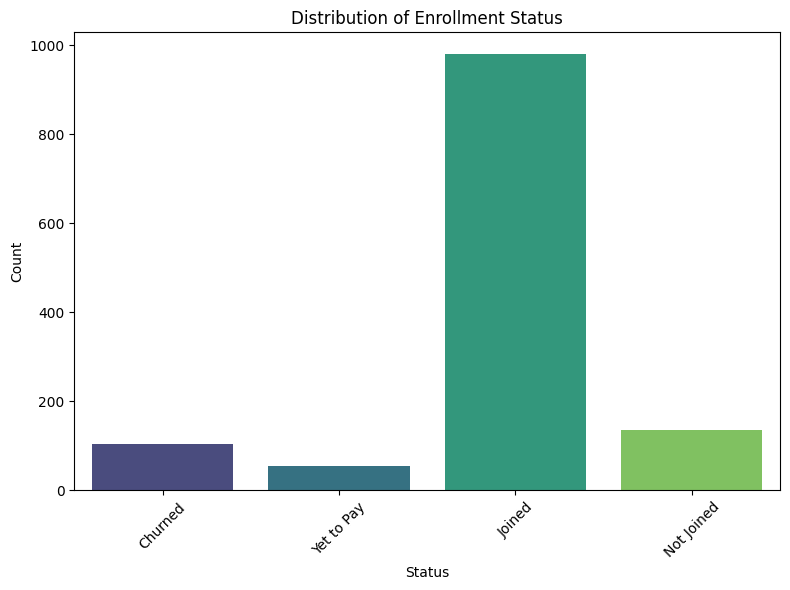

In [888]:
# Load the processed enrolled dataset
enrolled = pd.read_csv(os.path.join(ARTIFACTS_PATH, 'enrolled_processed.csv'))

print("Enrolled DataFrame Head:")
print(enrolled.head())

print("\nEnrolled DataFrame Info:")
enrolled.info()

# Visualize the distribution of the 'Status' column
plt.figure(figsize=(8, 6))
sns.countplot(data=enrolled, x='Status', palette='viridis')
plt.title('Distribution of Enrollment Status')
plt.xlabel('Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Insights and Visualizations**

Let's analyze the distribution of enrollment statuses across various key features to uncover insights into why candidates join, churn, or remain in 'Not Joined' or 'Yet to Pay' categories.

#### **1. Enrollment Status by Track Interested**

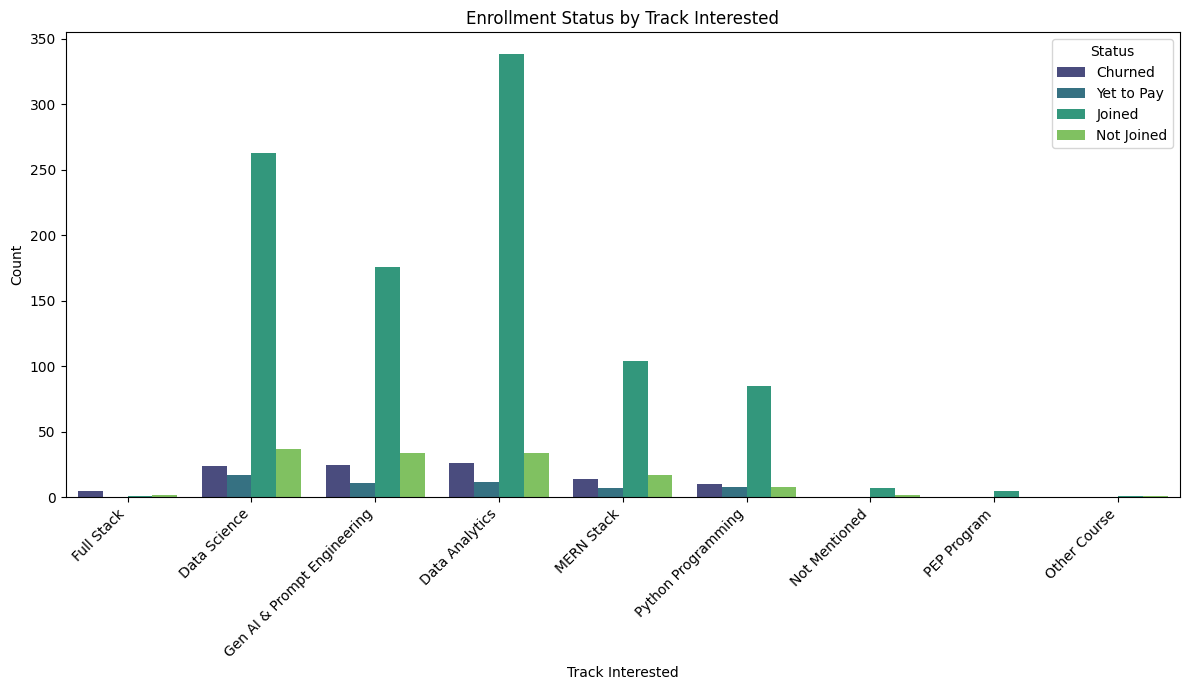

In [889]:
plt.figure(figsize=(12, 7))
sns.countplot(data=enrolled, x='Track Interested', hue='Status', palette='viridis')
plt.title('Enrollment Status by Track Interested')
plt.xlabel('Track Interested')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Status')
plt.tight_layout()
plt.show()


#### **2. Enrollment Status by Source of Lead**

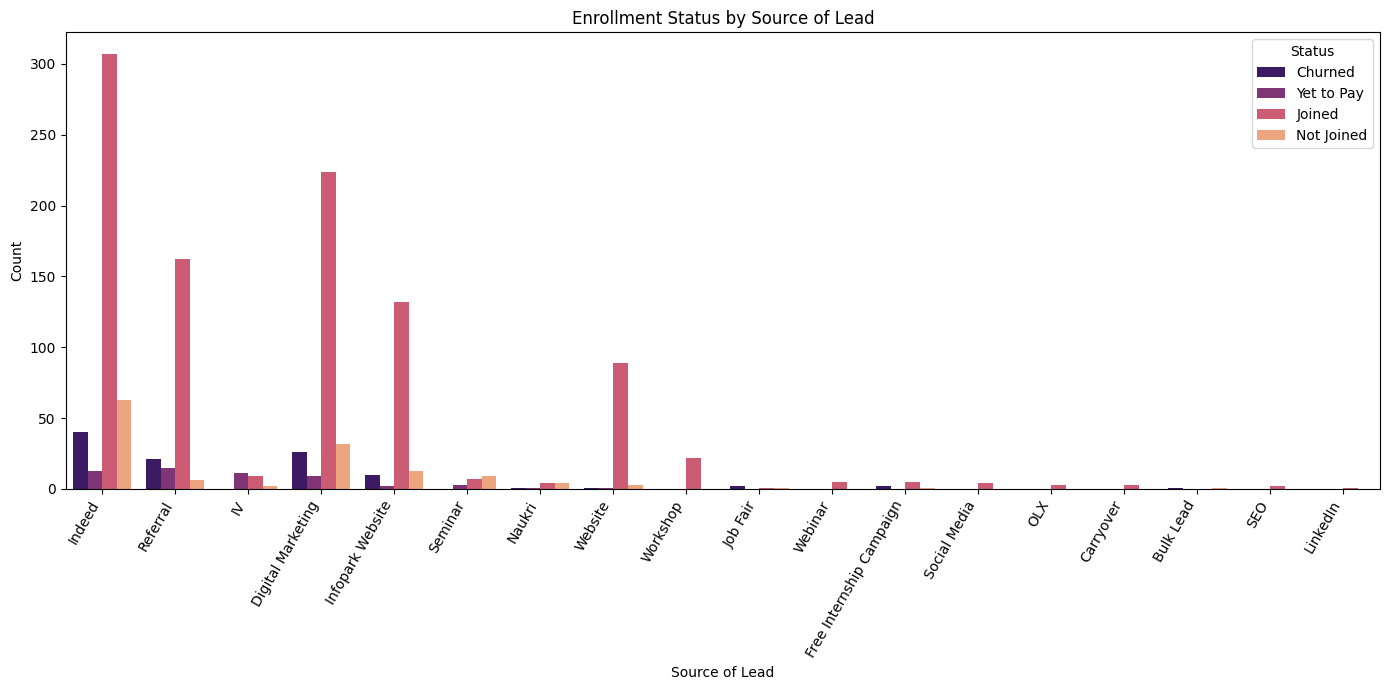

In [890]:
plt.figure(figsize=(14, 7))
sns.countplot(data=enrolled, x='Source of lead', hue='Status', palette='magma')
plt.title('Enrollment Status by Source of Lead')
plt.xlabel('Source of Lead')
plt.ylabel('Count')
plt.xticks(rotation=60, ha='right')
plt.legend(title='Status')
plt.tight_layout()
plt.show()


#### **3. Enrollment Status by Education**

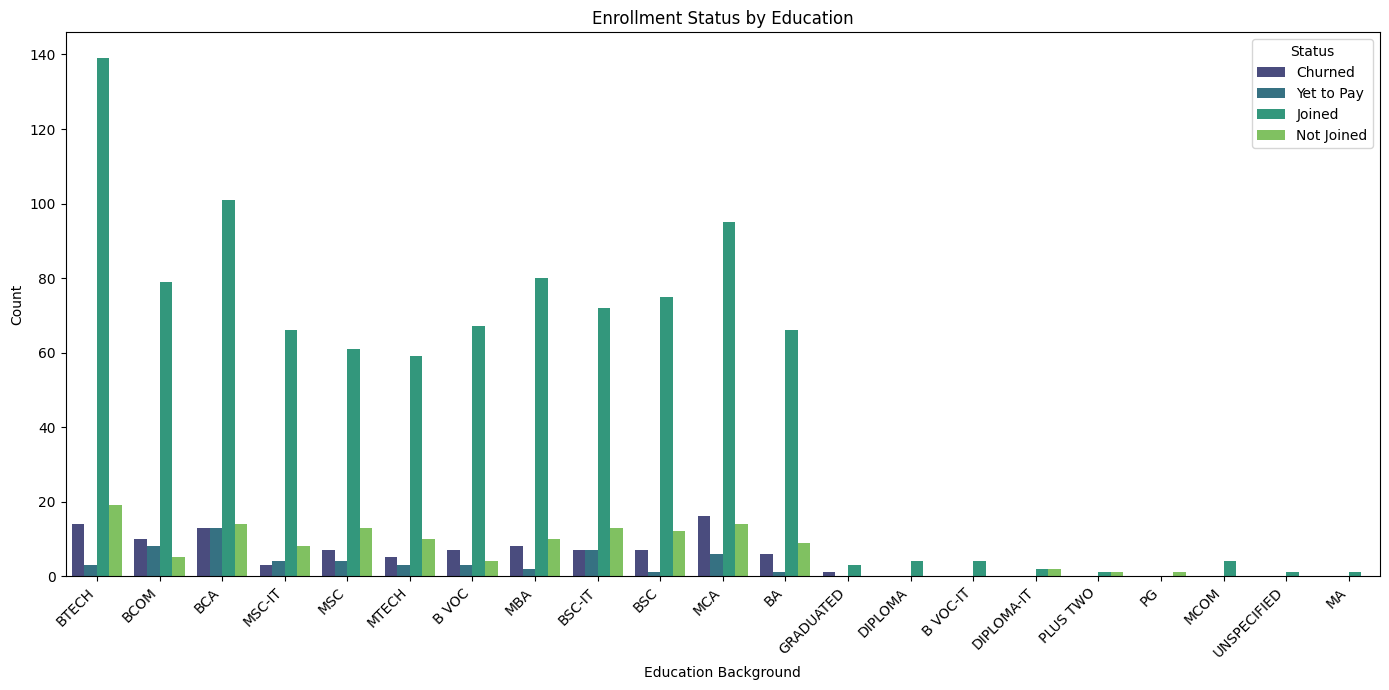

In [891]:
plt.figure(figsize=(14, 7))
sns.countplot(data=enrolled, x='Education', hue='Status', palette='viridis')
plt.title('Enrollment Status by Education')
plt.xlabel('Education Background')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

#### **4. Enrollment Status by Gender**

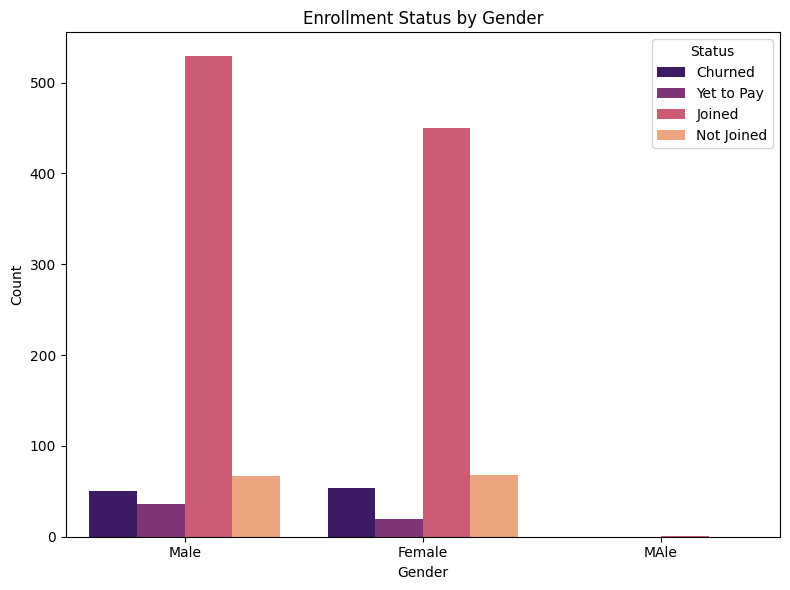

In [892]:
plt.figure(figsize=(8, 6))
sns.countplot(data=enrolled, x='Gender', hue='Status', palette='magma')
plt.title('Enrollment Status by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

#### **5. Enrollment Status by City**

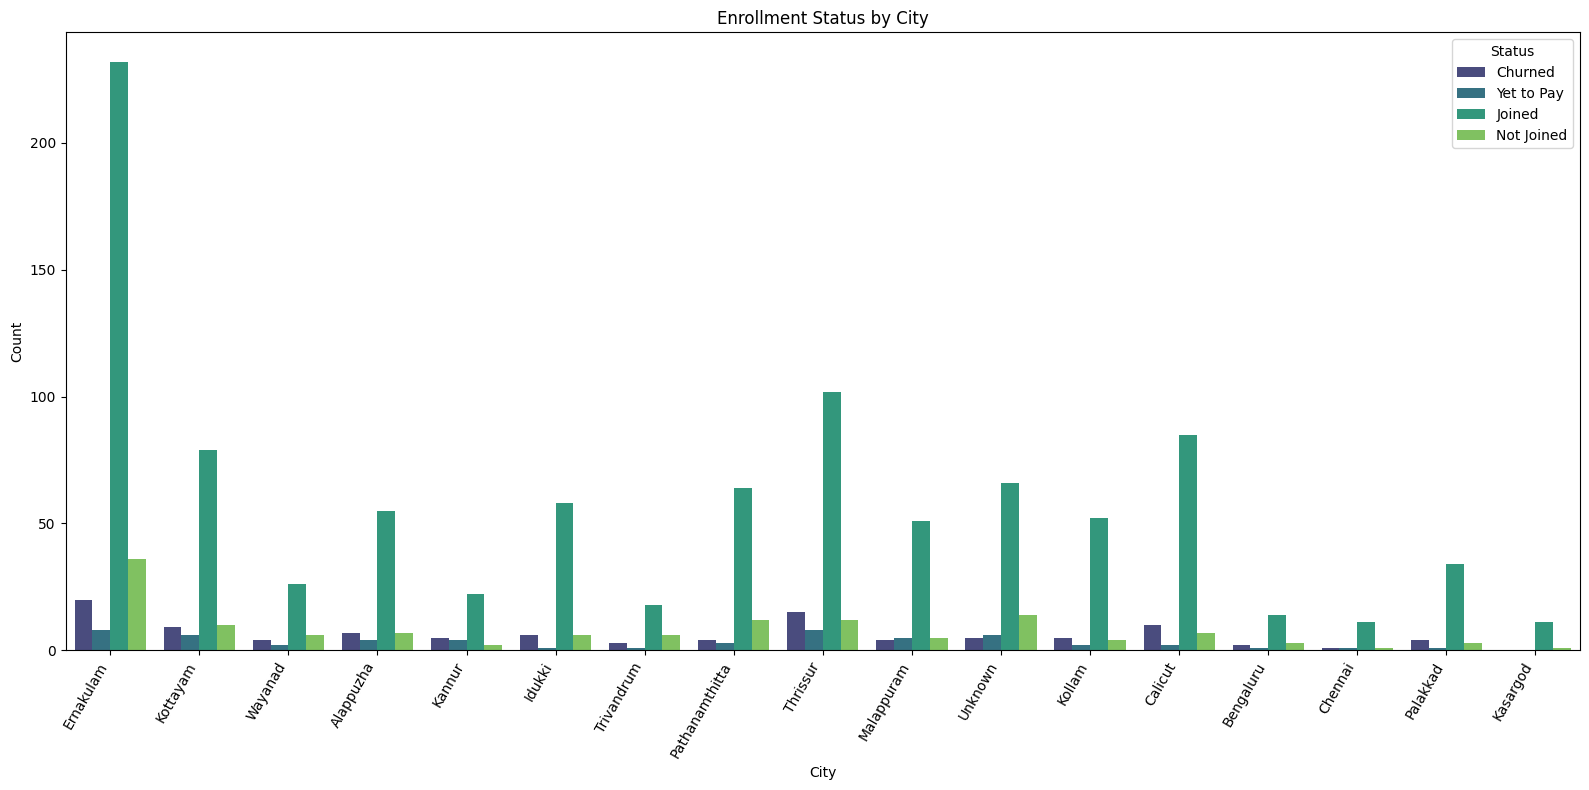

In [893]:
plt.figure(figsize=(16, 8))
sns.countplot(data=enrolled, x='City', hue='Status', palette='viridis')
plt.title('Enrollment Status by City')
plt.xlabel('City')
plt.ylabel('Count')
plt.xticks(rotation=60, ha='right')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

#### **6. Enrollment Status by Year of Graduation**

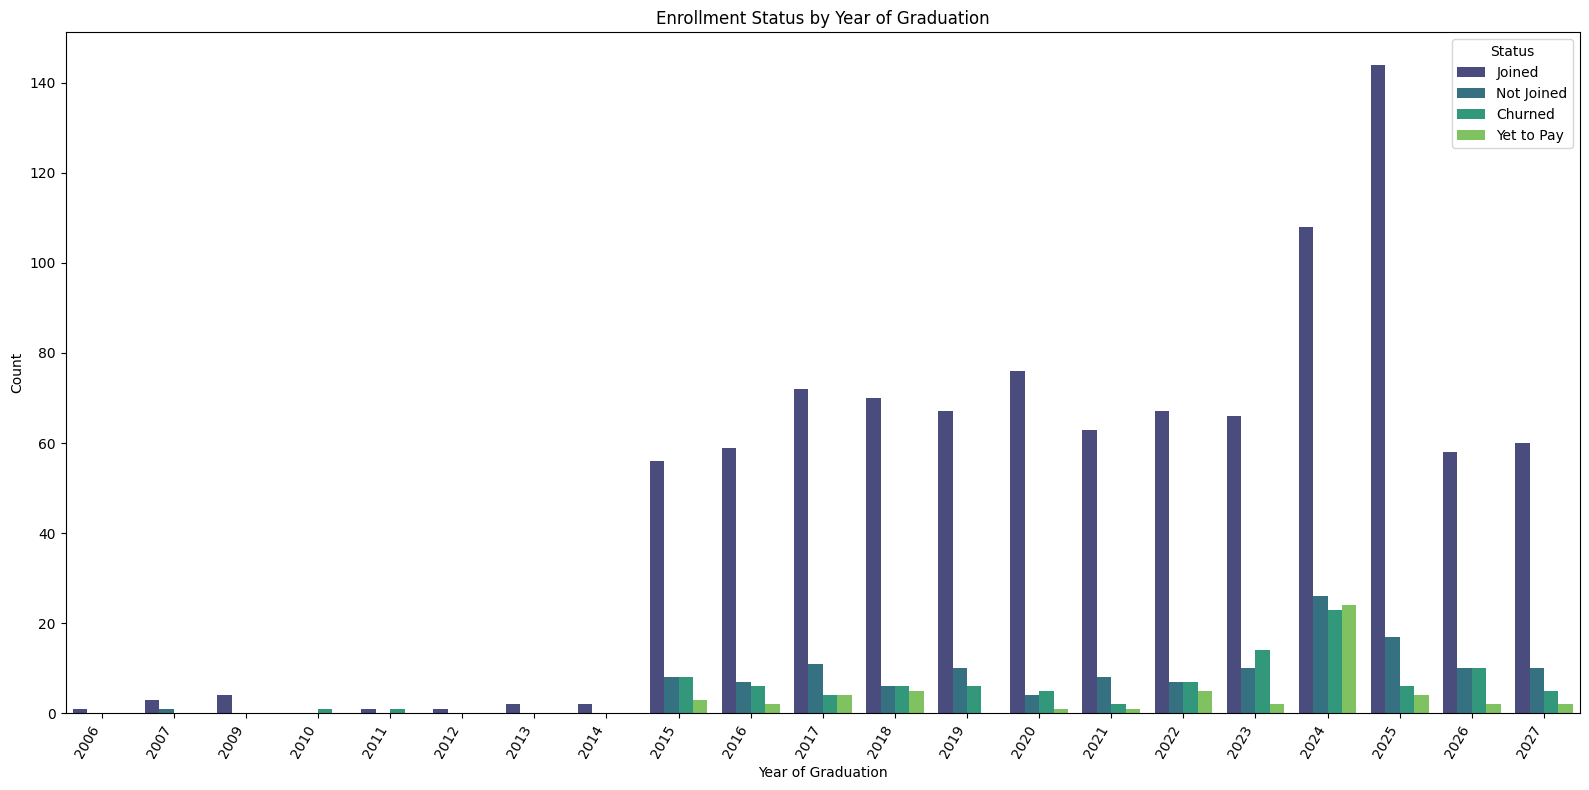

In [894]:
plt.figure(figsize=(16, 8))
sns.countplot(data=enrolled, x='Year of Graduation', hue='Status', palette='viridis')
plt.title('Enrollment Status by Year of Graduation')
plt.xlabel('Year of Graduation')
plt.ylabel('Count')
plt.xticks(rotation=60, ha='right')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

#### **7. Enrollment Status by Final Inferred Reason**

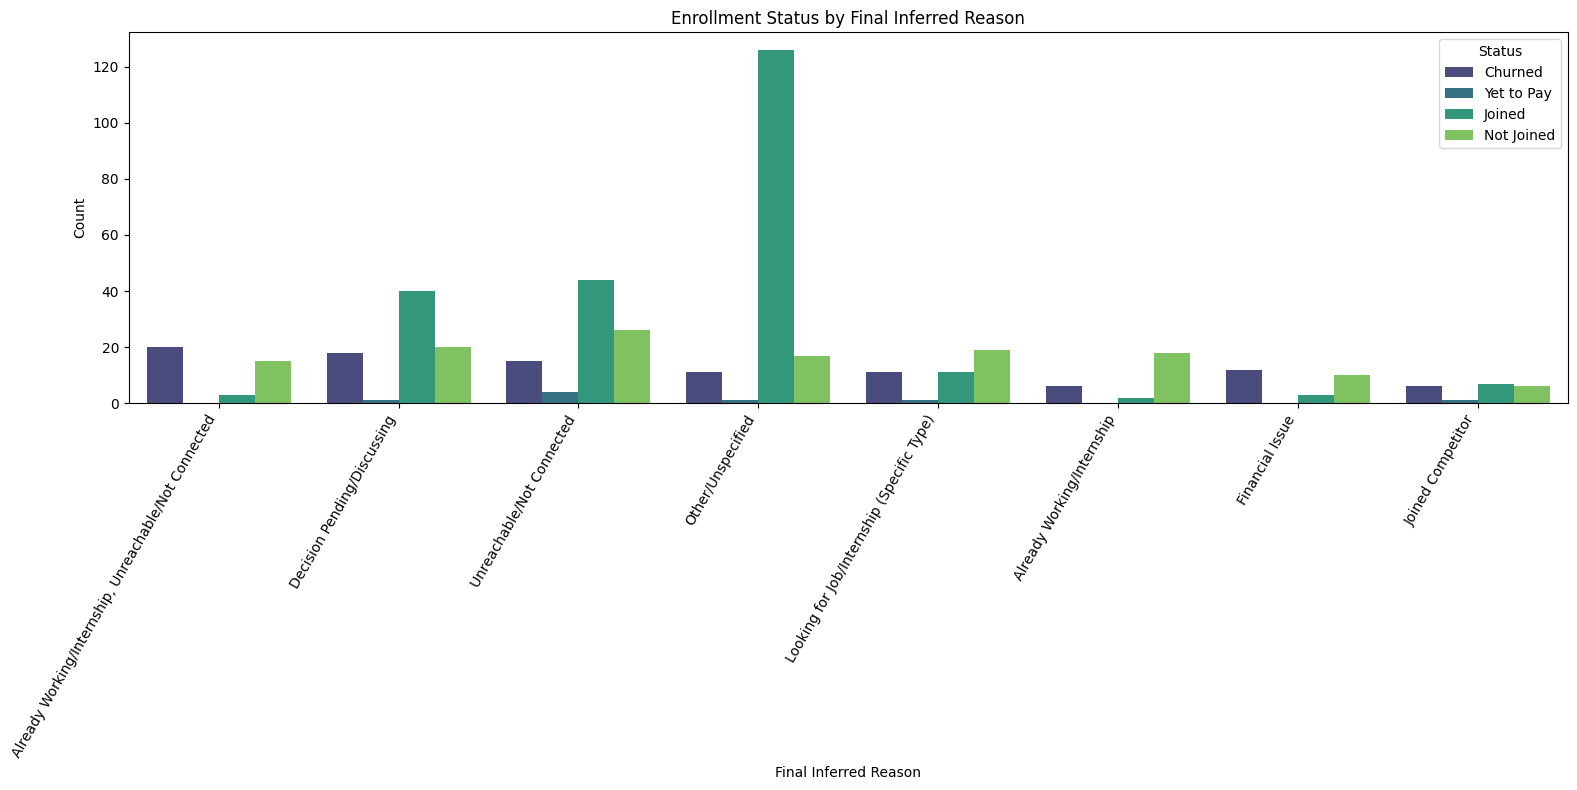

In [895]:
plt.figure(figsize=(16, 8))
sns.countplot(data=enrolled, x='final_inferred_reason', hue='Status', palette='viridis')
plt.title('Enrollment Status by Final Inferred Reason')
plt.xlabel('Final Inferred Reason')
plt.ylabel('Count')
plt.xticks(rotation=60, ha='right')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

#### **8. Enrollment Status by Experience**

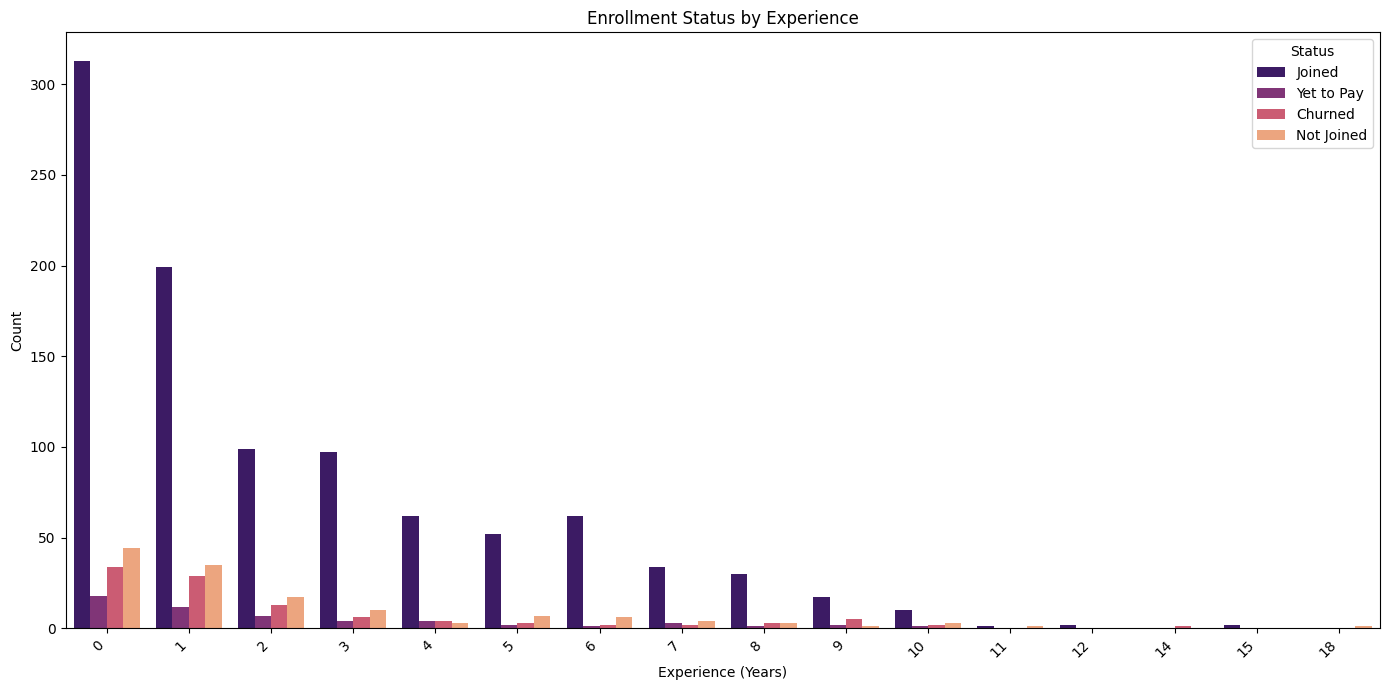

In [896]:
plt.figure(figsize=(14, 7))
sns.countplot(data=enrolled, x='Experience', hue='Status', palette='magma')
plt.title('Enrollment Status by Experience')
plt.xlabel('Experience (Years)')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

#### **9. Enrollment Status by Course**

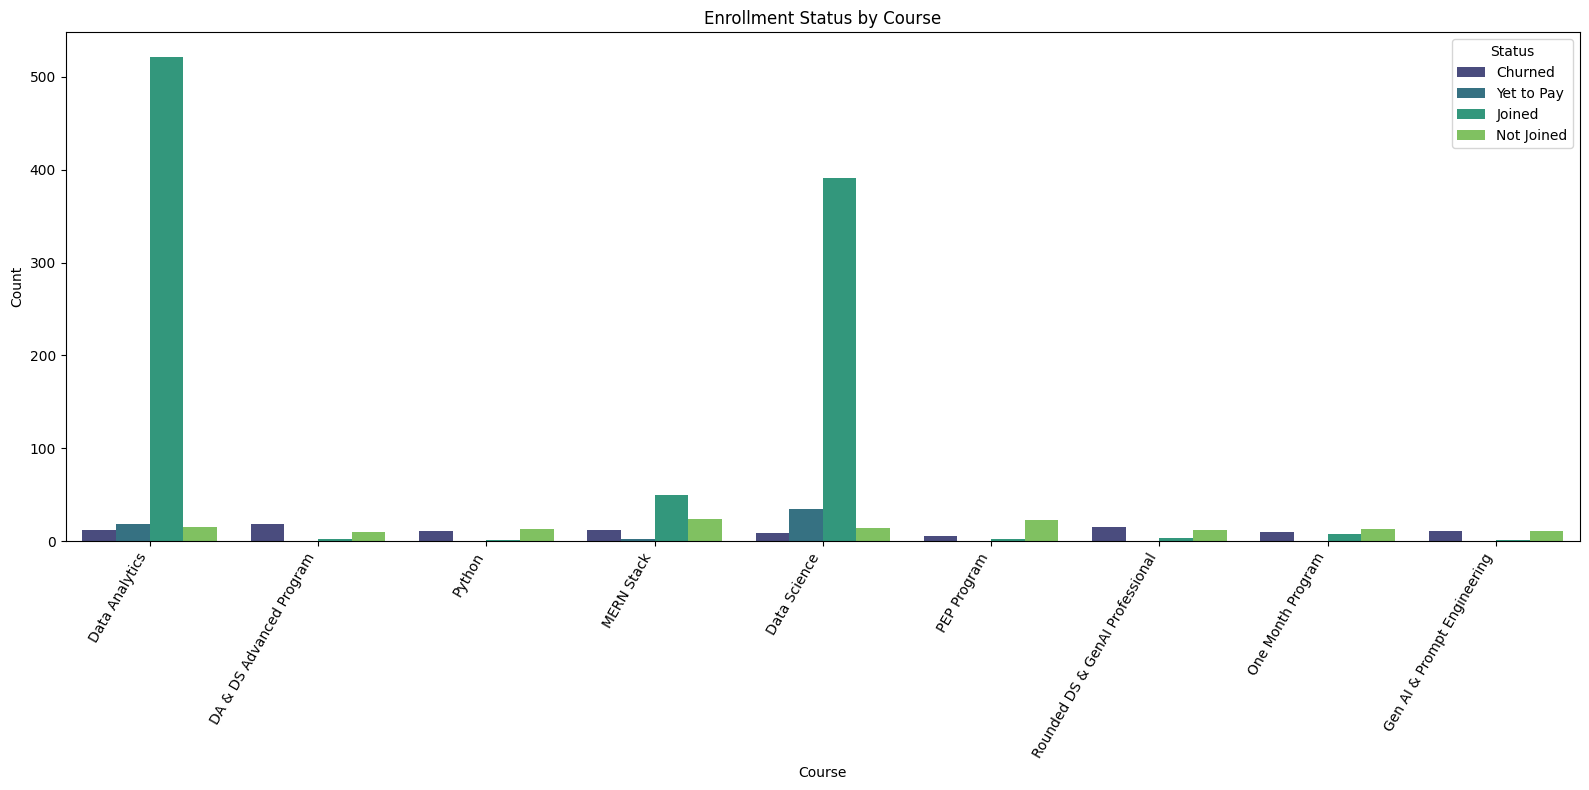

In [897]:
plt.figure(figsize=(16, 8))
sns.countplot(data=enrolled, x='Course', hue='Status', palette='viridis')
plt.title('Enrollment Status by Course')
plt.xlabel('Course')
plt.ylabel('Count')
plt.xticks(rotation=60, ha='right')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

#### **10. Enrollment Status by Role**

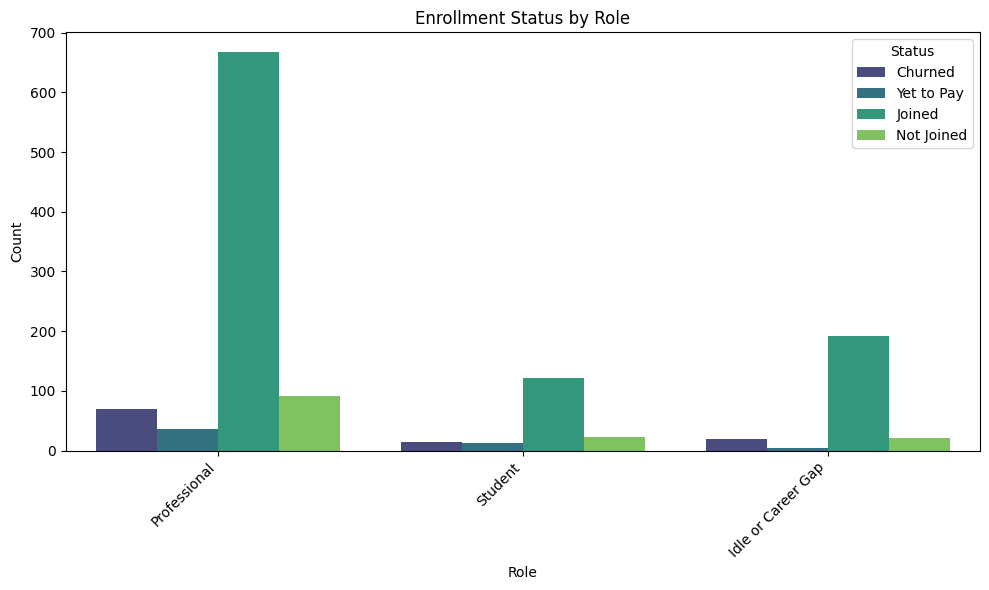

In [898]:
plt.figure(figsize=(10, 6))
sns.countplot(data=enrolled, x='role', hue='Status', palette='viridis')
plt.title('Enrollment Status by Role')
plt.xlabel('Role')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

#### **11. Enrollment Status by Background**

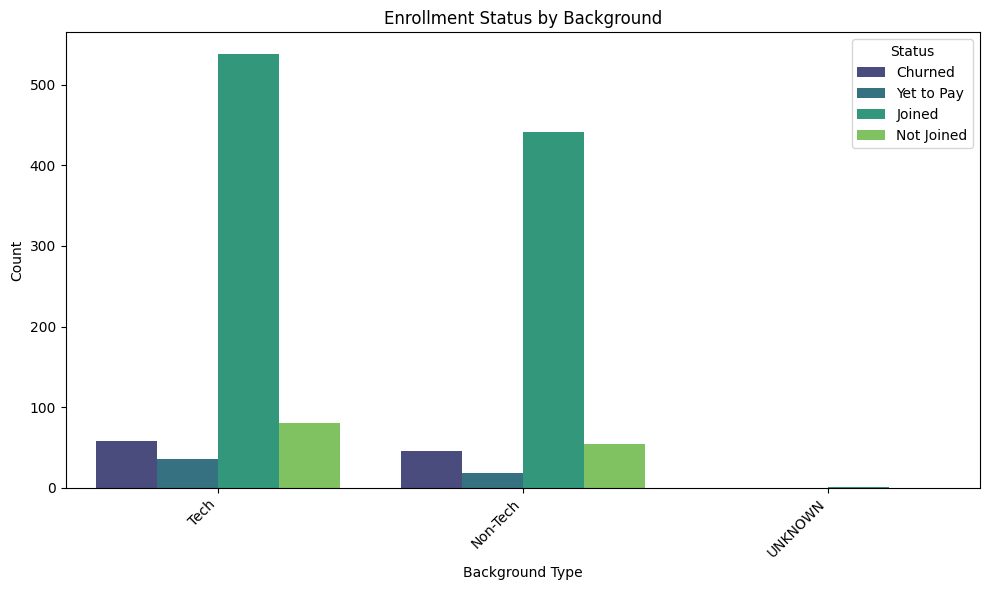

In [899]:
plt.figure(figsize=(10, 6))
sns.countplot(data=enrolled, x='background', hue='Status', palette='viridis')
plt.title('Enrollment Status by Background')
plt.xlabel('Background Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

#### **12. Enrollment Status by Payment Mode**

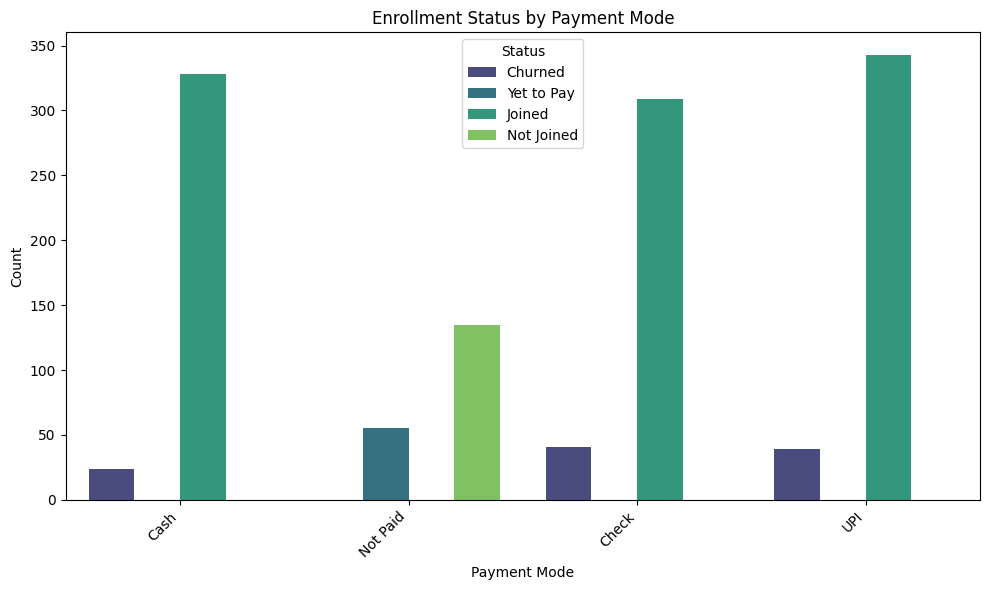

In [900]:
plt.figure(figsize=(10, 6))
sns.countplot(data=enrolled, x='Payment_mode', hue='Status', palette='viridis')
plt.title('Enrollment Status by Payment Mode')
plt.xlabel('Payment Mode')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

#### **13. Enrollment Status by Mode of Program Joined**

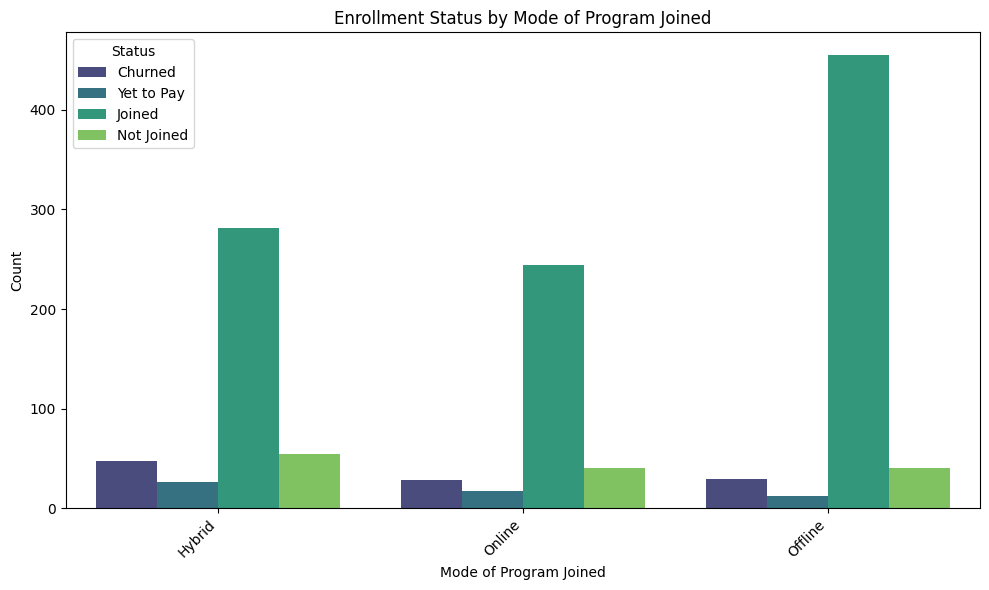

In [901]:
plt.figure(figsize=(10, 6))
sns.countplot(data=enrolled, x='Mode of Program Joined', hue='Status', palette='viridis')
plt.title('Enrollment Status by Mode of Program Joined')
plt.xlabel('Mode of Program Joined')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

#### **14. Enrollment Status by Contact Owner (Salesperson)**

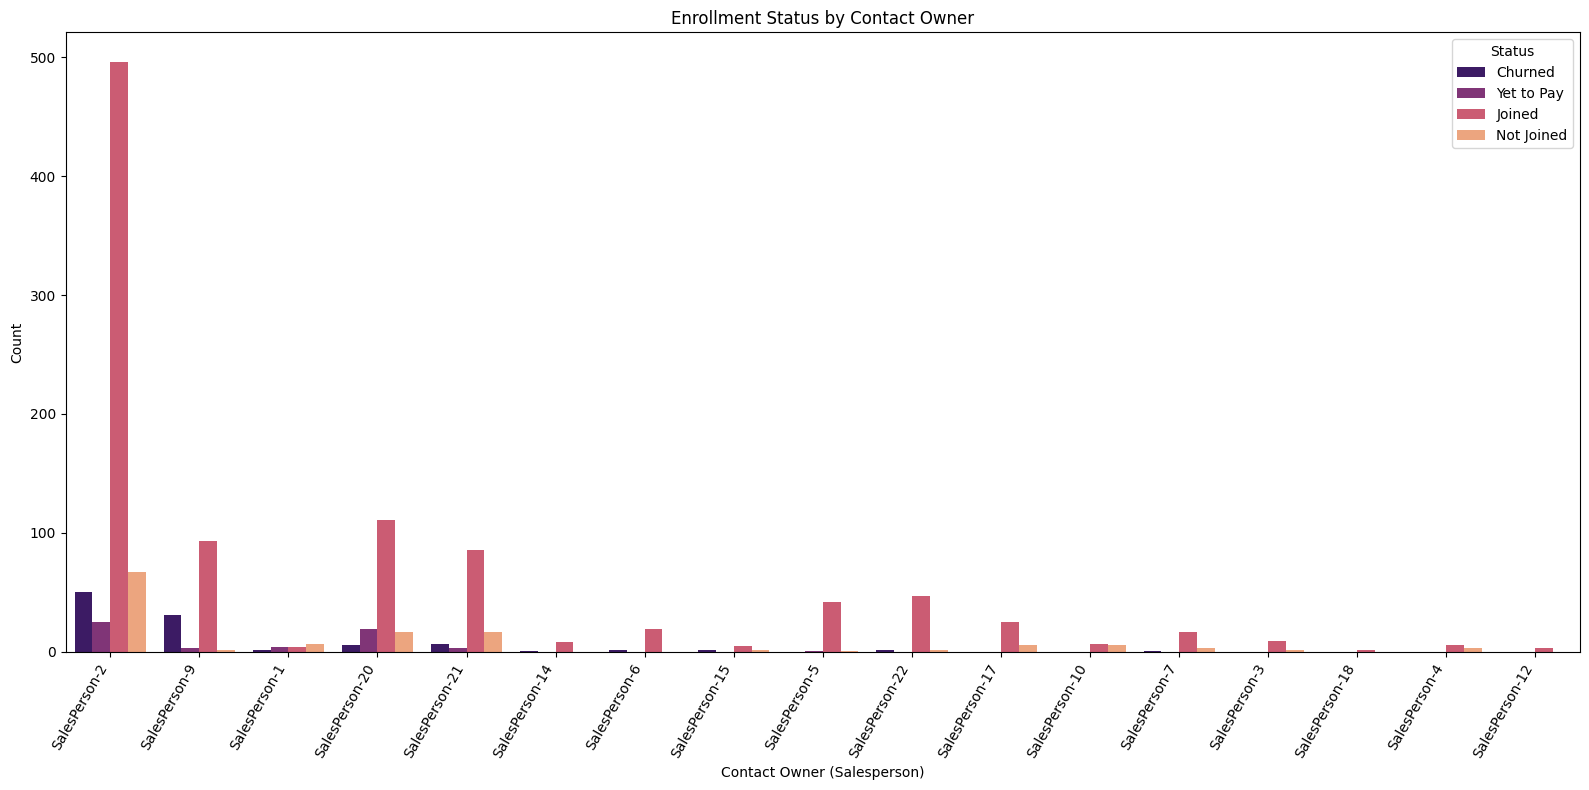

In [902]:
plt.figure(figsize=(16, 8))
sns.countplot(data=enrolled, x='Contact Owner', hue='Status', palette='magma')
plt.title('Enrollment Status by Contact Owner')
plt.xlabel('Contact Owner (Salesperson)')
plt.ylabel('Count')
plt.xticks(rotation=60, ha='right')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

#### **15. Enrollment Status by Total Amount**

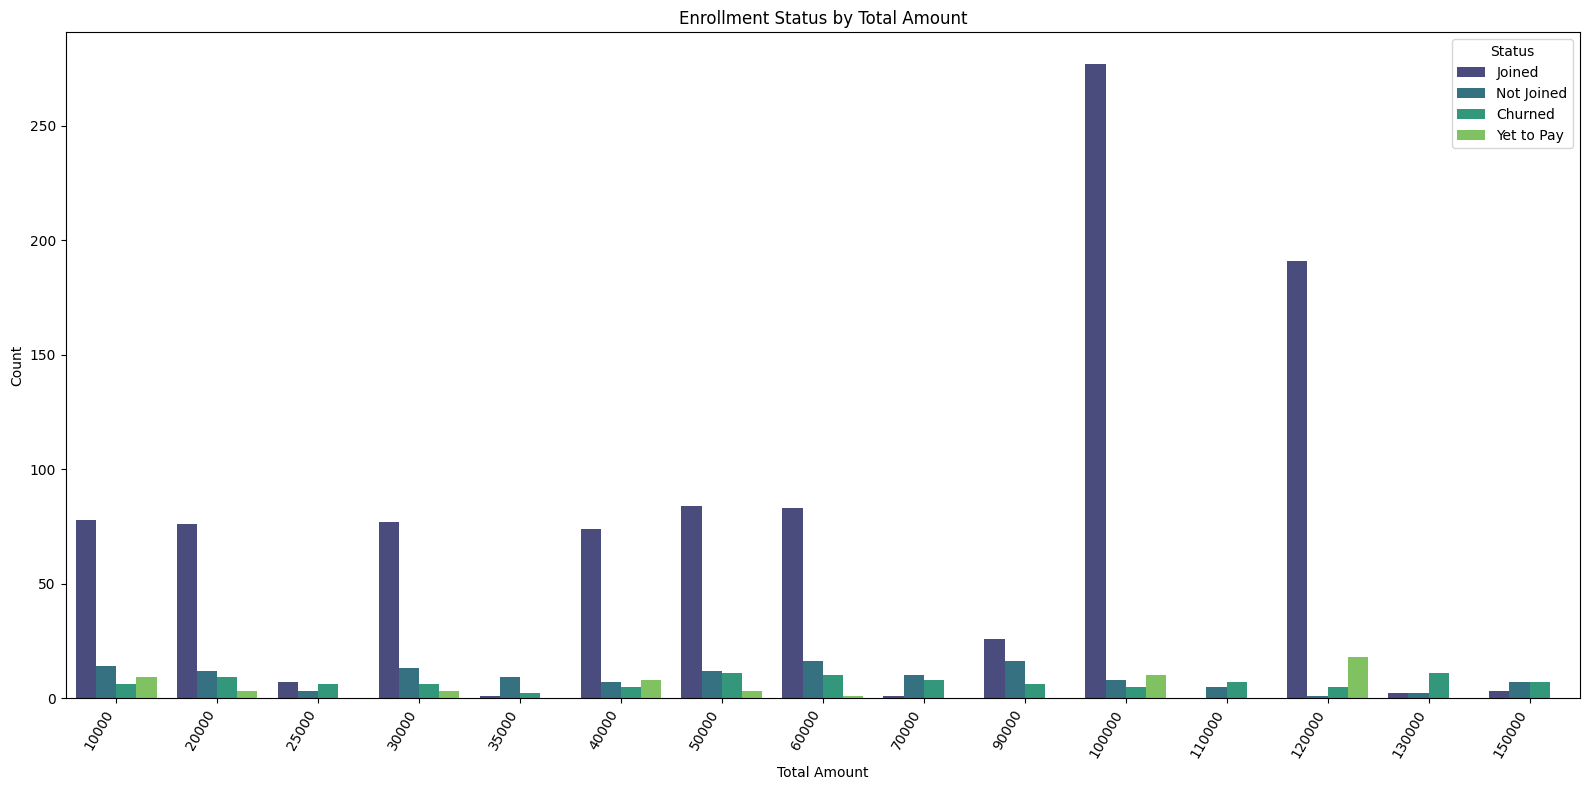

In [903]:
plt.figure(figsize=(16, 8))
sns.countplot(data=enrolled, x='Total_Amount', hue='Status', palette='viridis')
plt.title('Enrollment Status by Total Amount')
plt.xlabel('Total Amount')
plt.ylabel('Count')
plt.xticks(rotation=60, ha='right')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

#### **16. Enrollment Status by Paid Amount**

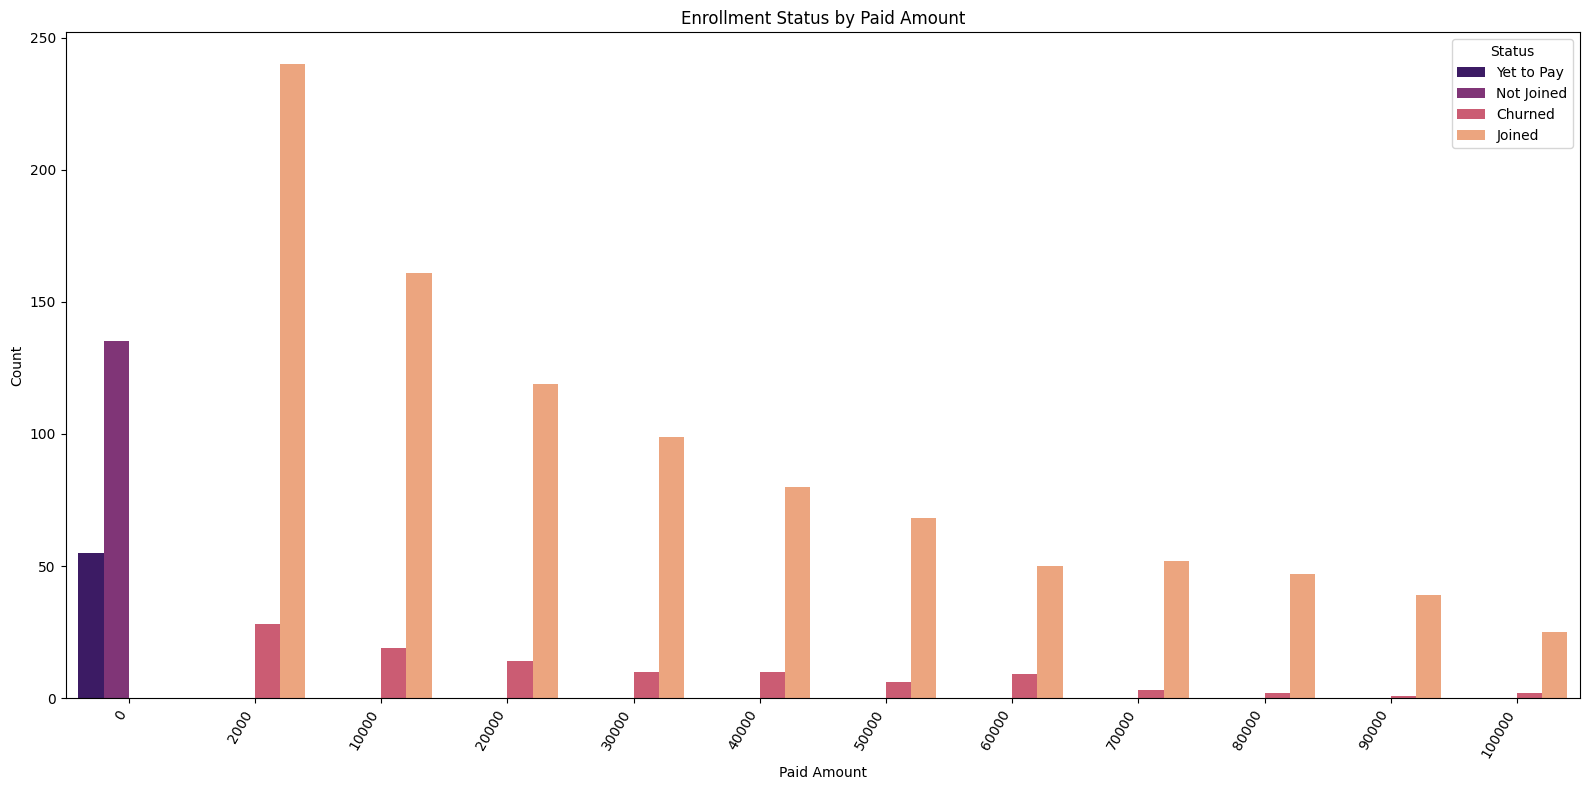

In [904]:
plt.figure(figsize=(16, 8))
sns.countplot(data=enrolled, x='Paid_amount', hue='Status', palette='magma')
plt.title('Enrollment Status by Paid Amount')
plt.xlabel('Paid Amount')
plt.ylabel('Count')
plt.xticks(rotation=60, ha='right')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

#### **17. Investigating Low Enrollment in Non-Dominant Courses**

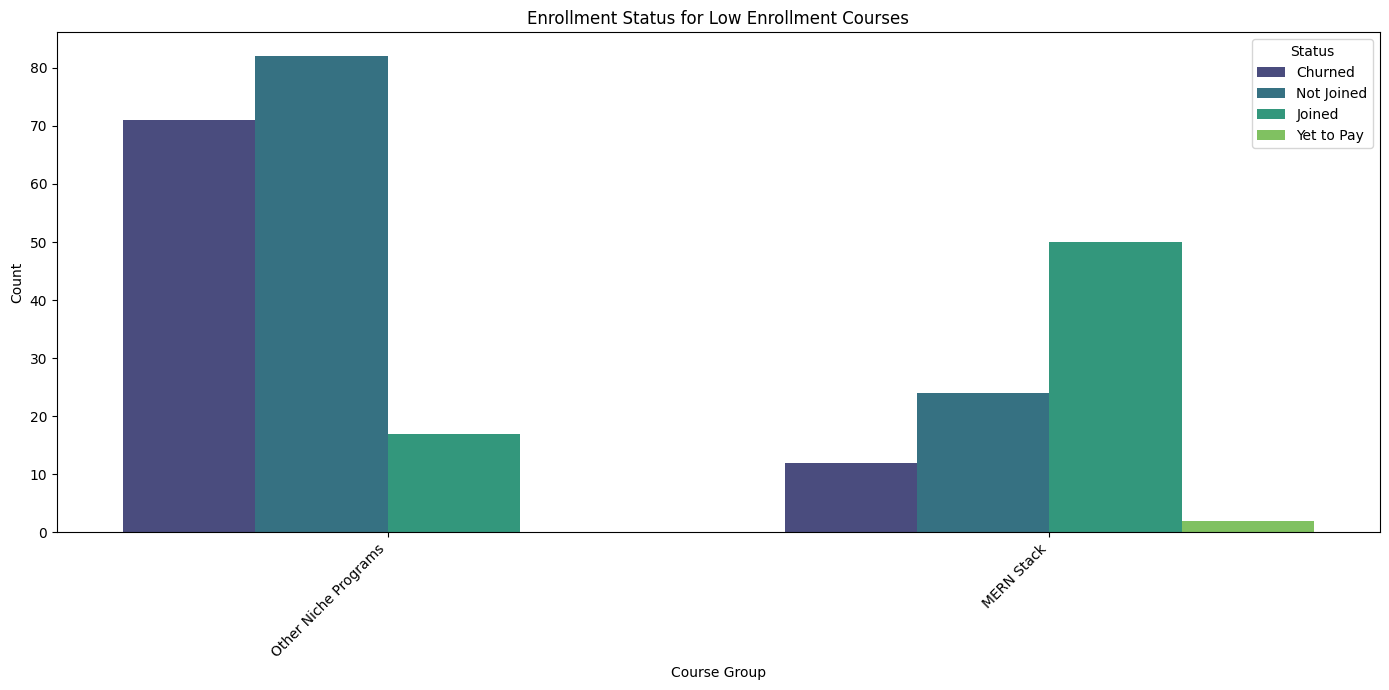

In [905]:
# Identify courses with low 'Joined' counts for deeper analysis
course_status_counts = enrolled.groupby('Course')['Status'].value_counts().unstack(fill_value=0)
low_enrollment_threshold = 50 # Courses with 50 or fewer 'Joined' candidates

low_enrollment_courses = course_status_counts[course_status_counts['Joined'] < low_enrollment_threshold].index.tolist()

# Exclude MERN Stack from generic grouping if its count is relatively higher than others but still below threshold
if 'MERN Stack' in low_enrollment_courses:
    other_niche_courses = [c for c in low_enrollment_courses if c != 'MERN Stack']
else:
    other_niche_courses = low_enrollment_courses


enrolled['Course_Grouped_Low_Enrollment'] = enrolled['Course'].apply(
    lambda x: 'Other Niche Programs' if x in other_niche_courses else x
)

# Filter for only the low enrollment courses (including MERN Stack, and the 'Other Niche Programs')
low_enrollment_df = enrolled[enrolled['Course_Grouped_Low_Enrollment'].isin(low_enrollment_courses + ['MERN Stack', 'Other Niche Programs'])].copy()

plt.figure(figsize=(14, 7))
sns.countplot(data=low_enrollment_df, x='Course_Grouped_Low_Enrollment', hue='Status', palette='viridis')
plt.title('Enrollment Status for Low Enrollment Courses')
plt.xlabel('Course Group')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

#### **18. Calculate and Analyze Paid Rate**

In [906]:
# Calculate 'Paid Rate'
enrolled['Paid_Rate'] = (enrolled['Paid_amount'] / enrolled['Total_Amount']) * 100

# Handle cases where Total_Amount is 0 to avoid division by zero or NaN results
enrolled.loc[enrolled['Total_Amount'] == 0, 'Paid_Rate'] = 0

print("First 5 rows with new 'Paid_Rate' column:")
print(enrolled[['Total_Amount', 'Paid_amount', 'Paid_Rate']].head())

First 5 rows with new 'Paid_Rate' column:
   Total_Amount  Paid_amount  Paid_Rate
0        100000        20000  20.000000
1         40000            0   0.000000
2         50000        10000  20.000000
3         70000         2000   2.857143
4         10000         2000  20.000000


/tmp/ipykernel_612/149869480.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=enrolled, x='Paid_Rate', bins=20, kde=True, palette='viridis')


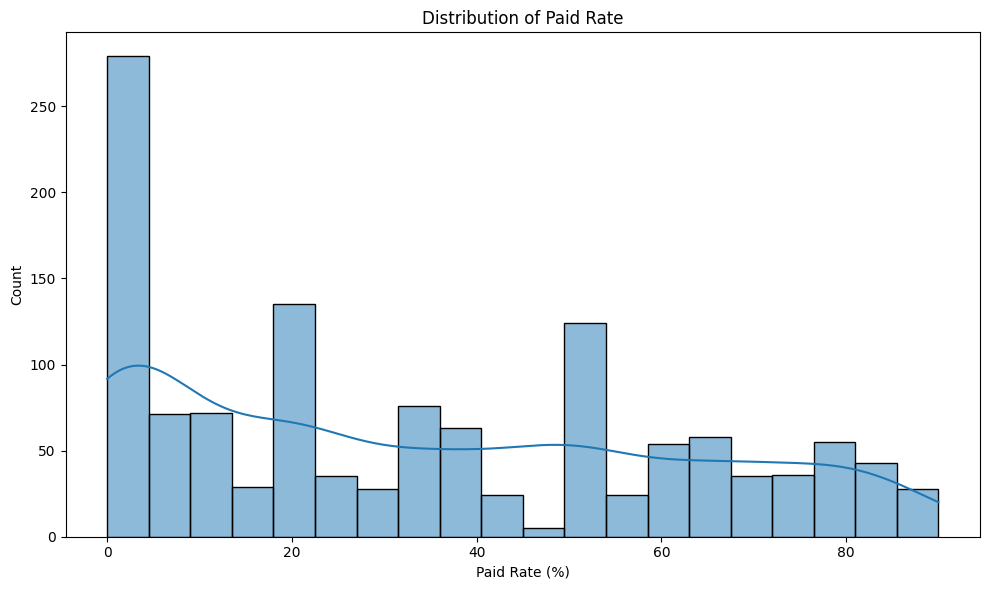

In [907]:
plt.figure(figsize=(10, 6))
sns.histplot(data=enrolled, x='Paid_Rate', bins=20, kde=True, palette='viridis')
plt.title('Distribution of Paid Rate')
plt.xlabel('Paid Rate (%)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

/tmp/ipykernel_612/217857284.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=enrolled, x='Status', y='Paid_Rate', palette='magma')


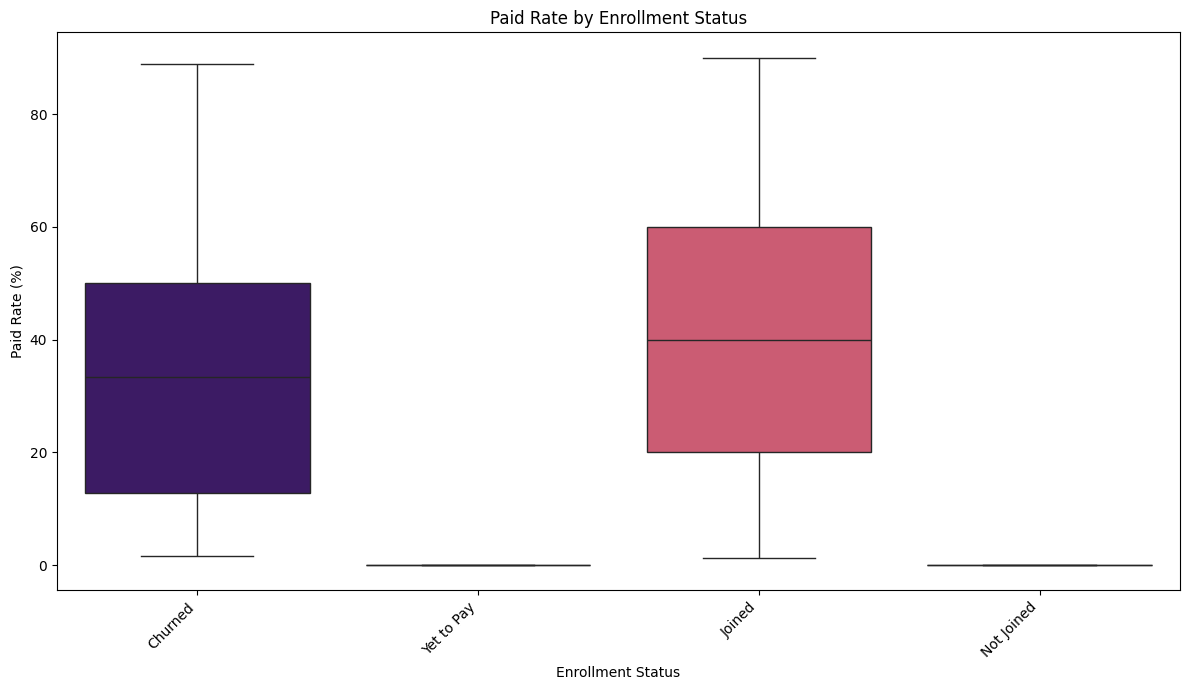

In [908]:
plt.figure(figsize=(12, 7))
sns.boxplot(data=enrolled, x='Status', y='Paid_Rate', palette='magma')
plt.title('Paid Rate by Enrollment Status')
plt.xlabel('Enrollment Status')
plt.ylabel('Paid Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### **19. Enrollment Status by Invoice Status**

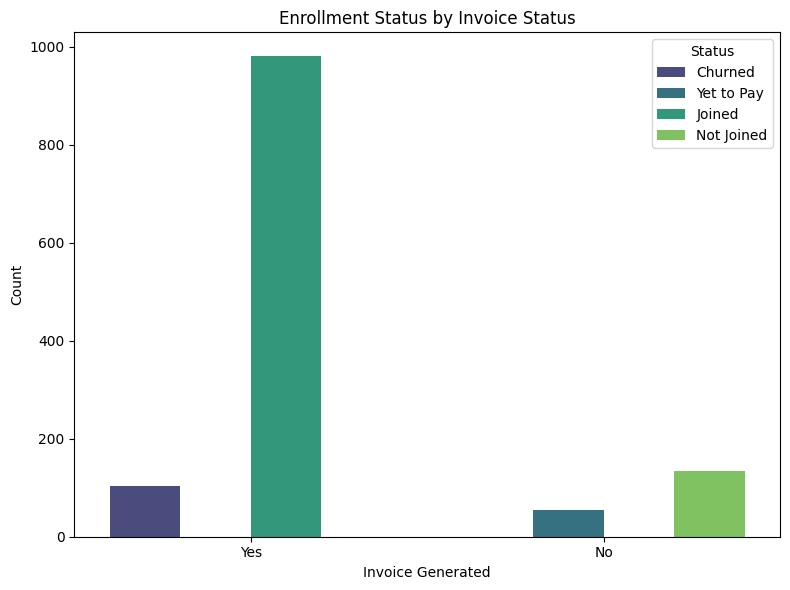

In [909]:
plt.figure(figsize=(8, 6))
sns.countplot(data=enrolled, x='Invoice', hue='Status', palette='viridis')
plt.title('Enrollment Status by Invoice Status')
plt.xlabel('Invoice Generated')
plt.ylabel('Count')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

### **Model Building: Data Preparation**

In [910]:
# Filter the DataFrame to include only 'Joined' and 'Churned' statuses
model_df = enrolled[enrolled['Status'].isin(['Joined', 'Churned'])].copy()

# Calculate 'Paid Rate' for model_df
model_df['Paid_Rate'] = (model_df['Paid_amount'] / model_df['Total_Amount']) * 100
# Handle cases where Total_Amount is 0 to avoid division by zero or NaN results
model_df.loc[model_df['Total_Amount'] == 0, 'Paid_Rate'] = 0

print("Filtered DataFrame Head (model_df):")
print(model_df.head())

print("\nDistribution of 'Status' in model_df:")
print(model_df['Status'].value_counts())

Filtered DataFrame Head (model_df):
                Contact Id         Contact Owner.id  Contact Owner  \
0  zcrm_560042000000440092  zcrm_560042000000283001  SalesPerson-2   
2  zcrm_560042000000565094  zcrm_560042000000331113  SalesPerson-9   
3  zcrm_560042000000583691  zcrm_560042000000331113  SalesPerson-9   
4  zcrm_560042000000604837  zcrm_560042000000283001  SalesPerson-2   
5  zcrm_560042000000604840  zcrm_560042000000283001  SalesPerson-2   

              Track Interested                      Tag  \
0                   Full Stack  without pipelines 18/02   
2                 Data Science          Free Internship   
3  Gen AI & Prompt Engineering                   Ayisha   
4               Data Analytics                 Enrolled   
5               Data Analytics                 Enrolled   

             Created By.id           Modified By.id      Created Time  \
0  zcrm_560042000000283001  zcrm_560042000000283001  19-12-2023 11:01   
2  zcrm_560042000000331113  zcrm_560042000

### **Feature Engineering and Data Encoding**

In [911]:
# Drop irrelevant columns for modeling
# Columns like IDs, names, times, and raw text features are usually not directly used as features.
# 'Program Joined.id' and 'Pipeline owner.id' are IDs.
# 'Contact Id', 'Contact Owner.id', 'Created By.id', 'Modified By.id' are unique identifiers.
# 'Contact Name', 'Email ID' are name-related.
# 'Created Time', 'Modified Time', 'Last Activity Time', 'Lead Generated on', 'Payment_Date' are date/time related.
# 'Whatsapp Number' is an identifier.
# 'Course_Grouped_Low_Enrollment' is a derived column for visualization and 'Tag' is also a less useful direct feature.

columns_to_drop = [
    'Contact Id', 'Contact Owner.id', 'Contact Owner', 'Created By.id', 'Modified By.id',
    'Created Time', 'Modified Time', 'Last Activity Time', 'Contact Name', 'Program Joined.id',
    'Pipeline owner.id', 'Lead Generated on', 'Whatsapp Number', 'Email ID', 'Payment_Date',
    'Course_Grouped_Low_Enrollment', 'Tag', 'Program Joined' # Removed 'Course' due to data leakage
]

# Drop columns that are no longer needed or are redundant for modeling
# Ensure these columns exist before trying to drop them
existing_columns_to_drop = [col for col in columns_to_drop if col in model_df.columns]
model_df_processed = model_df.drop(columns=existing_columns_to_drop)

print("Columns after dropping irrelevant features:")
print(model_df_processed.columns)

# Define target variable
y = model_df_processed['Status']

# Drop the original 'Status' column from features
X = model_df_processed.drop('Status', axis=1)

# Manually define categorical and numerical features based on user request
numerical_features = [
    'Semester',
    'Year of Graduation',
    'Experience',
    'Total_Amount',
    'Paid_amount',
    'Paid_Rate'
]

categorical_features = [
    'Course',
    'Track Interested',
    'City',
    'Mailing State',
    'Mailing Country',
    'Source of lead',
    'Gender',
    'Test', # Boolean, treat as categorical
    'Followup Email', # Boolean, treat as categorical
    'Invoice',
    'Mode of Program Joined',
    'Program Location',
    'Education',
    'Batch Assigned',
    'role',
    'background',
    'Stream',
    'Induction session',
    'Feedback',
    'Payment_mode' # Treat as categorical for one-hot encoding
]

# Ensure all features in X are accounted for in either numerical or categorical lists
all_defined_features = set(numerical_features + categorical_features)
missing_features_in_X = [col for col in X.columns if col not in all_defined_features]
if missing_features_in_X:
    print(f"Warning: The following features in X are not defined as numerical or categorical: {missing_features_in_X}")
    # Attempt to add them as categorical by default if not already included
    for feature in missing_features_in_X:
        categorical_features.append(feature)

# Create a column transformer for preprocessing
# One-hot encode categorical features and scale numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# --- CORRECTED ORDER: Perform train-test split BEFORE fitting preprocessor ---
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply preprocessing ONLY to the training features (fit_transform) and then transform test features
X_train_processed = preprocessor.fit_transform(X_train) # No need toarray() yet for some methods
X_test_processed = preprocessor.transform(X_test) # No need toarray() yet for some methods

# Convert target variable to numerical (0 for Churned, 1 for Joined) for both train and test
y_train_processed = y_train.map({'Churned': 0, 'Joined': 1})
y_test_processed = y_test.map({'Churned': 0, 'Joined': 1})

# Get feature names from the preprocessor
feature_names = preprocessor.get_feature_names_out()

# Convert X_train_processed (NumPy array) to DataFrame
# Ensure to convert sparse matrix to dense array using .toarray()
X_train_processed_df = pd.DataFrame(X_train_processed.toarray(), columns=feature_names, index=y_train_processed.index)

print("Shape of X_train_processed_df:", X_train_processed_df.shape)
print("First 5 rows of X_train_processed_df (features):")
print(X_train_processed_df.head())

print("\nShape of processed training features (X_train_processed):", X_train_processed.shape)
print("Shape of processed testing features (X_test_processed):", X_test_processed.shape)
print("Shape of processed training target (y_train_processed):", y_train_processed.shape)
print("Shape of processed testing target (y_test_processed):", y_test_processed.shape)

# Print the first 5 values of the processed training target to confirm mapping
print("\nFirst 5 values of processed training target (y_train_processed):")
print(y_train_processed.head())


Columns after dropping irrelevant features:
Index(['Track Interested', 'City', 'Mailing State', 'Mailing Country',
       'Source of lead', 'Semester', 'Gender', 'Year of Graduation',
       'Experience', 'Test', 'Followup Email', 'Invoice',
       'Mode of Program Joined', 'Program Location', 'Education',
       'Batch Assigned', 'Course', 'role', 'background', 'Stream',
       'Induction session', 'Feedback', 'Total_Amount', 'Paid_amount',
       'Payment_mode', 'final_inferred_reason', 'Status', 'Paid_Rate'],
      dtype='object')
Shape of X_train_processed_df: (867, 155)
First 5 rows of X_train_processed_df (features):
     num__Semester  num__Year of Graduation  num__Experience  \
306      -0.341813                 0.206535        -0.159883   
0        -0.341813                 0.970686        -0.519931   
604      -0.341813                 0.715969        -0.879979   
69        2.888176                 1.225403        -0.879979   
310       2.888176                -1.576484      

### **Imbalance Analysis**

Original class distribution of y_train_processed:
Status
1    784
0     83
Name: count, dtype: int64


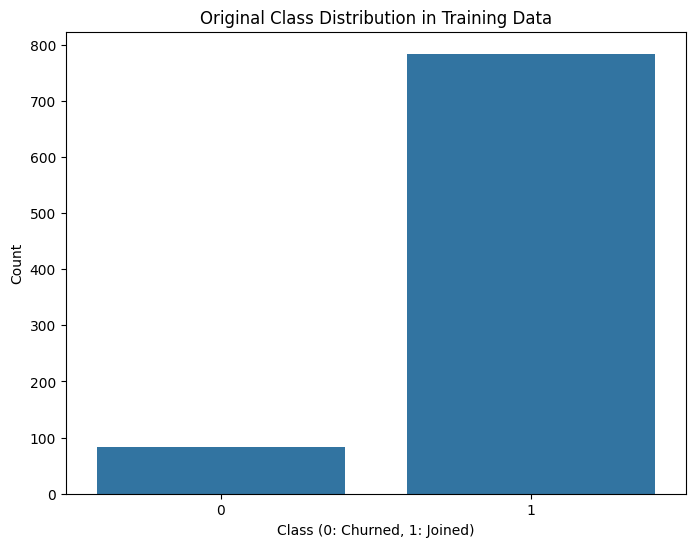

In [912]:
print("Original class distribution of y_train_processed:")
print(pd.Series(y_train_processed).value_counts())

# Visualize original class distribution
plt.figure(figsize=(8, 6))
sns.countplot(x=y_train_processed)
plt.title('Original Class Distribution in Training Data')
plt.xlabel('Class (0: Churned, 1: Joined)')
plt.ylabel('Count')
plt.show()


#### **1. Random Oversampling**

Class distribution after RandomOverSampler:
Status
1    784
0    784
Name: count, dtype: int64


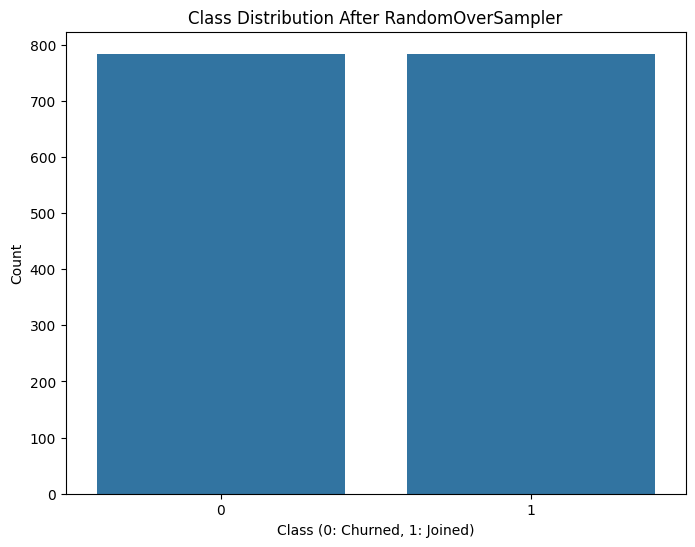

In [913]:
# Apply RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_resampled_ros, y_resampled_ros = ros.fit_resample(X_train_processed, y_train_processed)

print("Class distribution after RandomOverSampler:")
print(pd.Series(y_resampled_ros).value_counts())

# Visualize class distribution after RandomOverSampler
plt.figure(figsize=(8, 6))
sns.countplot(x=y_resampled_ros)
plt.title('Class Distribution After RandomOverSampler')
plt.xlabel('Class (0: Churned, 1: Joined)')
plt.ylabel('Count')
plt.show()


#### **2. SMOTE (Synthetic Minority Over-sampling Technique)**

Class distribution after SMOTE:
Status
1    784
0    784
Name: count, dtype: int64


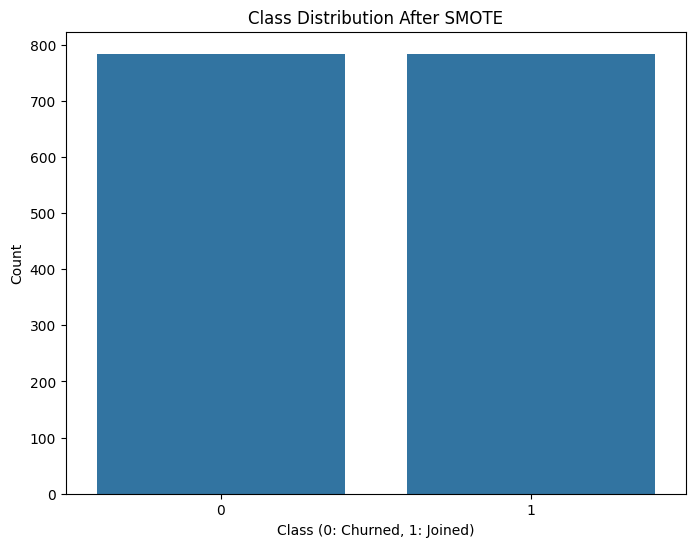

In [914]:
# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled_smote, y_resampled_smote = smote.fit_resample(X_train_processed, y_train_processed)

print("Class distribution after SMOTE:")
print(pd.Series(y_resampled_smote).value_counts())

# Visualize class distribution after SMOTE
plt.figure(figsize=(8, 6))
sns.countplot(x=y_resampled_smote)
plt.title('Class Distribution After SMOTE')
plt.xlabel('Class (0: Churned, 1: Joined)')
plt.ylabel('Count')
plt.show()


### **Evaluation of Balancing Techniques**





In [915]:
def resample_train_set(X_train_df, y_train, method='none', random_state=42):
    X_resampled, y_resampled, sample_weights = X_train_df, y_train, None

    # Convert method to lowercase for consistent comparison
    method = method.lower()

    if method == 'oversample':
        oversampler = RandomOverSampler(random_state=random_state)
        X_resampled, y_resampled = oversampler.fit_resample(X_train_df, y_train)
        print(f"[DEBUG] Oversample applied. X_resampled shape: {X_resampled.shape}, y_resampled shape: {y_resampled.shape}")
    elif method == 'undersample':
        undersampler = RandomUnderSampler(random_state=random_state)
        X_resampled, y_resampled = undersampler.fit_resample(X_train_df, y_train)
        print(f"[DEBUG] Undersample applied. X_resampled shape: {X_resampled.shape}, y_resampled shape: {y_resampled.shape}")
    elif method == 'smote':
        smote = SMOTE(random_state=random_state)
        X_resampled, y_resampled = smote.fit_resample(X_train_df, y_train)
        print(f"[DEBUG] SMOTE applied. X_resampled shape: {X_resampled.shape}, y_resampled shape: {y_resampled.shape}")
    elif method == 'class_weight':
        # For class_weight, we don't resample X_train, but compute sample weights
        # We still use the original X_train, y_train for the model training step
        # The `compute_class_weight` function takes the original y_train.
        weights = class_weight.compute_class_weight(
            class_weight='balanced',
            classes=np.unique(y_train),
            y=y_train
        )
        class_weights_dict = {cls: w for cls, w in zip(np.unique(y_train), weights)}
        # Create sample_weights for each instance in the training set
        sample_weights = y_train.map(class_weights_dict).values
        X_resampled, y_resampled = X_train_df, y_train # No actual resampling of data
        print(f"[DEBUG] Class Weight applied. No resampling of data. X_resampled shape: {X_resampled.shape}, y_resampled shape: {y_resampled.shape}")

    # Ensure X_resampled is a DataFrame with column names
    if not isinstance(X_resampled, pd.DataFrame):
        # We can reconstruct DataFrame using original column names
        # Note: This might be complex if `X_train_df` is already the processed array.
        # For this context, we assume X_train_df passed here is already a DataFrame or can provide columns.
        # A safer approach for the notebook is to convert X_train_processed *before* calling evaluate_balancing_techniques
        pass # This block assumes X_resampled is already a DataFrame or will be converted outside.

    return X_resampled, y_resampled, sample_weights

In [916]:
def evaluate_balancing_techniques(X_train_processed_df, y_train, techniques, random_state=42, base_evaluator_model=None):
    # If no base model is provided, default to Logistic Regression
    if base_evaluator_model is None:
        base_evaluator_model = LogisticRegression(solver='liblinear', random_state=random_state)

    results = {}
    for name, method in techniques.items():
        print(f"\nEvaluating: {name}")
        precisions, recalls, f1_scores = [], [], []

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

        # X_train_processed_df is now a DataFrame, so .iloc works.
        for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_processed_df, y_train)):
            X_fold_train, X_fold_val = X_train_processed_df.iloc[train_idx], X_train_processed_df.iloc[val_idx]
            y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

            # Apply balancing technique. Pass DataFrame X_fold_train.
            X_resampled, y_resampled, sample_weights = resample_train_set(X_fold_train, y_fold_train, method=method, random_state=random_state)

            # Clone the base_evaluator_model for each fold to ensure a fresh instance
            model = clone(base_evaluator_model)

            # For 'class_weight' method, pass class_weight directly to the model if sample_weights is None
            if method == 'class_weight' and sample_weights is None:
                # Calculate class weights for the current fold's training data (y_resampled is y_fold_train here)
                weights = class_weight.compute_class_weight(
                    class_weight='balanced',
                    classes=np.unique(y_resampled),
                    y=y_resampled
                )
                class_weights_dict = {cls: w for cls, w in zip(np.unique(y_resampled), weights)}
                model.set_params(class_weight=class_weights_dict)
                model.fit(X_resampled, y_resampled) # X_resampled is X_fold_train here
            elif sample_weights is not None: # This means `class_weight` method was used to get sample_weights
                model.fit(X_resampled, y_resampled, sample_weight=sample_weights)
            else:
                model.fit(X_resampled, y_resampled)

            y_pred = model.predict(X_fold_val)

            precisions.append(precision_score(y_fold_val, y_pred, zero_division=0))
            recalls.append(recall_score(y_fold_val, y_pred, zero_division=0))
            f1_scores.append(f1_score(y_fold_val, y_pred, zero_division=0))

        results[name] = {
            'Precision': np.mean(precisions),
            'Recall': np.mean(recalls),
            'F1 Score': np.mean(f1_scores)
        }
    return pd.DataFrame(results).T

In [917]:
warnings.filterwarnings("ignore", message="`use_label_encoder` is deprecated. Please use `enable_categorical` instead.")
warnings.filterwarnings("ignore", message="XGBoost provides various callback functions...")

print("\n" + "="*80)
print("STEP: CROSS-VALIDATION (Overfitting Check on TUNED Models)")
print("="*80)

print("\n Performing 5-Fold Cross-Validation on TUNED Models...")
cv_results_tuned = []

for model_name, model_info in best_tuned_models.items(): # Use tuned models
    model_instance = model_info['model'] # Get the best estimator from tuning
    print(f"\n  -- Cross-validating {model_name} (Tuned) --")
    train_f1_scores = []
    val_f1_scores = []

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Use X_train_fit and y_train_fit (which are already balanced if resampling was applied)
    # These are already in the correct format for direct use here (DataFrame for X_train_fit, Series for y_train_fit)
    X_cv = X_train_fit.copy()
    y_cv = y_train_fit.copy()

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_cv, y_cv)):
        X_fold_train, X_fold_val = X_cv.iloc[train_idx], X_cv.iloc[val_idx]
        y_fold_train, y_fold_val = y_cv.iloc[train_idx], y_cv.iloc[val_idx]

        current_model_fold = clone(model_instance) # Clone the tuned model for each fold

        # Handle models that accept class_weight parameter directly
        if best_balance_method == 'Class Weight' and hasattr(current_model_fold, 'class_weight'):
            # For GridSearchCV, model_instance already has class_weight='balanced' set if applicable.
            # Here, we re-set it to ensure it's balanced for the current fold's y_train if it's the class_weight method.
            weights_fold = class_weight.compute_class_weight(
                class_weight='balanced',
                classes=np.unique(y_fold_train),
                y=y_fold_train
            )
            class_weights_dict_fold = {cls: w for cls, w in zip(np.unique(y_fold_train), weights_fold)}
            current_model_fold.set_params(class_weight=class_weights_dict_fold)
            current_model_fold.fit(X_fold_train, y_fold_train)
        # Handle models that accept sample_weight during fit (e.g., XGBoost, but not KNN)
        elif best_balance_method == 'Class Weight' and hasattr(current_model_fold, 'fit') and 'sample_weight' in inspect.signature(current_model_fold.fit).parameters:
            # Re-compute sample_weights for the current fold's training data
            weights_fold = class_weight.compute_class_weight(
                class_weight='balanced',
                classes=np.unique(y_fold_train),
                y=y_fold_train
            )
            class_weights_dict_fold = {cls: w for cls, w in zip(np.unique(y_fold_train), weights_fold)}
            sample_weights_fold = y_fold_train.map(class_weights_dict_fold).values
            current_model_fold.fit(X_fold_train, y_fold_train, sample_weight=sample_weights_fold)
        else:
            # For other balancing methods (Oversample, Undersample, SMOTE), X_train_fit/y_train_fit are already resampled.
            # For 'Class Weight' where model does not accept class_weight or sample_weight (like KNN),
            # we just fit without explicit weighting, as the effect is handled during GridSearchCV tuning.
            current_model_fold.fit(X_fold_train, y_fold_train)

        # Predictions for train and validation folds
        y_train_pred = current_model_fold.predict(X_fold_train)
        y_val_pred = current_model_fold.predict(X_fold_val)

        train_f1 = f1_score(y_fold_train, y_train_pred, zero_division=0)
        val_f1 = f1_score(y_fold_val, y_val_pred, zero_division=0)

        train_f1_scores.append(train_f1)
        val_f1_scores.append(val_f1)

    train_mean_f1 = np.mean(train_f1_scores)
    train_std_f1 = np.std(train_f1_scores)
    val_mean_f1 = np.mean(val_f1_scores)
    val_std_f1 = np.std(val_f1_scores)

    # Overfitting check: if train F1 is significantly higher than validation F1
    overfit_gap = train_mean_f1 - val_mean_f1
    is_overfit = " YES" if overfit_gap > 0.1 else " NO" # Threshold can be adjusted

    cv_results_tuned.append({
        'Model': model_name,
        'Train_Mean': train_mean_f1,
        'Train_Std': train_std_f1,
        'Validation_Mean': val_mean_f1,
        'Validation_Std': val_std_f1,
        'Overfit_Gap': overfit_gap,
        'Is_Overfit': is_overfit
    })

cv_results_df_tuned = pd.DataFrame(cv_results_tuned)
cv_results_df_tuned = cv_results_df_tuned.sort_values(by='Validation_Mean', ascending=False) # Sorting by Validation_Mean

print("\n" + "-"*80)
print(f"{'Model':<25} {'Train Mean':<12} {'Train Std':<12} {'Validation Mean':<12} {'Validation Std':<12} {'Overfit?':<10}")
print("-"*80)
for index, row in cv_results_df_tuned.iterrows():
    print(f"{row['Model']:<25} {row['Train_Mean'] :<12.4f} {row['Train_Std'] :<12.4f} {row['Validation_Mean'] :<12.4f} {row['Validation_Std'] :<12.4f} {row['Is_Overfit'] :<10}")
print("-"*80)

print("\n Cross-Validation Summary (TUNED Models, Sorted by Validation Mean F1 Score):\n")
print(cv_results_df_tuned)



STEP: CROSS-VALIDATION (Overfitting Check on TUNED Models)

 Performing 5-Fold Cross-Validation on TUNED Models...

  -- Cross-validating Logistic Regression (Tuned) --

  -- Cross-validating Decision Tree (Tuned) --

  -- Cross-validating Random Forest (Tuned) --

  -- Cross-validating Gradient Boosting (Tuned) --

  -- Cross-validating AdaBoost (Tuned) --

  -- Cross-validating K-Nearest Neighbors (Tuned) --

  -- Cross-validating SVM (Tuned) --

  -- Cross-validating XGBoost (Tuned) --


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:22:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:22:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:22:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:22:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:


--------------------------------------------------------------------------------
Model                     Train Mean   Train Std    Validation Mean Validation Std Overfit?  
--------------------------------------------------------------------------------
SVM                       1.0000       0.0000       0.9916       0.0026        NO       
Random Forest             1.0000       0.0000       0.9855       0.0065        NO       
Logistic Regression       1.0000       0.0000       0.9832       0.0024        NO       
XGBoost                   1.0000       0.0000       0.9790       0.0071        NO       
Gradient Boosting         1.0000       0.0000       0.9784       0.0070        NO       
AdaBoost                  0.9893       0.0015       0.9783       0.0116        NO       
Decision Tree             0.9865       0.0018       0.9741       0.0106        NO       
K-Nearest Neighbors       0.9212       0.0044       0.8285       0.0232        NO       
-------------------------------

In [918]:
techniques = {
    'None': 'none',
    'Class Weight': 'class_weight',
    'Random Oversample': 'oversample',
    'Random Undersample': 'undersample',
    'SMOTE': 'smote'
}

# Define the base model for evaluating balancing techniques
# You can change this to another model (e.g., DecisionTreeClassifier()) if desired.
base_eval_model_for_balancing = LogisticRegression(solver='liblinear', random_state=42)

# Call the evaluation function with the DataFrame and processed target
evaluation_results = evaluate_balancing_techniques(X_train_processed_df, y_train_processed, techniques, base_evaluator_model=base_eval_model_for_balancing)

print("\n--- Evaluation Results Across Balancing Techniques (using Logistic Regression as base evaluator) ---")
print(evaluation_results)

# Select the best performing balance_method based on F1 Score
best_balance_method = evaluation_results['F1 Score'].idxmax()
print(f"\nBest balancing method based on F1 Score: {best_balance_method}")



Evaluating: None

Evaluating: Class Weight
[DEBUG] Class Weight applied. No resampling of data. X_resampled shape: (693, 155), y_resampled shape: (693,)
[DEBUG] Class Weight applied. No resampling of data. X_resampled shape: (693, 155), y_resampled shape: (693,)
[DEBUG] Class Weight applied. No resampling of data. X_resampled shape: (694, 155), y_resampled shape: (694,)
[DEBUG] Class Weight applied. No resampling of data. X_resampled shape: (694, 155), y_resampled shape: (694,)
[DEBUG] Class Weight applied. No resampling of data. X_resampled shape: (694, 155), y_resampled shape: (694,)

Evaluating: Random Oversample
[DEBUG] Oversample applied. X_resampled shape: (1254, 155), y_resampled shape: (1254,)
[DEBUG] Oversample applied. X_resampled shape: (1254, 155), y_resampled shape: (1254,)
[DEBUG] Oversample applied. X_resampled shape: (1254, 155), y_resampled shape: (1254,)
[DEBUG] Oversample applied. X_resampled shape: (1254, 155), y_resampled shape: (1254,)
[DEBUG] Oversample applied.

In [919]:
X_train_fit, y_train_fit, sample_weights = resample_train_set(X_train_processed_df, y_train_processed, method=best_balance_method)

print(f"Shape of X_train_fit after applying '{best_balance_method}': {X_train_fit.shape}")
print(f"Shape of y_train_fit after applying '{best_balance_method}': {y_train_fit.shape}")
print("\nDistribution of Churn in X_train_fit:")
print(y_train_fit.value_counts(normalize=True))

# 'sample_weights' will only be non-None if 'class_weight' was the chosen method
# Otherwise, it will be None, and models will not use it explicitly.
if sample_weights is not None:
    print("Sample weights have been generated for class_weight method.")
else:
    print("No explicit sample weights generated (resampling method was applied directly to data).")

# Assertion to ensure resampling occurred if method is 'oversample', 'undersample', or 'smote'
if best_balance_method.lower() in ['random oversample', 'random undersample', 'smote']:
    original_minority_count = y_train_processed.value_counts()[0]
    original_majority_count = y_train_processed.value_counts()[1]
    resampled_minority_count = y_train_fit.value_counts()[0]
    resampled_majority_count = y_train_fit.value_counts()[1]

    if best_balance_method.lower() == 'smote':
        # SMOTE aims to balance the classes so minority count should become equal to majority count
        assert resampled_minority_count == original_majority_count, f"SMOTE failed: Minority count mismatch. Expected {original_majority_count}, got {resampled_minority_count}"
        assert resampled_majority_count == original_majority_count, f"SMOTE failed: Majority count mismatch. Expected {original_majority_count}, got {resampled_majority_count}"
        print(f"\n[INFO] SMOTE resampling confirmed: Minority class count ({resampled_minority_count}) now equals majority class count ({original_majority_count}).")
    elif best_balance_method.lower() == 'random oversample':
        # RandomOverSampler also balances to majority class count by default
        assert resampled_minority_count == original_majority_count, f"Oversample failed: Minority count mismatch. Expected {original_majority_count}, got {resampled_minority_count}"
        assert resampled_majority_count == original_majority_count, f"Oversample failed: Majority count mismatch. Expected {original_majority_count}, got {resampled_majority_count}"
        print(f"\n[INFO] Oversample resampling confirmed: Minority class count ({resampled_minority_count}) now equals majority class count ({original_majority_count}).")
    elif best_balance_method.lower() == 'random undersample':
        # RandomUnderSampler reduces majority to minority class count by default
        assert resampled_majority_count == original_minority_count, f"Undersample failed: Majority count mismatch. Expected {original_minority_count}, got {resampled_majority_count}"
        assert resampled_minority_count == original_minority_count, f"Undersample failed: Minority count mismatch. Expected {original_minority_count}, got {resampled_minority_count}"
        print(f"\n[INFO] Undersample resampling confirmed: Majority class count ({resampled_majority_count}) now equals minority class count ({original_minority_count}).")

Shape of X_train_fit after applying 'None': (867, 155)
Shape of y_train_fit after applying 'None': (867,)

Distribution of Churn in X_train_fit:
Status
1    0.904268
0    0.095732
Name: proportion, dtype: float64
No explicit sample weights generated (resampling method was applied directly to data).


In [920]:
# Define the models with a fixed random_state for reproducibility
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(), # KNN does not have a random_state parameter
    'SVM': SVC(random_state=42, probability=True), # probability=True is needed for ROC-AUC
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss') # Suppress warning for use_label_encoder
}

print("Defined the following models:")
for name, model in models.items():
    print(f"- {name}: {model.__class__.__name__}")

Defined the following models:
- Logistic Regression: LogisticRegression
- Decision Tree: DecisionTreeClassifier
- Random Forest: RandomForestClassifier
- Gradient Boosting: GradientBoostingClassifier
- AdaBoost: AdaBoostClassifier
- K-Nearest Neighbors: KNeighborsClassifier
- SVM: SVC
- XGBoost: XGBClassifier


In [921]:
# Dictionary to store all evaluation results
all_results = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1 Score': [],
    'ROC AUC': [],
    'Training Time (s)': []
}

# Ensure X_test_processed is consistently a NumPy array for prediction
# It's already defined as .toarray() but ensure it's handled as an array here
if isinstance(X_test_processed, pd.DataFrame):
    X_test_processed_array = X_test_processed.values
elif hasattr(X_test_processed, 'toarray'):
    X_test_processed_array = X_test_processed.toarray()
else:
    X_test_processed_array = X_test_processed

# Loop through each model, train, predict, and evaluate
for name, model in models.items():
    start_time = time.time()

    # Ensure X_train_fit is always a NumPy array for model fitting
    if isinstance(X_train_fit, pd.DataFrame):
        X_train_fit_array = X_train_fit.values
    else:
        X_train_fit_array = X_train_fit

    # Handle class_weight for models that support it through class_weight parameter
    if best_balance_method == 'Class Weight' and hasattr(model, 'class_weight'):
        # Create a balanced class_weight dictionary for the model
        weights = class_weight.compute_class_weight(
            class_weight='balanced',
            classes=np.unique(y_train_fit), # Use y_train_fit from previous step
            y=y_train_fit
        )
        class_weights_dict = {cls: w for cls, w in zip(np.unique(y_train_fit), weights)}
        model.set_params(class_weight=class_weights_dict)
        model.fit(X_train_fit_array, y_train_fit) # Use the array version
    # For models that don't have a class_weight parameter but accept sample_weight during fit (e.g., XGBoost, scikit-learn ensembles)
    elif best_balance_method == 'Class Weight' and sample_weights is not None:
        model.fit(X_train_fit_array, y_train_fit, sample_weight=sample_weights)
    else:
        # For other balancing methods or if no special handling is needed (e.g., SMOTE, Oversample already modified X_train_fit)
        model.fit(X_train_fit_array, y_train_fit)

    training_time = time.time() - start_time

    y_pred = model.predict(X_test_processed_array) # Use the array version

    accuracy = accuracy_score(y_test_processed, y_pred)
    precision = precision_score(y_test_processed, y_pred, zero_division=0)
    recall = recall_score(y_test_processed, y_pred, zero_division=0)
    f1 = f1_score(y_test_processed, y_pred, zero_division=0)

    # Calculate ROC AUC. Some models (like SVC without probability=True) don't have predict_proba.
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_processed_array)[:, 1]
    elif hasattr(model, 'decision_function'): # For SVM with decision_function
        y_proba = model.decision_function(X_test_processed_array)
    else:
        y_proba = y_pred # Fallback, though not ideal for ROC AUC

    try:
        roc_auc = roc_auc_score(y_test_processed, y_proba)
    except ValueError:
        roc_auc = np.nan # Handle cases where ROC AUC cannot be computed (e.g., only one class present)

    all_results['Model'].append(name)
    all_results['Accuracy'].append(accuracy)
    all_results['Precision'].append(precision)
    all_results['Recall'].append(recall)
    all_results['F1 Score'].append(f1)
    all_results['ROC AUC'].append(roc_auc)
    all_results['Training Time (s)'].append(training_time)

# Create a DataFrame from the results
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values(by='F1 Score', ascending=False).reset_index(drop=True)

print("\n--- Model Evaluation Results ---")
print(results_df)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:23:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Model Evaluation Results ---
                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC  \
0             AdaBoost  0.953917   0.960396  0.989796  0.974874  0.973639   
1    Gradient Boosting  0.949309   0.951220  0.994898  0.972569  0.968173   
2              XGBoost  0.949309   0.964824  0.979592  0.972152  0.972060   
3  Logistic Regression  0.944700   0.955446  0.984694  0.969849  0.969388   
4        Random Forest  0.940092   0.937799  1.000000  0.967901  0.988946   
5        Decision Tree  0.940092   0.964467  0.969388  0.966921  0.818027   
6                  SVM  0.926267   0.924528  1.000000  0.960784  0.962585   
7  K-Nearest Neighbors  0.907834   0.907407  1.000000  0.951456  0.710155   

   Training Time (s)  
0           0.233836  
1           0.582178  
2           0.286590  
3           0.008652  
4           0.332015  
5           0.010649  
6           0.242788  
7           0.001215  


### **Cross-Validation Check for Overfitting**

In [922]:
warnings.filterwarnings("ignore", message="`use_label_encoder` is deprecated. Please use `enable_categorical` instead.")
warnings.filterwarnings("ignore", message="XGBoost provides various callback functions...")

print("\n" + "="*80)
print("STEP: CROSS-VALIDATION (Overfitting Check on UNTUNED Models)")
print("="*80)

print("\n Performing 5-Fold Cross-Validation on UNTUNED Models...")
cv_results_untuned = []

for name, model in models.items(): # Use original models here (untuned)
    print(f"\n  -- Cross-validating {name} --")
    train_f1_scores = []
    val_f1_scores = [] # Renamed from test_f1_scores for clarity in CV

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Use X_train_processed_df and y_train_processed for cross-validation
    X_cv = X_train_processed_df.copy()
    y_cv = y_train_processed.copy()

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_cv, y_cv)):
        X_fold_train, X_fold_val = X_cv.iloc[train_idx], X_cv.iloc[val_idx]
        y_fold_train, y_fold_val = y_cv.iloc[train_idx], y_cv.iloc[val_idx]

        current_model_fold = clone(model) # Clone the model for each fold

        # Use sample_weights if provided by the best balancing method (e.g., class_weight)
        if best_balance_method == 'Class Weight':
            # Ensure model is initialized with class_weight if it's the best balancing method
            if isinstance(current_model_fold, (LogisticRegression, DecisionTreeClassifier, RandomForestClassifier, SVC)):
                if hasattr(current_model_fold, 'class_weight'): # Check if it accepts class_weight parameter directly
                    current_model_fold.set_params(class_weight='balanced')
                elif isinstance(current_model_fold, LogisticRegression): # Explicitly set for LogisticRegression
                    current_model_fold = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')
                elif isinstance(current_model_fold, SVC): # Explicitly set for SVC
                    current_model_fold = SVC(random_state=42, probability=True, class_weight='balanced')
                elif isinstance(current_model_fold, RandomForestClassifier): # Explicitly set for RandomForestClassifier
                    current_model_fold = RandomForestClassifier(random_state=42, class_weight='balanced')
                elif isinstance(current_model_fold, DecisionTreeClassifier): # Explicitly set for DecisionTreeClassifier
                    current_model_fold = DecisionTreeClassifier(random_state=42, class_weight='balanced')
            elif isinstance(current_model_fold, XGBClassifier):
                # Calculate scale_pos_weight for XGBoost based on current fold's y_train
                unique_classes = np.unique(y_fold_train)
                if len(unique_classes) > 1 and unique_classes[0] == 0 and unique_classes[1] == 1:
                    pos_count = np.sum(y_fold_train == 1)
                    neg_count = np.sum(y_fold_train == 0)
                    scale_pos_weight_val = neg_count / pos_count if pos_count > 0 else 1
                    current_model_fold.set_params(scale_pos_weight=scale_pos_weight_val)

            # For 'Class Weight' method, X_cv and y_cv are the original ones, but fit is done with class_weight param.
            current_model_fold.fit(X_fold_train, y_fold_train)
        else:
            # For other balancing methods (Oversample, Undersample, SMOTE), X_train_fit/y_train_fit are already resampled.
            # Here, X_fold_train and y_fold_train already reflect the resampling for the fold.
            current_model_fold.fit(X_fold_train, y_fold_train)

        # Predictions for training and validation sets
        y_train_pred = current_model_fold.predict(X_fold_train)
        y_val_pred = current_model_fold.predict(X_fold_val) # Renamed for clarity

        train_f1 = f1_score(y_fold_train, y_train_pred, zero_division=0)
        val_f1 = f1_score(y_fold_val, y_val_pred, zero_division=0)

        train_f1_scores.append(train_f1)
        val_f1_scores.append(val_f1)

    train_mean_f1 = np.mean(train_f1_scores)
    train_std_f1 = np.std(train_f1_scores)
    val_mean_f1 = np.mean(val_f1_scores)
    val_std_f1 = np.std(val_f1_scores)

    # Overfitting check: if train F1 is significantly higher than validation F1
    overfit_gap = train_mean_f1 - val_mean_f1
    is_overfit = " YES" if overfit_gap > 0.1 else " NO" # Threshold can be adjusted

    cv_results_untuned.append({
        'Model': name,
        'Train_Mean': train_mean_f1,
        'Train_Std': train_std_f1,
        'Validation_Mean': val_mean_f1,
        'Validation_Std': val_std_f1,
        'Overfit_Gap': overfit_gap,
        'Is_Overfit': is_overfit
    })

cv_results_df_untuned = pd.DataFrame(cv_results_untuned)
cv_results_df_untuned = cv_results_df_untuned.sort_values(by='Validation_Mean', ascending=False) # Sorting by Validation_Mean

print("\n" + "-"*80)
print(f"{'Model':<25} {'Train Mean':<12} {'Train Std':<12} {'Validation Mean':<12} {'Validation Std':<12} {'Overfit?':<10}")
print("-"*80)
for index, row in cv_results_df_untuned.iterrows():
    print(f"{row['Model']:<25} {row['Train_Mean'] :<12.4f} {row['Train_Std']:<12.4f} {row['Validation_Mean']:<12.4f} {row['Validation_Std']:<12.4f} {row['Is_Overfit']:<10}")
print("-"*80)

print("\n Cross-Validation Summary (UNTUNED Models, Sorted by Validation Mean F1 Score):\n")
print(cv_results_df_untuned)



STEP: CROSS-VALIDATION (Overfitting Check on UNTUNED Models)

 Performing 5-Fold Cross-Validation on UNTUNED Models...

  -- Cross-validating Logistic Regression --

  -- Cross-validating Decision Tree --

  -- Cross-validating Random Forest --

  -- Cross-validating Gradient Boosting --

  -- Cross-validating AdaBoost --

  -- Cross-validating K-Nearest Neighbors --

  -- Cross-validating SVM --

  -- Cross-validating XGBoost --


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:23:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:23:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:23:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:23:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--------------------------------------------------------------------------------
Model                     Train Mean   Train Std    Validation Mean Validation Std Overfit?  
--------------------------------------------------------------------------------
XGBoost                   1.0000       0.0000       0.9760       0.0031        NO       
Logistic Regression       0.9905       0.0021       0.9755       0.0075        NO       
AdaBoost                  0.9839       0.0028       0.9754       0.0036        NO       
Random Forest             1.0000       0.0000       0.9719       0.0086        NO       
Gradient Boosting         0.9970       0.0015       0.9717       0.0063        NO       
Decision Tree             1.0000       0.0000       0.9643       0.0086        NO       
SVM                       0.9802       0.0029       0.9538       0.0013        NO       
K-Nearest Neighbors       0.9517       0.0009       0.9497       0.0015        NO       
-------------------------------

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:23:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [923]:
print(cv_results_df_untuned)


                 Model  Train_Mean  Train_Std  Validation_Mean  \
7              XGBoost    1.000000   0.000000         0.975991   
0  Logistic Regression    0.990499   0.002121         0.975501   
4             AdaBoost    0.983887   0.002756         0.975381   
2        Random Forest    1.000000   0.000000         0.971949   
3    Gradient Boosting    0.996980   0.001537         0.971687   
1        Decision Tree    1.000000   0.000000         0.964302   
6                  SVM    0.980161   0.002929         0.953770   
5  K-Nearest Neighbors    0.951746   0.000874         0.949728   

   Validation_Std  Overfit_Gap Is_Overfit  
7        0.003125     0.024009         NO  
0        0.007519     0.014998         NO  
4        0.003570     0.008506         NO  
2        0.008553     0.028051         NO  
3        0.006290     0.025294         NO  
1        0.008552     0.035698         NO  
6        0.001275     0.026392         NO  
5        0.001464     0.002018         NO  


In [924]:
cv_results_df_tuned.to_csv(os.path.join(ARTIFACTS_PATH, 'tuned_models_cv_report.csv'), index=False)
print(f"Cross-validation report for all tuned models saved to {os.path.join(ARTIFACTS_PATH, 'tuned_models_cv_report.csv')}")

Cross-validation report for all tuned models saved to ./output/tuned_models_cv_report.csv


### **Hyperparameter Tuning**




In [925]:
# Define parameter grids for each model
param_grid_lr = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear']
}

param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

param_grid_gb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

param_grid_ab = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.5, 1.0]
}

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance']
}

param_grid_svm = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf', 'linear']
}

param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'use_label_encoder': [False], # Suppress warning
    'eval_metric': ['logloss'] # Suppress warning
}

# Combine models and their parameter grids into a dictionary
param_grids = {
    'Logistic Regression': param_grid_lr,
    'Decision Tree': param_grid_dt,
    'Random Forest': param_grid_rf,
    'Gradient Boosting': param_grid_gb,
    'AdaBoost': param_grid_ab,
    'K-Nearest Neighbors': param_grid_knn,
    'SVM': param_grid_svm,
    'XGBoost': param_grid_xgb
}

# Initialize a dictionary to store the best models and their results
best_tuned_models = {}

# Define the cross-validation strategy
skf_tuning = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Performing Hyperparameter Tuning using GridSearchCV with '{best_balance_method}' balancing method...")

for model_name, model_instance in models.items():
    print(f"\n--- Tuning {model_name} ---")
    param_grid = param_grids.get(model_name)

    if param_grid is None:
        print(f"No parameter grid defined for {model_name}. Skipping tuning for this model.")
        continue

    # Handle class_weight for models that support it directly
    if best_balance_method == 'Class Weight' and hasattr(model_instance, 'class_weight'):
        # Create a balanced class_weight dictionary for the GridSearchCV
        weights = class_weight.compute_class_weight(
            class_weight='balanced',
            classes=np.unique(y_train_fit), # Use y_train_fit from previous step
            y=y_train_fit
        )
        class_weights_dict = {cls: w for cls, w in zip(np.unique(y_train_fit), weights)}
        model_instance.set_params(class_weight=class_weights_dict)

    # For models that don't have a class_weight parameter but accept sample_weight during fit (e.g., XGBoost)
    elif best_balance_method == 'Class Weight' and sample_weights is not None:
        # No need to modify model_instance here, sample_weight will be passed to GridSearchCV's fit method.
        pass

    grid_search = GridSearchCV(
        estimator=model_instance,
        param_grid=param_grid,
        scoring='f1',  # Optimize for F1 score
        cv=skf_tuning,
        n_jobs=-1,  # Use all available CPU cores
        verbose=1
    )

    # Perform GridSearchCV. Pass sample_weight if applicable.
    if best_balance_method == 'Class Weight' and sample_weights is not None:
        grid_search.fit(X_train_fit, y_train_fit, sample_weight=sample_weights)
    else:
        grid_search.fit(X_train_fit, y_train_fit)

    print(f"Best parameters for {model_name}: {grid_search.best_params_}")
    print(f"Best F1 score for {model_name}: {grid_search.best_score_:.4f}")

    best_tuned_models[model_name] = {
        'model': grid_search.best_estimator_,
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_
    }

print("\nHyperparameter tuning complete for all models.")


Performing Hyperparameter Tuning using GridSearchCV with 'None' balancing method...

--- Tuning Logistic Regression ---
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters for Logistic Regression: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best F1 score for Logistic Regression: 0.9773

--- Tuning Decision Tree ---
Fitting 5 folds for each of 45 candidates, totalling 225 fits
Best parameters for Decision Tree: {'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best F1 score for Decision Tree: 0.9731

--- Tuning Random Forest ---
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters for Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best F1 score for Random Forest: 0.9731

--- Tuning Gradient Boosting ---
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters for Gradient Boosting: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200}
B

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:25:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## **Cross-validation after Tuning**

In [926]:
warnings.filterwarnings("ignore", message="`use_label_encoder` is deprecated. Please use `enable_categorical` instead.")
warnings.filterwarnings("ignore", message="XGBoost provides various callback functions...")

# --- BEGIN MODIFICATION FOR LEAKAGE INVESTIGATION ---
print("\n--- Investigating potential data leakage through 'Course' column ---")
print("Null values in 'Course' column for 'Churned' status:")
churned_course_nulls = model_df.loc[model_df['Status'] == 'Churned', 'Course'].isnull().sum()
print(f"Number of 'Churned' candidates with null 'Course': {churned_course_nulls}")

print("\nNull values in 'Course' column for 'Joined' status:")
joined_course_nulls = model_df.loc[model_df['Status'] == 'Joined', 'Course'].isnull().sum()
print(f"Number of 'Joined' candidates with null 'Course': {joined_course_nulls}")

print("\nTotal 'Churned' candidates:")
total_churned = (model_df['Status'] == 'Churned').sum()
print(f"Total 'Churned' candidates: {total_churned}")

print("\nTotal 'Joined' candidates:")
total_joined = (model_df['Status'] == 'Joined').sum()
print(f"Total 'Joined' candidates: {total_joined}")

# Check the proportion
if total_churned > 0:
    print(f"Proportion of 'Churned' with null 'Course': {churned_course_nulls / total_churned:.2%}")
if total_joined > 0:
    print(f"Proportion of 'Joined' with null 'Course': {joined_course_nulls / total_joined:.2%}")

if churned_course_nulls == total_churned and joined_course_nulls == 0:
    print("\n--- DATA LEAKAGE CONFIRMED: 'Course' nullity perfectly predicts 'Churned' status! ---")
    print("This is because 'Course' is set to None when 'Program Joined' is 'Not Joined', and 'Not Joined' is used to define 'Churned'.")
    print("To fix this, the 'Course' column must be removed from the features or re-engineered not to directly reflect the 'Program Joined' status.")
# --- END MODIFICATION FOR LEAKAGE INVESTIGATION ---

print("\n" + "="*80)
print("STEP: CROSS-VALIDATION (Overfitting Check on TUNED Models)")
print("="*80)

print("\n Performing 5-Fold Cross-Validation on TUNED Models...")
cv_results_tuned = []

for model_name, model_info in best_tuned_models.items(): # Use tuned models
    model_instance = model_info['model'] # Get the best estimator from tuning
    print(f"\n  -- Cross-validating {model_name} (Tuned) --")
    train_f1_scores = []
    val_f1_scores = []

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Use X_train_fit and y_train_fit (which are already balanced if resampling was applied)
    # These are already in the correct format for direct use here (DataFrame for X_train_fit, Series for y_train_fit)
    X_cv = X_train_fit.copy()
    y_cv = y_train_fit.copy()

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_cv, y_cv)):
        X_fold_train, X_fold_val = X_cv.iloc[train_idx], X_cv.iloc[val_idx]
        y_fold_train, y_fold_val = y_cv.iloc[train_idx], y_cv.iloc[val_idx]

        current_model_fold = clone(model_instance) # Clone the tuned model for each fold

        # Handle models that accept class_weight parameter directly
        if best_balance_method == 'Class Weight' and hasattr(current_model_fold, 'class_weight'):
            # For GridSearchCV, model_instance already has class_weight='balanced' set if applicable.
            # Here, we re-set it to ensure it's balanced for the current fold's y_train if it's the class_weight method.
            weights_fold = class_weight.compute_class_weight(
                class_weight='balanced',
                classes=np.unique(y_fold_train),
                y=y_fold_train
            )
            class_weights_dict_fold = {cls: w for cls, w in zip(np.unique(y_fold_train), weights_fold)}
            current_model_fold.set_params(class_weight=class_weights_dict_fold)
            current_model_fold.fit(X_fold_train, y_fold_train)
        # Handle models that accept sample_weight during fit (e.g., XGBoost, but not KNN)
        elif best_balance_method == 'Class Weight' and hasattr(current_model_fold, 'fit') and 'sample_weight' in inspect.signature(current_model_fold.fit).parameters:
            # Re-compute sample_weights for the current fold's training data
            weights_fold = class_weight.compute_class_weight(
                class_weight='balanced',
                classes=np.unique(y_fold_train),
                y=y_fold_train
            )
            class_weights_dict_fold = {cls: w for cls, w in zip(np.unique(y_fold_train), weights_fold)}
            sample_weights_fold = y_fold_train.map(class_weights_dict_fold).values
            current_model_fold.fit(X_fold_train, y_fold_train, sample_weight=sample_weights_fold)
        else:
            # For other balancing methods (Oversample, Undersample, SMOTE), X_train_fit/y_train_fit are already resampled.
            # For 'Class Weight' where model does not accept class_weight or sample_weight (like KNN),
            # we just fit without explicit weighting, as the effect is handled during GridSearchCV tuning.
            current_model_fold.fit(X_fold_train, y_fold_train)

        # Predictions for train and validation folds
        y_train_pred = current_model_fold.predict(X_fold_train)
        y_val_pred = current_model_fold.predict(X_fold_val)

        train_f1 = f1_score(y_fold_train, y_train_pred, zero_division=0)
        val_f1 = f1_score(y_fold_val, y_val_pred, zero_division=0)

        train_f1_scores.append(train_f1)
        val_f1_scores.append(val_f1)

    train_mean_f1 = np.mean(train_f1_scores)
    train_std_f1 = np.std(train_f1_scores)
    val_mean_f1 = np.mean(val_f1_scores)
    val_std_f1 = np.std(val_f1_scores)

    # Overfitting check: if train F1 is significantly higher than validation F1
    overfit_gap = train_mean_f1 - val_mean_f1
    is_overfit = " YES" if overfit_gap > 0.1 else " NO" # Threshold can be adjusted

    cv_results_tuned.append({
        'Model': model_name,
        'Train_Mean': train_mean_f1,
        'Train_Std': train_std_f1,
        'Validation_Mean': val_mean_f1,
        'Validation_Std': val_std_f1,
        'Overfit_Gap': overfit_gap,
        'Is_Overfit': is_overfit
    })

cv_results_df_tuned = pd.DataFrame(cv_results_tuned)
cv_results_df_tuned = cv_results_df_tuned.sort_values(by='Validation_Mean', ascending=False) # Sorting by Validation_Mean

print("\n" + "-"*80)
print(f"{'Model':<25} {'Train Mean':<12} {'Train Std':<12} {'Validation Mean':<12} {'Validation Std':<12} {'Overfit?':<10}")
print("-"*80)
for index, row in cv_results_df_tuned.iterrows():
    print(f"{row['Model']:<25} {row['Train_Mean'] :<12.4f} {row['Train_Std'] :<12.4f} {row['Validation_Mean'] :<12.4f} {row['Validation_Std'] :<12.4f} {row['Is_Overfit'] :<10}")
print("-"*80)

print("\n Cross-Validation Summary (TUNED Models, Sorted by Validation Mean F1 Score):\n")
print(cv_results_df_tuned)



--- Investigating potential data leakage through 'Course' column ---
Null values in 'Course' column for 'Churned' status:
Number of 'Churned' candidates with null 'Course': 0

Null values in 'Course' column for 'Joined' status:
Number of 'Joined' candidates with null 'Course': 0

Total 'Churned' candidates:
Total 'Churned' candidates: 104

Total 'Joined' candidates:
Total 'Joined' candidates: 980
Proportion of 'Churned' with null 'Course': 0.00%
Proportion of 'Joined' with null 'Course': 0.00%

STEP: CROSS-VALIDATION (Overfitting Check on TUNED Models)

 Performing 5-Fold Cross-Validation on TUNED Models...

  -- Cross-validating Logistic Regression (Tuned) --

  -- Cross-validating Decision Tree (Tuned) --

  -- Cross-validating Random Forest (Tuned) --

  -- Cross-validating Gradient Boosting (Tuned) --

  -- Cross-validating AdaBoost (Tuned) --

  -- Cross-validating K-Nearest Neighbors (Tuned) --

  -- Cross-validating SVM (Tuned) --

  -- Cross-validating XGBoost (Tuned) --


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:26:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:26:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:26:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:26:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--------------------------------------------------------------------------------
Model                     Train Mean   Train Std    Validation Mean Validation Std Overfit?  
--------------------------------------------------------------------------------
AdaBoost                  0.9816       0.0016       0.9786       0.0073        NO       
XGBoost                   0.9787       0.0022       0.9780       0.0069        NO       
Logistic Regression       0.9867       0.0014       0.9773       0.0023        NO       
SVM                       0.9850       0.0011       0.9762       0.0057        NO       
Gradient Boosting         0.9954       0.0013       0.9754       0.0046        NO       
Random Forest             1.0000       0.0000       0.9731       0.0065        NO       
Decision Tree             0.9742       0.0058       0.9731       0.0087        NO       
K-Nearest Neighbors       0.9517       0.0009       0.9497       0.0015        NO       
-------------------------------

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:26:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [927]:
best_tuned_model_overall = cv_results_df_tuned.loc[cv_results_df_tuned['Validation_Mean'].idxmax()]

print("\n" + "="*80)
print("OVERALL BEST TUNED MODEL BASED ON CROSS-VALIDATION F1 SCORE")
print("="*80)
print(best_tuned_model_overall.to_string())
print("="*80)


OVERALL BEST TUNED MODEL BASED ON CROSS-VALIDATION F1 SCORE
Model              AdaBoost
Train_Mean         0.981574
Train_Std          0.001602
Validation_Mean    0.978623
Validation_Std     0.007275
Overfit_Gap         0.00295
Is_Overfit               NO


### **Final Model Selection and Evaluation**



In [928]:
# Retrieve the best model's estimator
best_model_name_str = best_tuned_model_overall['Model']
final_model = best_tuned_models[best_model_name_str]['model']

print(f"Selected Final Model: {best_model_name_str}")
print(f"Best Hyperparameters: {best_tuned_models[best_model_name_str]['best_params']}")

# Make predictions on the test set
y_pred_final = final_model.predict(X_test_processed_array)
y_proba_final = final_model.predict_proba(X_test_processed_array)[:, 1]

# Evaluate the final model on the test set
final_accuracy = accuracy_score(y_test_processed, y_pred_final)
final_precision = precision_score(y_test_processed, y_pred_final, zero_division=0)
final_recall = recall_score(y_test_processed, y_pred_final, zero_division=0)
final_f1 = f1_score(y_test_processed, y_pred_final, zero_division=0)
final_roc_auc = roc_auc_score(y_test_processed, y_proba_final)

print("\n--- Final Model Performance on Test Set ---")
print(f"Accuracy: {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall: {final_recall:.4f}")
print(f"F1 Score: {final_f1:.4f}")
print(f"ROC AUC: {final_roc_auc:.4f}")

# Display classification report
print("\n--- Classification Report ---")
print(classification_report(y_test_processed, y_pred_final))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


Selected Final Model: AdaBoost
Best Hyperparameters: {'learning_rate': 0.5, 'n_estimators': 50}

--- Final Model Performance on Test Set ---
Accuracy: 0.9631
Precision: 0.9608
Recall: 1.0000
F1 Score: 0.9800
ROC AUC: 0.9712

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.62      0.76        21
           1       0.96      1.00      0.98       196

    accuracy                           0.96       217
   macro avg       0.98      0.81      0.87       217
weighted avg       0.96      0.96      0.96       217



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


### **Cross-Validation Report for the Final Model**



In [929]:
# Identify the best model and its balancing method
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

print(f"Performing cross-validation with the best model: {best_model_name}")

# Initialize StratifiedKFold for robust cross-validation
skf_overfit = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_accuracies, val_accuracies = [], []
train_f1_scores, val_f1_scores = [], []
train_roc_aucs, val_roc_aucs = [], []

# Ensure X_train_fit is a NumPy array for consistent input to models
if isinstance(X_train_fit, pd.DataFrame):
    X_train_fit_array = X_train_fit.values
else:
    X_train_fit_array = X_train_fit

# Ensure y_train_fit is a NumPy array or Series
y_train_fit_series = pd.Series(y_train_fit)

for fold, (train_index, val_index) in enumerate(skf_overfit.split(X_train_fit_array, y_train_fit_series)):
    X_fold_train, X_fold_val = X_train_fit_array[train_index], X_train_fit_array[val_index]
    y_fold_train, y_fold_val = y_train_fit_series.iloc[train_index], y_train_fit_series.iloc[val_index]

    # Clone the model to ensure a fresh instance for each fold
    current_model = clone(best_model)

    # Handle class_weight for models that support it through class_weight parameter
    if best_balance_method == 'Class Weight' and hasattr(current_model, 'class_weight'):
        weights = class_weight.compute_class_weight(
            class_weight='balanced',
            classes=np.unique(y_fold_train),
            y=y_fold_train
        )
        class_weights_dict_fold = {cls: w for cls, w in zip(np.unique(y_fold_train), weights)}
        current_model.set_params(class_weight=class_weights_dict_fold)
        current_model.fit(X_fold_train, y_fold_train)
    # For models that don't have a class_weight parameter but accept sample_weight during fit (e.g., XGBoost, scikit-learn ensembles)
    elif best_balance_method == 'Class Weight' and sample_weights is not None:
        # Need to re-compute sample_weights for the current fold's training data
        weights_fold = class_weight.compute_class_weight(
            class_weight='balanced',
            classes=np.unique(y_fold_train),
            y=y_fold_train
        )
        class_weights_dict_fold = {cls: w for cls, w in zip(np.unique(y_fold_train), weights_fold)}
        sample_weights_fold = y_fold_train.map(class_weights_dict_fold).values
        current_model.fit(X_fold_train, y_fold_train, sample_weight=sample_weights_fold)
    else:
        current_model.fit(X_fold_train, y_fold_train)

    # Predictions for training and validation sets
    y_train_pred = current_model.predict(X_fold_train)
    y_val_pred = current_model.predict(X_fold_val)

    # Store metrics for training set
    train_accuracies.append(accuracy_score(y_fold_train, y_train_pred))
    train_f1_scores.append(f1_score(y_fold_train, y_train_pred, zero_division=0))

    # Store metrics for validation set
    val_accuracies.append(accuracy_score(y_fold_val, y_val_pred))
    val_f1_scores.append(f1_score(y_fold_val, y_val_pred, zero_division=0))

    # ROC AUC calculation (handling predict_proba vs decision_function)
    if hasattr(current_model, 'predict_proba'):
        y_train_proba = current_model.predict_proba(X_fold_train)[:, 1]
        y_val_proba = current_model.predict_proba(X_fold_val)[:, 1]
    elif hasattr(current_model, 'decision_function'):
        y_train_proba = current_model.decision_function(X_fold_train)
        y_val_proba = current_model.decision_function(X_fold_val)
    else:
        y_train_proba = y_train_pred # Fallback
        y_val_proba = y_val_pred     # Fallback

    try:
        train_roc_aucs.append(roc_auc_score(y_fold_train, y_train_proba))
    except ValueError:
        train_roc_aucs.append(np.nan)
    try:
        val_roc_aucs.append(roc_auc_score(y_fold_val, y_val_proba))
    except ValueError:
        val_roc_aucs.append(np.nan)


print(f"\nCross-Validation Results for {best_model_name} using {best_balance_method}:")
print(f"  Mean Training Accuracy: {np.mean(train_accuracies):.4f} (Std: {np.std(train_accuracies):.4f})")
print(f"  Mean Validation Accuracy: {np.mean(val_accuracies):.4f} (Std: {np.std(val_accuracies):.4f})")
print(f"  Mean Training F1 Score: {np.mean(train_f1_scores):.4f} (Std: {np.std(train_f1_scores):.4f})")
print(f"  Mean Validation F1 Score: {np.mean(val_f1_scores):.4f} (Std: {np.std(val_f1_scores):.4f})")
print(f"  Mean Training ROC AUC: {np.nanmean(train_roc_aucs):.4f} (Std: {np.nanstd(train_roc_aucs):.4f})")
print(f"  Mean Validation ROC AUC: {np.nanmean(val_roc_aucs):.4f} (Std: {np.nanstd(val_roc_aucs):.4f})")

Performing cross-validation with the best model: AdaBoost

Cross-Validation Results for AdaBoost using None:
  Mean Training Accuracy: 0.9706 (Std: 0.0051)
  Mean Validation Accuracy: 0.9550 (Std: 0.0068)
  Mean Training F1 Score: 0.9839 (Std: 0.0028)
  Mean Validation F1 Score: 0.9754 (Std: 0.0036)
  Mean Training ROC AUC: 0.9932 (Std: 0.0024)
  Mean Validation ROC AUC: 0.9670 (Std: 0.0181)


In [930]:
# Filter the cross-validation results to show only the best model
final_model_cv_report = cv_results_df_tuned[cv_results_df_tuned['Model'] == best_model_name_str]

print(final_model_cv_report)

      Model  Train_Mean  Train_Std  Validation_Mean  Validation_Std  \
4  AdaBoost    0.981574   0.001602         0.978623        0.007275   

   Overfit_Gap Is_Overfit  
4      0.00295         NO  


In [931]:
final_model_cv_report.to_csv(os.path.join(ARTIFACTS_PATH, 'final_model_cv_report.csv'), index=False)
print(f"Cross-validation report for the final selected model saved to {os.path.join(ARTIFACTS_PATH, 'final_model_cv_report.csv')}")

Cross-validation report for the final selected model saved to ./output/final_model_cv_report.csv


# **Feature Analysis**

In [932]:
print("\n" + "="*80)
print(f"FEATURE ANALYSIS REPORT: {best_model_name_str} (Best Model)")
print("="*80)

# Retrieve the best model's estimator dynamically
final_model_estimator = best_tuned_models[best_model_name_str]['model']

feature_importances_data = None
importance_type = ""
interpretation_notes = []

# Determine how to get feature importance based on model type
if hasattr(final_model_estimator, 'coef_') and (isinstance(final_model_estimator, LogisticRegression) or (isinstance(final_model_estimator, SVC) and final_model_estimator.kernel == 'linear')):
    # For linear models like Logistic Regression and linear SVM
    feature_importances_data = final_model_estimator.coef_[0] # Assuming binary classification
    importance_type = "Coefficient"
    interpretation_notes.append("- Positive coefficients indicate features that increase the likelihood of the 'Joined' status (target=1).")
    interpretation_notes.append("- Negative coefficients indicate features that increase the likelihood of the 'Churned' status (target=0).")
    interpretation_notes.append("- Larger absolute values indicate stronger influence.")
elif hasattr(final_model_estimator, 'feature_importances_'):
    # For tree-based models (Decision Tree, Random Forest, Gradient Boosting, AdaBoost, XGBoost)
    feature_importances_data = final_model_estimator.feature_importances_
    importance_type = "Feature Importance (Gini/Information Gain)"
    interpretation_notes.append("- Higher feature importance values indicate a stronger contribution to the model's predictions.")
    interpretation_notes.append("- Feature importance for tree-based models generally reflects how much the feature reduces impurity across all trees.")
else:
    print(f"Warning: Feature importance analysis is not directly available for the selected model type: {best_model_name_str}.")
    print("Skipping detailed feature importance display.")

if feature_importances_data is not None:
    # Get feature names from the preprocessor (defined in an earlier cell, assumed to be available)
    feature_names_out = preprocessor.get_feature_names_out() # Assuming preprocessor is available

    # Create a DataFrame for feature importance
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names_out,
        importance_type: feature_importances_data
    })

    # Sort by absolute value for coefficients, or by value for feature importances
    if importance_type == "Coefficient":
        feature_importance_df['Abs_Value'] = np.abs(feature_importance_df[importance_type])
    else: # For feature_importances_
        feature_importance_df['Abs_Value'] = feature_importance_df[importance_type] # Use importance directly for sorting

    feature_importance_df = feature_importance_df.sort_values(by='Abs_Value', ascending=False).reset_index(drop=True)

    print(f"\nTop 20 Most Important Features (by {importance_type}):")
    print(feature_importance_df.head(20))

    print(f"\nBottom 20 Least Important Features (by {importance_type}):")
    print(feature_importance_df.tail(20))

    print("\n" + "="*80)
    print("INTERPRETATION:")
    print("----------------------------")
    for note in interpretation_notes:
        print(note)
    print("="*80)



FEATURE ANALYSIS REPORT: AdaBoost (Best Model)

Top 20 Most Important Features (by Feature Importance (Gini/Information Gain)):
                                              Feature  \
0                      cat__final_inferred_reason_nan   
1                            cat__Course_Data Science   
2                          cat__Course_Data Analytics   
3                        cat__Batch Assigned_Jun 2024   
4        cat__final_inferred_reason_Other/Unspecified   
5          cat__final_inferred_reason_Financial Issue   
6   cat__final_inferred_reason_Already Working/Int...   
7                 cat__Mode of Program Joined_Offline   
8         cat__Course_Rounded DS & GenAI Professional   
9                                      num__Paid_Rate   
10                        cat__Program Location_Kochi   
11               cat__Course_DA & DS Advanced Program   
12                                   num__Paid_amount   
13                       cat__Batch Assigned_Dec 2025   
14              

In [933]:
if feature_importances_data is not None:
    # Assuming feature_importance_df was created and contains the data
    feature_importance_df.to_csv(os.path.join(ARTIFACTS_PATH, 'feature_importance_report.csv'), index=False)
    print(f"Feature importance report saved to {os.path.join(ARTIFACTS_PATH, 'feature_importance_report.csv')}")
else:
    explanation_md = f"""# Feature Analysis Report for {best_model_name_str}

**Model Type:** {best_model_name_str}

**Explanation:**
For models such as Support Vector Machines (SVM) (especially with non-linear kernels like RBF) and K-Nearest Neighbors (KNN), direct feature importance scores (like coefficients in linear models or Gini importance in tree-based models) are not readily available or easily interpretable.

*   **SVM:** When using non-linear kernels, features are transformed into a higher-dimensional space, and the decision boundary is complex. Therefore, individual feature coefficients in the original space are not meaningful.
*   **KNN:** This is a distance-based algorithm, and it does not assign explicit weights or importance to features. Its predictions are based on the similarity to neighbors.

**Suggested Alternatives for Feature Importance:**
If understanding feature influence for these models is crucial, alternative methods like **Permutation Importance** or **SHAP (SHapley Additive exPlanations) values** can be employed. These methods are model-agnostic and can provide insights into feature contributions by observing the change in model performance when a feature's values are permuted (Permutation Importance) or by calculating the contribution of each feature to the prediction (SHAP).

This report serves as a placeholder.
"""
    with open(os.path.join(ARTIFACTS_PATH, 'feature_analysis_explanation.md'), 'w') as f:
        f.write(explanation_md)
    print(f"Feature analysis explanation saved to {os.path.join(ARTIFACTS_PATH, 'feature_analysis_explanation.md')}")

Feature importance report saved to ./output/feature_importance_report.csv


# **Model Saving**

In [934]:
feature_columns = X.columns.tolist()

# Prepare all essential model artifacts in a dictionary
model_data = {
    'model': final_model,
    'model_name': best_model_name_str,
    'model_display_name': best_model_name_str,
    'available_models': cv_results_df_tuned.set_index('Model').to_dict() if 'Model' in cv_results_df_tuned.columns else {},
    'preprocessor': preprocessor,
    'feature_columns': feature_columns,
    'categorical_features': categorical_features,
    'numerical_features': numerical_features,
    'balance_method': best_balance_method,
    'training_data_shape': X_train_fit.shape,
    'test_data_shape': X_test_processed.shape,
    'class_distribution_train': y_train_fit.value_counts().to_dict(),
    'class_distribution_test': y_test.value_counts().to_dict()
}

# Save the model_data dictionary to a pickle file
model_output_path = os.path.join(ARTIFACTS_PATH, 'prediction_model.pkl')
with open(model_output_path, 'wb') as f:
    pickle.dump(model_data, f)

print(f"Model data saved to {model_output_path}")

Model data saved to ./output/prediction_model.pkl
